# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>Predict Customer Churn | Playground Series S6E3 | EDA + Baseline</b></div>

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>1. LIBRARIES & CONFIGURATION</b></div>

In [1]:
import numpy as np
import pandas as pd
import warnings
import gc
import os
import time

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp, skew, kurtosis
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix,
    classification_report
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool

warnings.filterwarnings('ignore')

print("=" * 70)
print("  LIBRARIES IMPORTED ✅")
print("=" * 70)

  LIBRARIES IMPORTED ✅


In [2]:
from matplotlib import rcParams

rcParams['figure.figsize'] = (12, 6)
rcParams['axes.facecolor'] = '#f8f9fa'
rcParams['figure.facecolor'] = 'white'
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.3
rcParams['grid.color'] = '#cccccc'
rcParams['axes.edgecolor'] = '#333333'
rcParams['axes.linewidth'] = 1.2
rcParams['font.family'] = 'sans-serif'
rcParams['font.size'] = 11
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 14
rcParams['axes.titleweight'] = 'bold'
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
rcParams['legend.fontsize'] = 10
rcParams['legend.framealpha'] = 0.9

COLORS = ['#7B2CBF', '#9D4EDD', '#C77DFF', '#E0AAFF', '#5A189A', '#240046']

print("=" * 70)
print("  VISUALIZATION THEME CONFIGURED ✅")
print("=" * 70)

  VISUALIZATION THEME CONFIGURED ✅


In [3]:
CONFIG = {
    'N_FOLDS': 5,
    'RANDOM_SEED': 42,
    'TARGET': 'Churn',
    'TASK_TYPE': 'classification',
    'EVAL_METRIC': 'auc',
    'GPU_DEVICE': 'cuda'
}

print("=" * 70)
print("  CONFIGURATION:")
for k, v in CONFIG.items():
    print(f"  {k:15s} : {v}")
print("=" * 70)
print("  ENVIRONMENT CONFIGURED ✅")
print("=" * 70)

  CONFIGURATION:
  N_FOLDS         : 5
  RANDOM_SEED     : 42
  TARGET          : Churn
  TASK_TYPE       : classification
  EVAL_METRIC     : auc
  GPU_DEVICE      : cuda
  ENVIRONMENT CONFIGURED ✅


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>2. DATA LOADING</b></div>

In [4]:
TRAIN_PATH    = "/kaggle/input/competitions/playground-series-s6e3/train.csv"
TEST_PATH     = "/kaggle/input/competitions/playground-series-s6e3/test.csv"
ORIGINAL_PATH = "/kaggle/input/datasets/thedrzee/customer-churn-in-telecom-sample-dataset-by-ibm/WA_Fn-UseC_-Telco-Customer-Churn.csv"

print("[1/3] Loading competition train set...")
train = pd.read_csv(TRAIN_PATH)
print(f"      Shape         : {train.shape}")
print(f"      Memory Usage  : {train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"      Duplicates    : {train.duplicated().sum()}")

print(f"\n[2/3] Loading competition test set...")
test = pd.read_csv(TEST_PATH)
print(f"      Shape         : {test.shape}")
print(f"      Memory Usage  : {test.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"      Duplicates    : {test.duplicated().sum()}")

print(f"\n[3/3] Loading original dataset...")
original = pd.read_csv(ORIGINAL_PATH)
print(f"      Shape         : {original.shape}")
print(f"      Memory Usage  : {original.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"      Duplicates    : {original.duplicated().sum()}")

train[CONFIG['TARGET']] = train[CONFIG['TARGET']].map({'No': 0, 'Yes': 1}).astype(int)

print(f"\nDataset Summary:")
print(f"  Target Column   : {CONFIG['TARGET']}  (dtype: {train[CONFIG['TARGET']].dtype})")
print(f"  ID Column       : id")
print(f"  Train Features  : {train.shape[1] - 1}")
print(f"  Test Features   : {test.shape[1]}")
print(f"  Churn Rate      : {train[CONFIG['TARGET']].mean()*100:.2f}%")

print("=" * 70)
print("  DATA LOADING COMPLETED ✅")
print("=" * 70)

[1/3] Loading competition train set...
      Shape         : (594194, 21)
      Memory Usage  : 520.86 MB
      Duplicates    : 0

[2/3] Loading competition test set...
      Shape         : (254655, 20)
      Memory Usage  : 210.80 MB
      Duplicates    : 0

[3/3] Loading original dataset...
      Shape         : (7043, 21)
      Memory Usage  : 6.82 MB
      Duplicates    : 0

Dataset Summary:
  Target Column   : Churn  (dtype: int64)
  ID Column       : id
  Train Features  : 20
  Test Features   : 20
  Churn Rate      : 22.52%
  DATA LOADING COMPLETED ✅


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>3. DATASET OVERVIEW</b></div>

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
TRAINING DATA SNAPSHOT<br>
</div>

In [5]:
display(train.head(10))
display(train.dtypes.to_frame('dtype').T)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1
5,5,Male,0,Yes,Yes,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),20.20,20.20,0
6,6,Female,0,Yes,Yes,24,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.40,533.60,0
7,7,Male,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Electronic check,92.00,6827.50,0
8,8,Female,1,No,No,1,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,79.55,79.55,1
9,9,Male,0,No,No,55,Yes,No,Fiber optic,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.05,4738.30,0


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
dtype,int64,object,int64,object,object,int64,object,object,object,object,...,object,object,object,object,object,object,object,float64,float64,int64


<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
FEATURE SUMMARY TABLE<br>
</div>

In [6]:
summary_data = []
for col in train.columns:
    null_count = train[col].isnull().sum()
    null_pct = (null_count / len(train)) * 100
    sample_vals = train[col].dropna().head(3).tolist()
    sample_str = str(sample_vals)[:50]
    
    summary_data.append({
        'Column': col,
        'Dtype': str(train[col].dtype),
        'Unique': train[col].nunique(),
        'Null_Count': null_count,
        'Null_%': f"{null_pct:.2f}%",
        'Sample_Values': sample_str
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df.style.set_properties(**{'text-align': 'left'}))

,Column,Dtype,Unique,Null_Count,Null_%,Sample_Values
0,id,int64,594194,0,0.00%,"[0, 1, 2]"
1,gender,object,2,0,0.00%,"['Male', 'Male', 'Male']"
2,SeniorCitizen,int64,2,0,0.00%,"[0, 0, 0]"
3,Partner,object,2,0,0.00%,"['Yes', 'Yes', 'Yes']"
4,Dependents,object,2,0,0.00%,"['Yes', 'Yes', 'No']"
5,tenure,int64,72,0,0.00%,"[29, 58, 58]"
6,PhoneService,object,2,0,0.00%,"['Yes', 'Yes', 'Yes']"
7,MultipleLines,object,3,0,0.00%,"['No', 'No', 'Yes']"
8,InternetService,object,3,0,0.00%,"['DSL', 'DSL', 'Fiber optic']"
9,OnlineSecurity,object,3,0,0.00%,"['Yes', 'Yes', 'No']"


<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
STATISTICAL SUMMARY<br>
</div>

In [7]:
display(train.describe(include='all').T)

print("=" * 70)
print("  DATASET OVERVIEW COMPLETED ✅")
print("=" * 70)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,594194.0,NaN,NaN,NaN,297096.5,171529.177262,0.0,148548.25,297096.5,445644.75,594193.0
gender,594194,2,Female,298738,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,594194.0,NaN,NaN,NaN,0.114102,0.317936,0.0,0.0,0.0,0.0,1.0
Partner,594194,2,Yes,309554,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,594194,2,No,414362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,594194.0,NaN,NaN,NaN,36.577258,25.061922,1.0,12.0,35.0,62.0,72.0
PhoneService,594194,2,Yes,557893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,594194,3,No,283384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,594194,3,Fiber optic,272386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,594194,3,No,289474,NaN,NaN,NaN,NaN,NaN,NaN,NaN


  DATASET OVERVIEW COMPLETED ✅


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>4. TARGET VARIABLE ANALYSIS</b></div>

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
TARGET DISTRIBUTION<br>
</div>

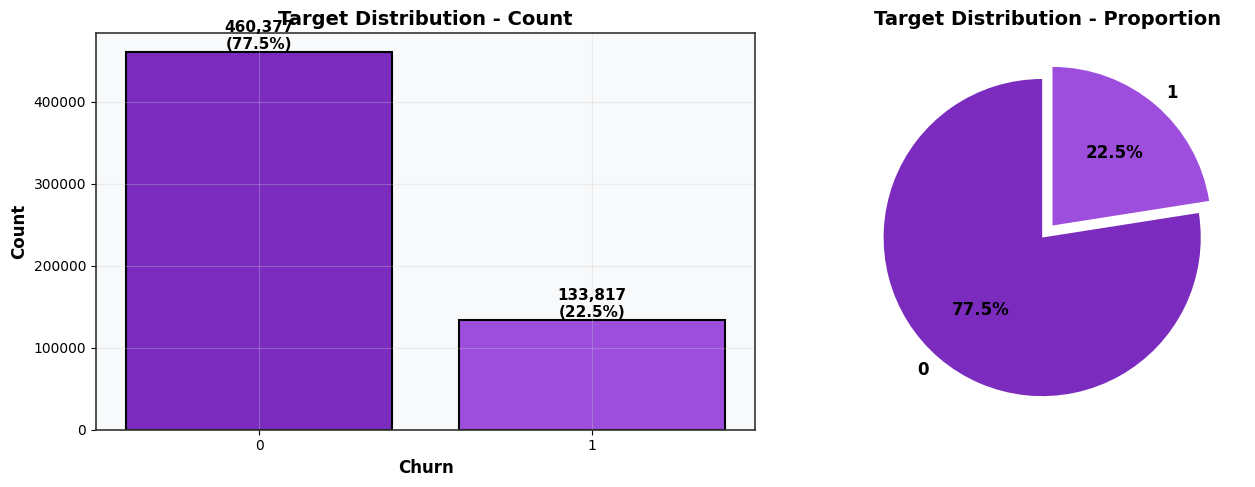


Target Distribution:
Churn
0    460377
1    133817
Name: count, dtype: int64

Class Balance Ratio: 3.44:1


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_counts = train[CONFIG['TARGET']].value_counts()
target_pcts = train[CONFIG['TARGET']].value_counts(normalize=True) * 100

ax = axes[0]
bars = ax.bar(target_counts.index.astype(str), target_counts.values, 
              color=[COLORS[0], COLORS[1]], edgecolor='black', linewidth=1.5)
ax.set_xlabel('Churn', fontweight='bold')
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('Target Distribution - Count', fontweight='bold')

for bar, count, pct in zip(bars, target_counts.values, target_pcts.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax = axes[1]
explode = (0.05, 0.05)
ax.pie(target_counts.values, labels=target_counts.index.astype(str), autopct='%1.1f%%',
       colors=[COLORS[0], COLORS[1]], explode=explode, startangle=90,
       textprops={'fontsize': 12, 'fontweight': 'bold'})
ax.set_title('Target Distribution - Proportion', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTarget Distribution:")
print(target_counts)
print(f"\nClass Balance Ratio: {target_counts.max() / target_counts.min():.2f}:1")

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
TRAIN vs ORIGINAL TARGET COMPARISON<br>
</div>

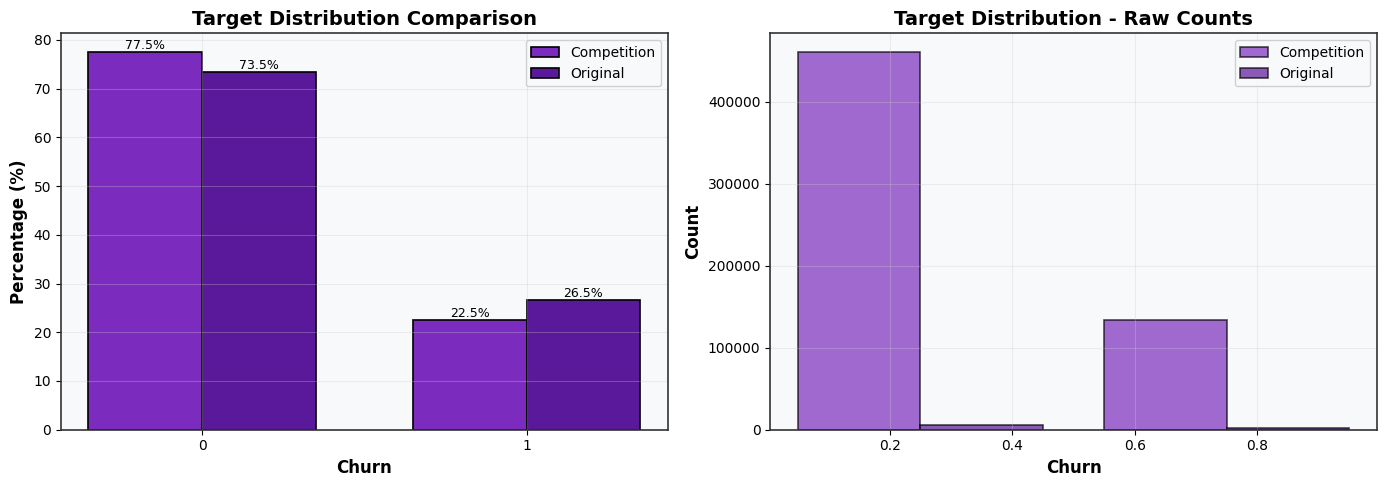

Competition Churn Rate: 22.52%
Original Churn Rate   : 26.54%
  TARGET ANALYSIS COMPLETED ✅


In [9]:
if 'Churn' in original.columns:
    original_target = original['Churn'].map({'No': 0, 'Yes': 1}) if original['Churn'].dtype == 'object' else original['Churn']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax = axes[0]
    train_counts = train[CONFIG['TARGET']].value_counts(normalize=True) * 100
    orig_counts = original_target.value_counts(normalize=True) * 100
    
    x = np.arange(len(train_counts))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, train_counts.sort_index().values, width, 
                   label='Competition', color=COLORS[0], edgecolor='black', linewidth=1.2)
    bars2 = ax.bar(x + width/2, orig_counts.sort_index().values, width,
                   label='Original', color=COLORS[4], edgecolor='black', linewidth=1.2)
    
    ax.set_xlabel('Churn', fontweight='bold')
    ax.set_ylabel('Percentage (%)', fontweight='bold')
    ax.set_title('Target Distribution Comparison', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(train_counts.sort_index().index.astype(str))
    ax.legend()
    
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
    
    ax = axes[1]
    ax.hist([train[CONFIG['TARGET']], original_target], bins=2, label=['Competition', 'Original'],
            color=[COLORS[0], COLORS[4]], edgecolor='black', linewidth=1.2, alpha=0.7)
    ax.set_xlabel('Churn', fontweight='bold')
    ax.set_ylabel('Count', fontweight='bold')
    ax.set_title('Target Distribution - Raw Counts', fontweight='bold')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"Competition Churn Rate: {train[CONFIG['TARGET']].mean()*100:.2f}%")
    print(f"Original Churn Rate   : {original_target.mean()*100:.2f}%")
else:
    print("Original dataset does not contain Churn column.")

print("=" * 70)
print("  TARGET ANALYSIS COMPLETED ✅")
print("=" * 70)

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>5. MISSING VALUES ANALYSIS</b></div>

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
MISSING VALUES HEATMAP<br>
</div>

In [10]:
total_missing = train.isnull().sum().sum()

if total_missing > 0:
    sample_size = min(500, len(train))
    sample_data = train.sample(n=sample_size, random_state=42)
    
    plt.figure(figsize=(14, 6))
    sns.heatmap(sample_data.isnull(), cmap='Purples', cbar=True, yticklabels=False)
    plt.title('Missing Values Heatmap (Sample of 500 Rows)', fontweight='bold')
    plt.xlabel('Features', fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in training data.")

No missing values found in training data.


<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
MISSING VALUES BAR CHART<br>
</div>

In [11]:
train_missing = (train.isnull().sum() / len(train) * 100).sort_values(ascending=False)
test_missing = (test.isnull().sum() / len(test) * 100).sort_values(ascending=False)

train_missing = train_missing[train_missing > 0]
test_missing = test_missing[test_missing > 0]

if len(train_missing) > 0 or len(test_missing) > 0:
    all_missing_cols = sorted(set(train_missing.index.tolist() + test_missing.index.tolist()))
    
    train_missing_aligned = [train_missing.get(col, 0) for col in all_missing_cols]
    test_missing_aligned = [test_missing.get(col, 0) for col in all_missing_cols]
    
    fig, ax = plt.subplots(figsize=(12, max(6, len(all_missing_cols) * 0.4)))
    
    y_pos = np.arange(len(all_missing_cols))
    width = 0.35
    
    ax.barh(y_pos - width/2, train_missing_aligned, width, label='Train', 
            color=COLORS[0], edgecolor='black', linewidth=1)
    ax.barh(y_pos + width/2, test_missing_aligned, width, label='Test',
            color=COLORS[2], edgecolor='black', linewidth=1)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(all_missing_cols)
    ax.set_xlabel('Missing Percentage (%)', fontweight='bold')
    ax.set_title('Missing Values Comparison: Train vs Test', fontweight='bold')
    ax.legend()
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected in train or test sets.")

print("=" * 70)
print("  MISSING VALUES ANALYSIS COMPLETED ✅")
print("=" * 70)

No missing values detected in train or test sets.
  MISSING VALUES ANALYSIS COMPLETED ✅


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>6. NUMERICAL FEATURES ANALYSIS</b></div>

In [12]:
numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['id', CONFIG['TARGET']]]

print(f"Found {len(numerical_cols)} numerical features: {numerical_cols}")

Found 4 numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
DISTRIBUTION PLOTS<br>
</div>

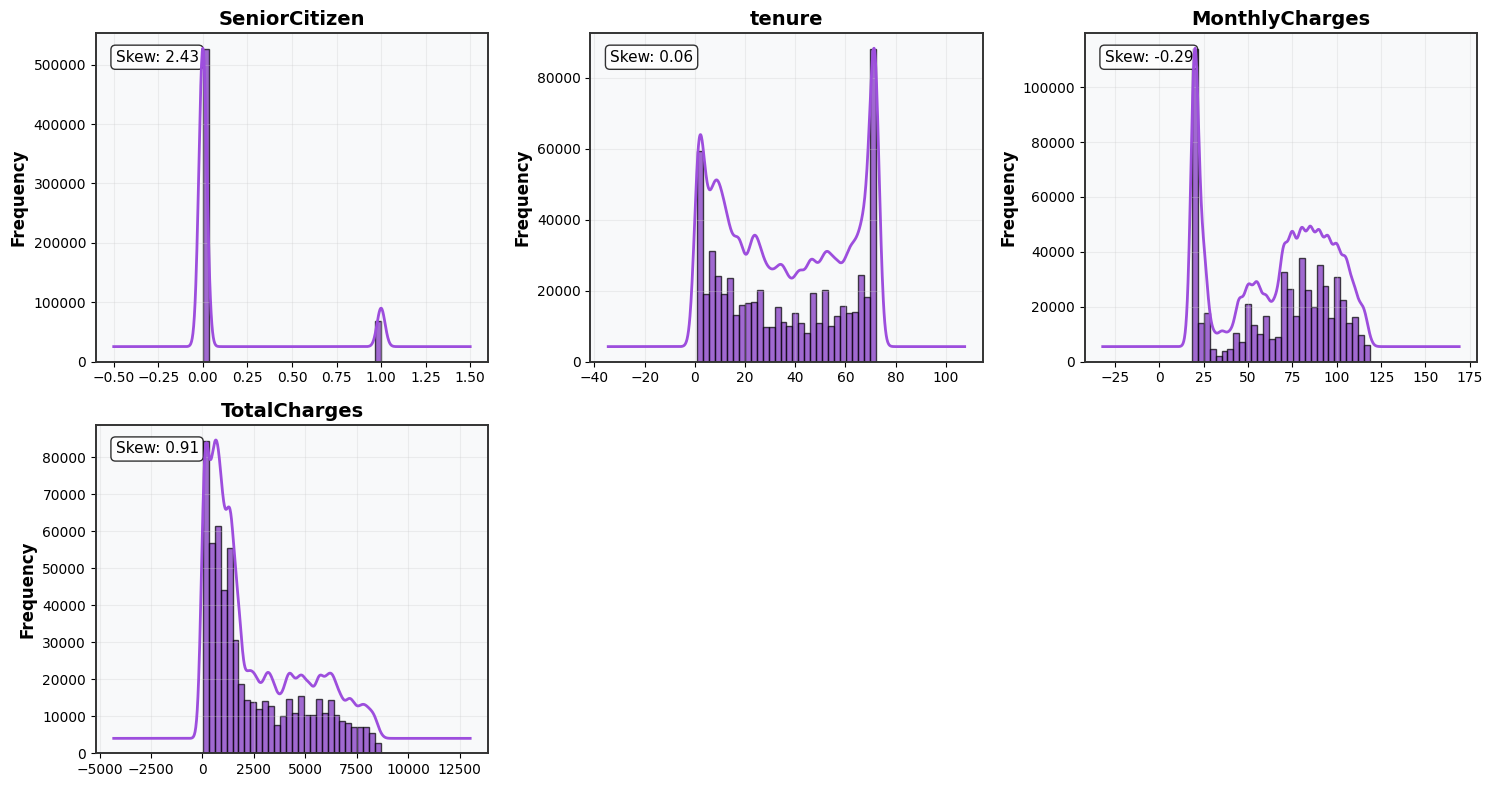

In [13]:
if len(numerical_cols) > 0:
    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes
    
    for idx, col in enumerate(numerical_cols):
        ax = axes[idx]
        data = train[col].dropna()
        
        ax.hist(data, bins=30, color=COLORS[0], alpha=0.7, edgecolor='black', linewidth=1)
        ax2 = ax.twinx()
        data.plot(kind='kde', ax=ax2, color=COLORS[1], linewidth=2)
        ax2.set_ylabel('')
        ax2.set_yticks([])
        
        skewness = skew(data)
        ax.text(0.05, 0.95, f'Skew: {skewness:.2f}', transform=ax.transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.set_title(col, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Frequency', fontweight='bold')
    
    for idx in range(len(numerical_cols), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
BOX PLOTS<br>
</div>

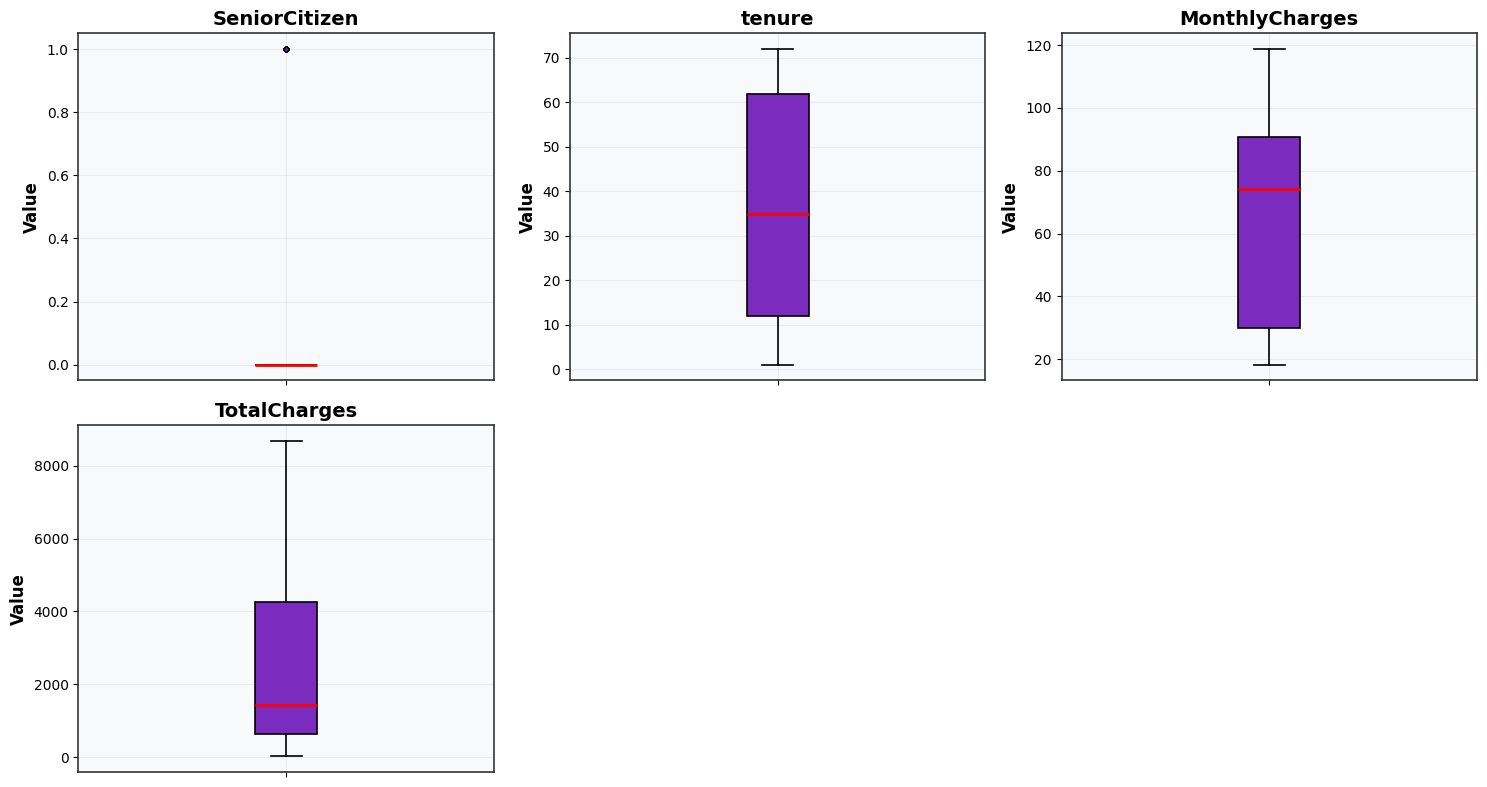

In [14]:
if len(numerical_cols) > 0:
    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes
    
    for idx, col in enumerate(numerical_cols):
        ax = axes[idx]
        bp = ax.boxplot(train[col].dropna(), vert=True, patch_artist=True,
                        boxprops=dict(facecolor=COLORS[0], edgecolor='black', linewidth=1.2),
                        whiskerprops=dict(color='black', linewidth=1.2),
                        capprops=dict(color='black', linewidth=1.2),
                        medianprops=dict(color='red', linewidth=2),
                        flierprops=dict(marker='o', markerfacecolor=COLORS[0], markersize=3, alpha=0.5))
        ax.set_title(col, fontweight='bold')
        ax.set_ylabel('Value', fontweight='bold')
        ax.set_xticklabels([''])
    
    for idx in range(len(numerical_cols), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
SKEWNESS & KURTOSIS SUMMARY<br>
</div>

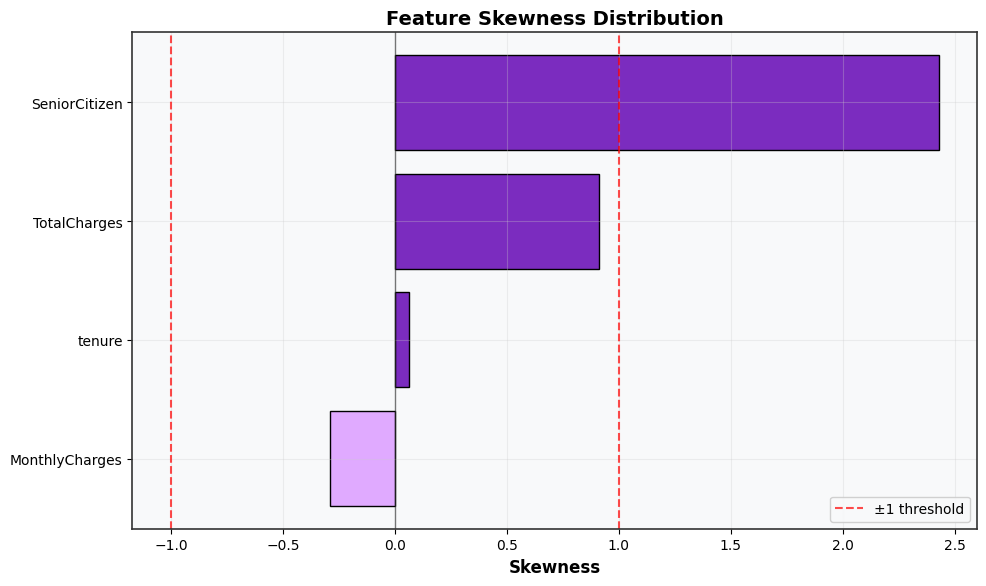

  NUMERICAL FEATURES ANALYSIS COMPLETED ✅


In [15]:
if len(numerical_cols) > 0:
    skewness_vals = {col: skew(train[col].dropna()) for col in numerical_cols}
    skewness_df = pd.DataFrame(list(skewness_vals.items()), columns=['Feature', 'Skewness'])
    skewness_df = skewness_df.sort_values('Skewness', ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, max(6, len(numerical_cols) * 0.4)))
    
    colors = [COLORS[0] if x > 0 else COLORS[3] for x in skewness_df['Skewness']]
    bars = ax.barh(skewness_df['Feature'], skewness_df['Skewness'], color=colors, edgecolor='black', linewidth=1)
    
    ax.axvline(x=1, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='±1 threshold')
    ax.axvline(x=-1, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    ax.set_xlabel('Skewness', fontweight='bold')
    ax.set_title('Feature Skewness Distribution', fontweight='bold')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

print("=" * 70)
print("  NUMERICAL FEATURES ANALYSIS COMPLETED ✅")
print("=" * 70)

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>7. CATEGORICAL FEATURES ANALYSIS</b></div>

In [16]:
categorical_cols = train.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['id', CONFIG['TARGET']]]

print(f"Found {len(categorical_cols)} categorical features: {categorical_cols}")

Found 15 categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
VALUE COUNT DISTRIBUTIONS<br>
</div>

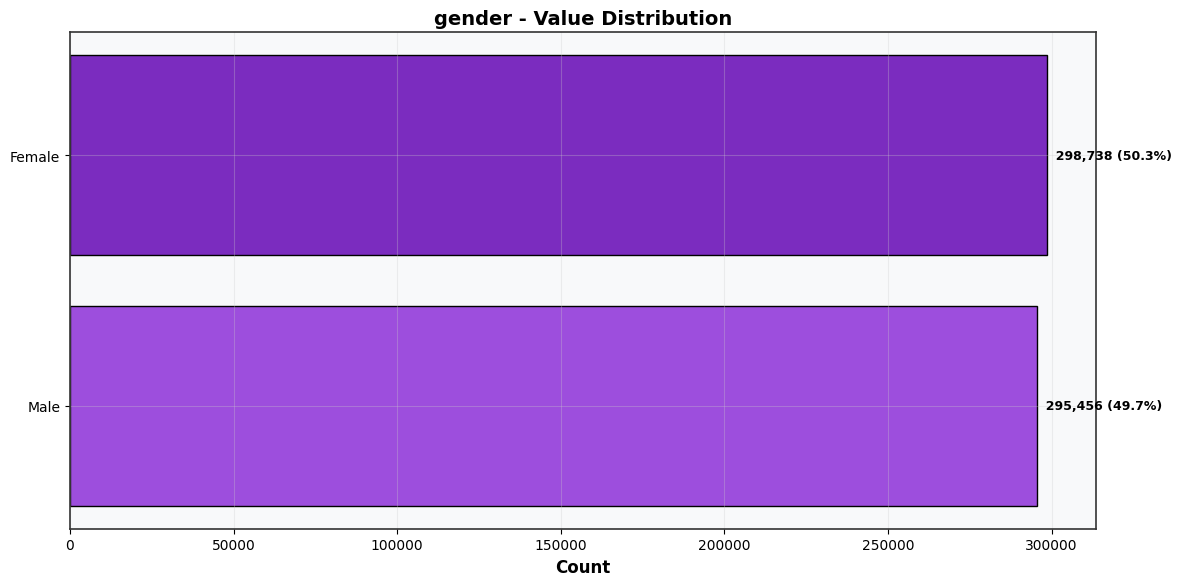

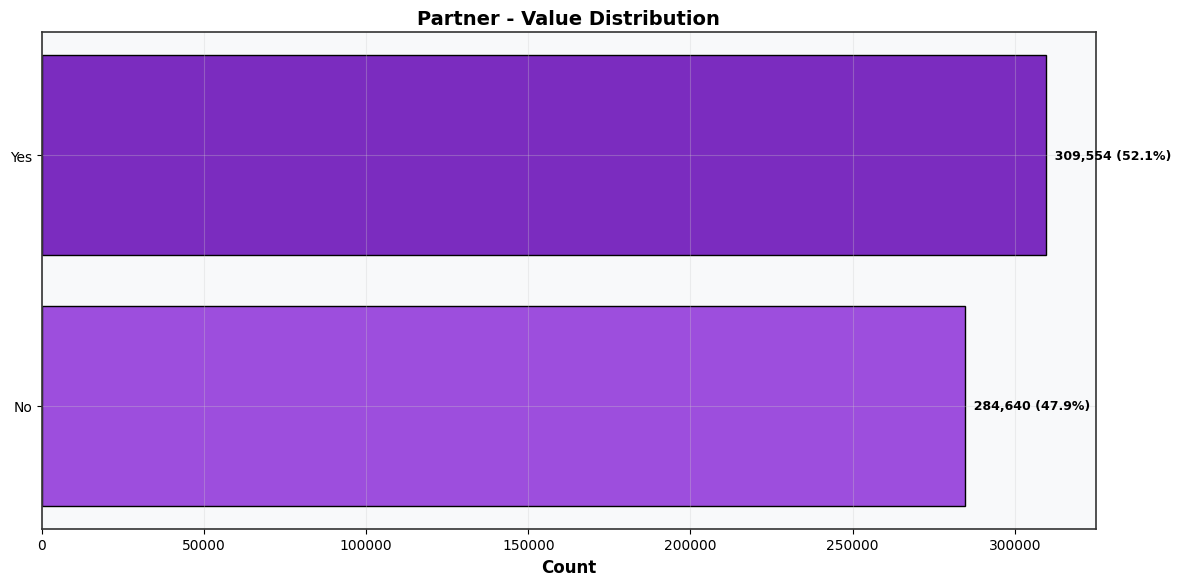

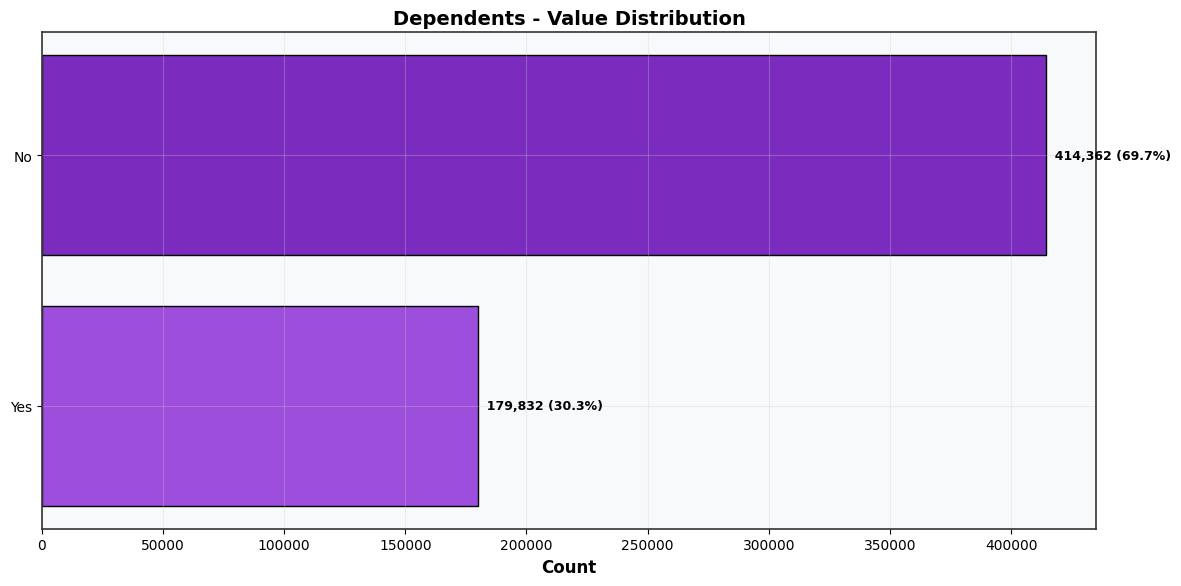

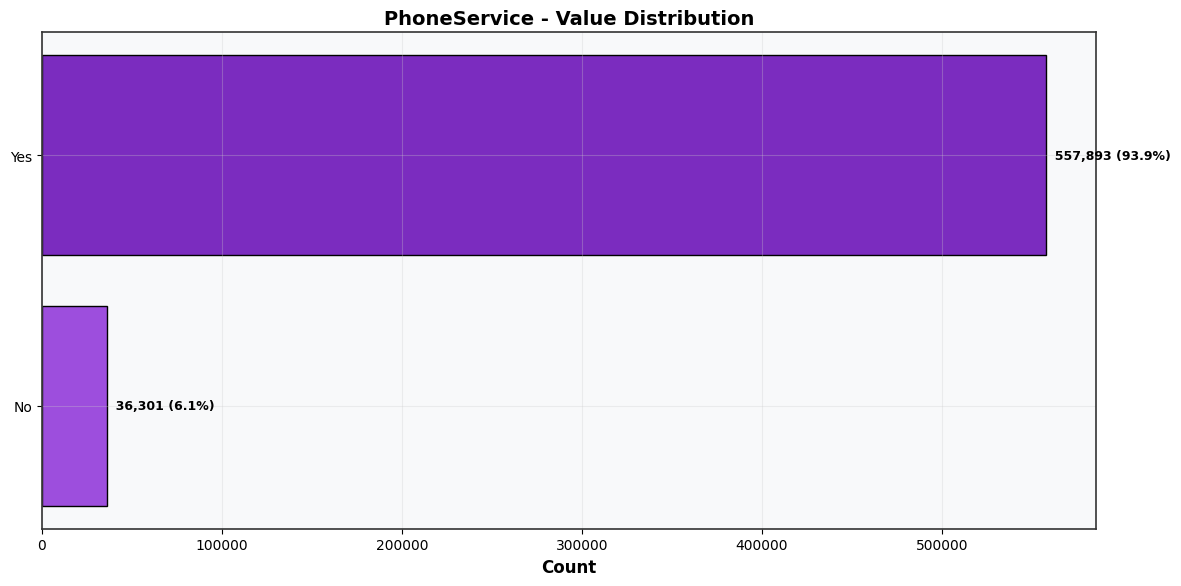

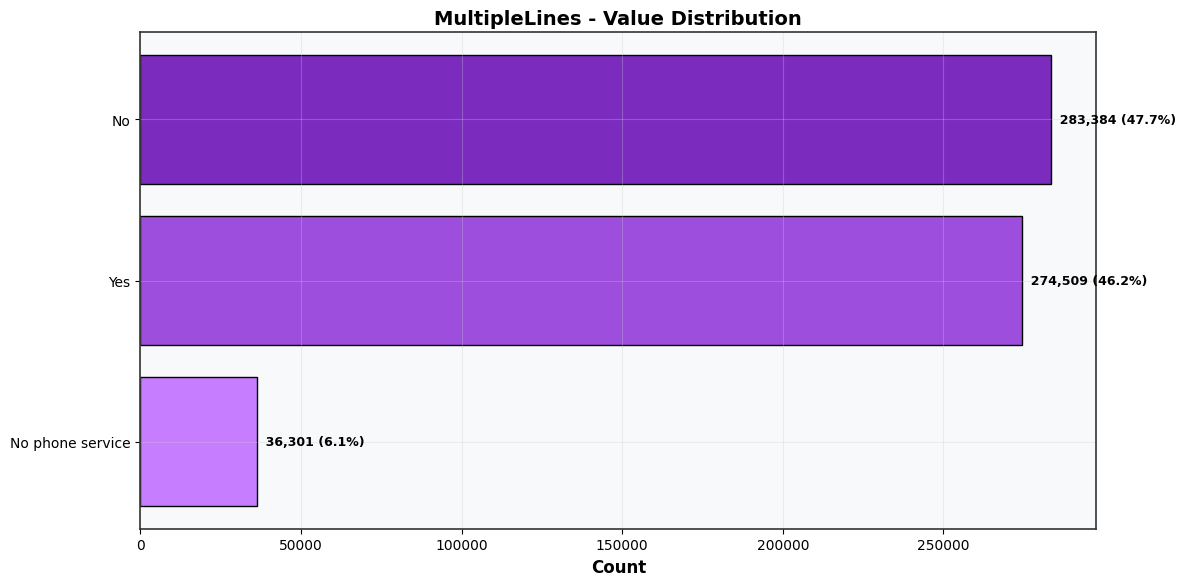

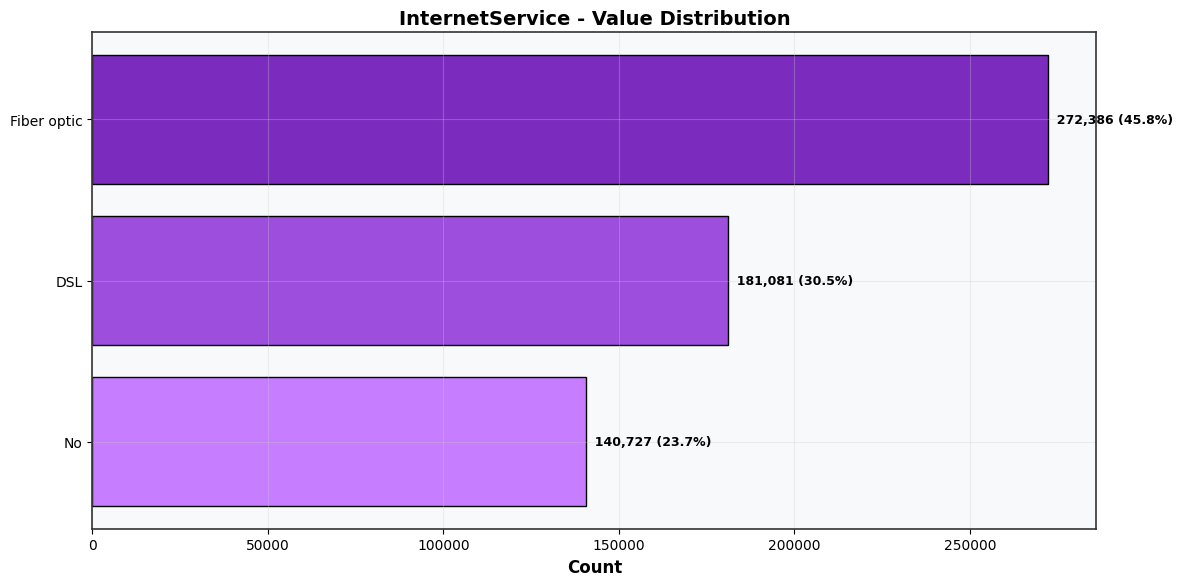

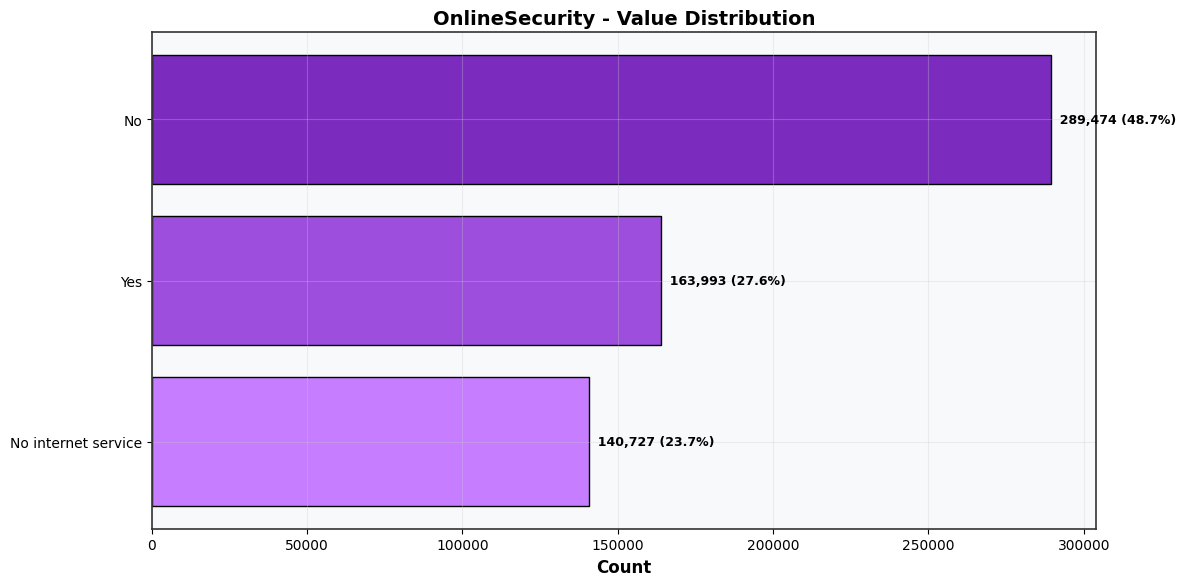

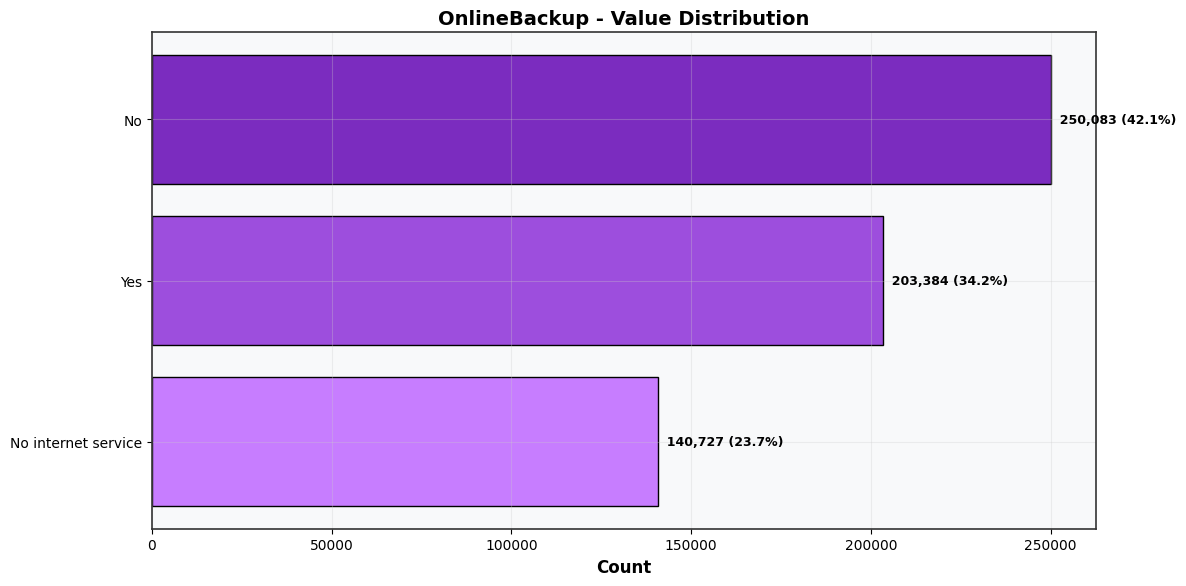

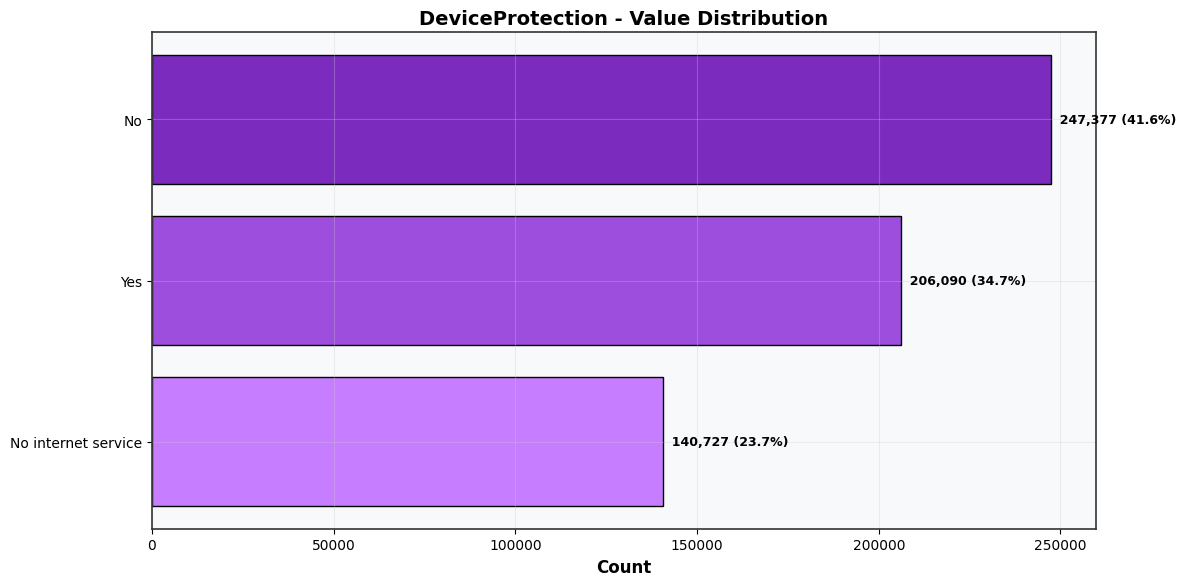

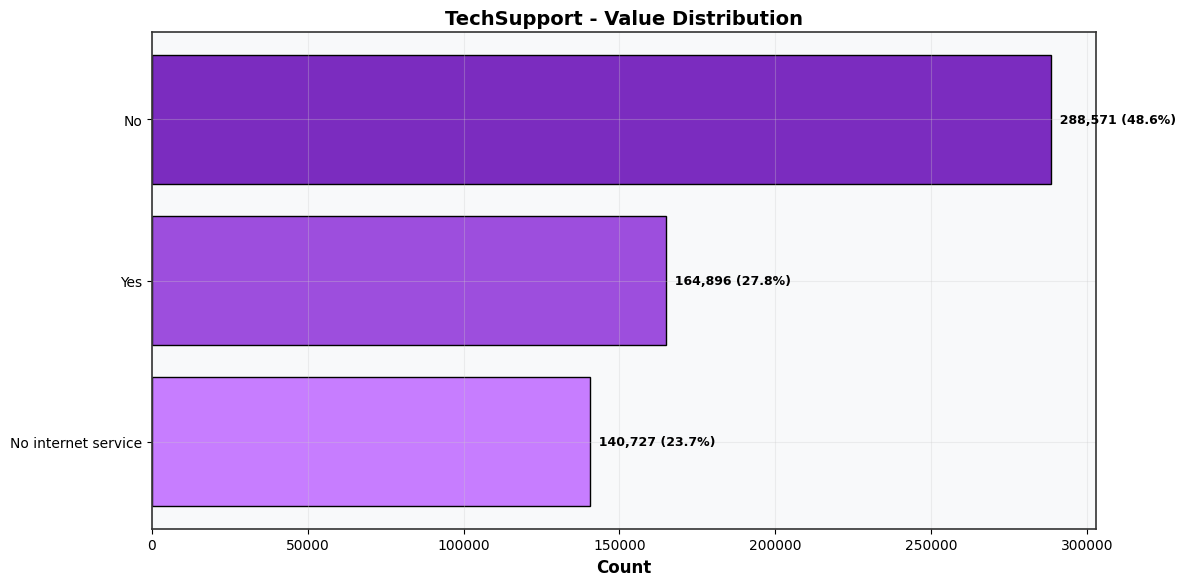

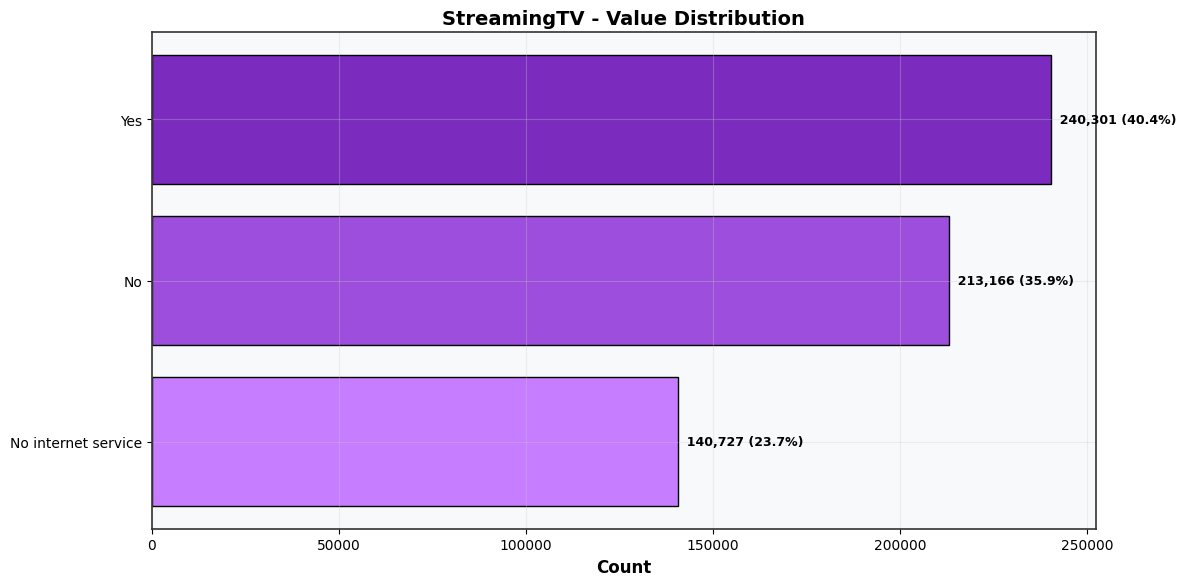

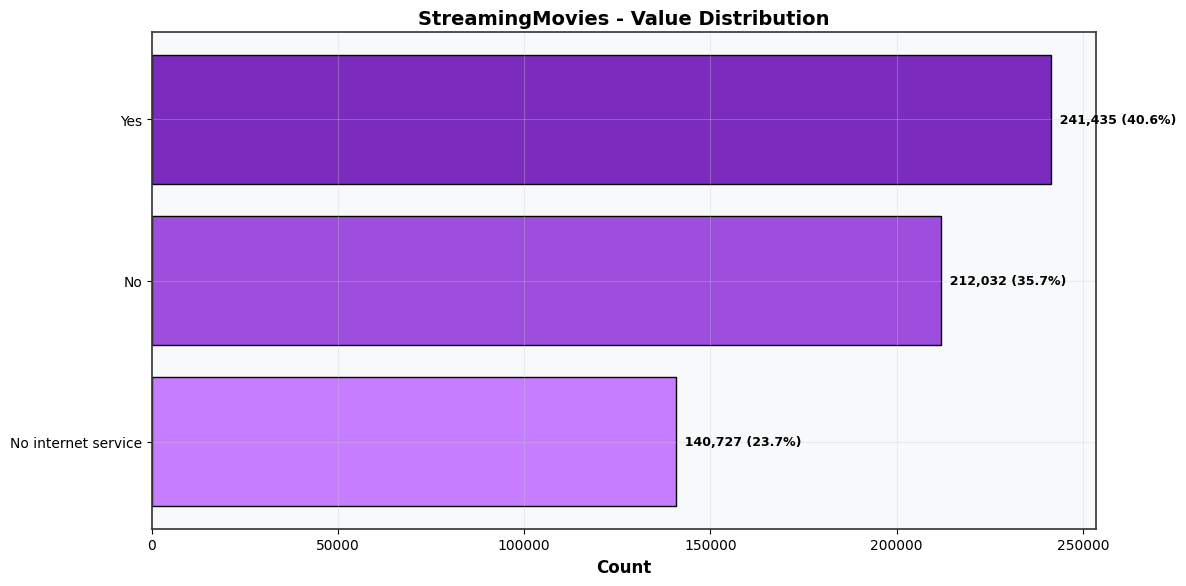

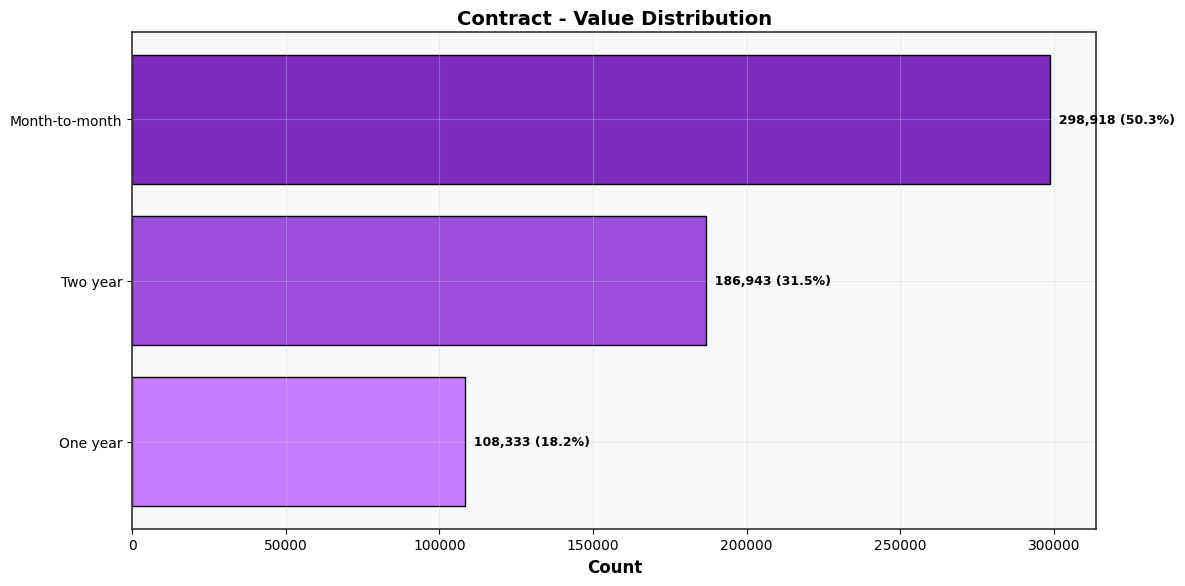

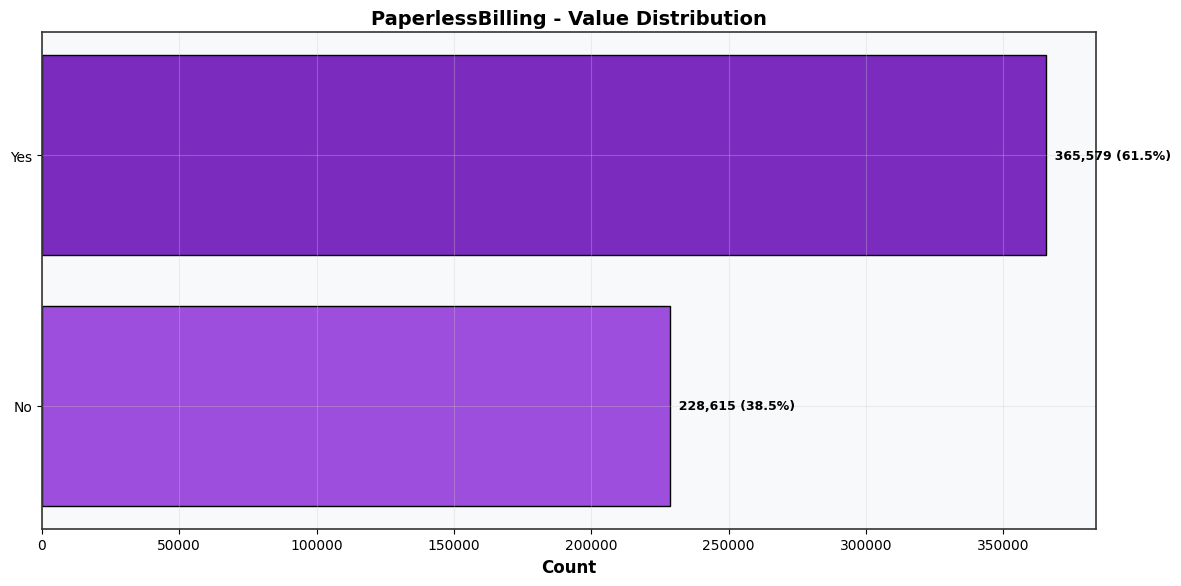

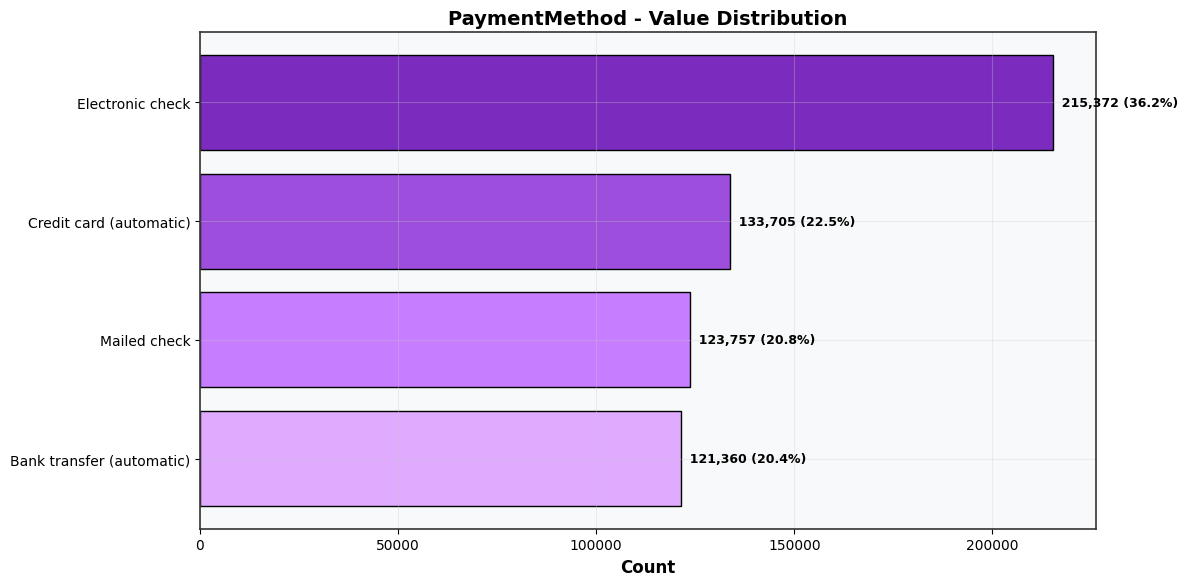

In [17]:
if len(categorical_cols) > 0:
    for col in categorical_cols:
        value_counts = train[col].value_counts().head(15)
        percentages = (value_counts / len(train) * 100)
        
        fig, ax = plt.subplots(figsize=(12, max(6, len(value_counts) * 0.4)))
        
        bars = ax.barh(range(len(value_counts)), value_counts.values,
                       color=COLORS[:len(value_counts)], edgecolor='black', linewidth=1)
        ax.set_yticks(range(len(value_counts)))
        ax.set_yticklabels(value_counts.index)
        ax.set_xlabel('Count', fontweight='bold')
        ax.set_title(f'{col} - Value Distribution', fontweight='bold')
        ax.invert_yaxis()
        
        for i, (bar, count, pct) in enumerate(zip(bars, value_counts.values, percentages.values)):
            width = bar.get_width()
            ax.text(width, bar.get_y() + bar.get_height()/2,
                   f'  {count:,} ({pct:.1f}%)',
                   ha='left', va='center', fontweight='bold', fontsize=9)
        
        plt.tight_layout()
        plt.show()

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
CARDINALITY OVERVIEW<br>
</div>

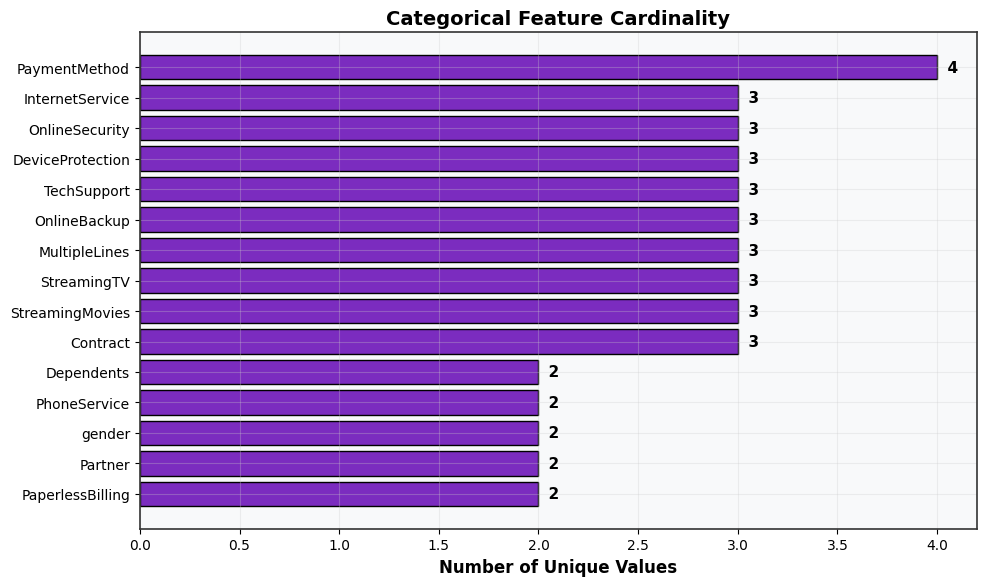

  CATEGORICAL FEATURES ANALYSIS COMPLETED ✅


In [18]:
if len(categorical_cols) > 0:
    cardinality = {col: train[col].nunique() for col in categorical_cols}
    cardinality_df = pd.DataFrame(list(cardinality.items()), columns=['Feature', 'Unique_Values'])
    cardinality_df = cardinality_df.sort_values('Unique_Values', ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, max(6, len(categorical_cols) * 0.4)))
    
    bars = ax.barh(cardinality_df['Feature'], cardinality_df['Unique_Values'],
                   color=COLORS[0], edgecolor='black', linewidth=1)
    ax.set_xlabel('Number of Unique Values', fontweight='bold')
    ax.set_title('Categorical Feature Cardinality', fontweight='bold')
    ax.invert_yaxis()
    
    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2,
               f'  {int(width)}', ha='left', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

print("=" * 70)
print("  CATEGORICAL FEATURES ANALYSIS COMPLETED ✅")
print("=" * 70)

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>8. FEATURE vs TARGET ANALYSIS</b></div>

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
NUMERICAL FEATURES vs TARGET<br>
</div>

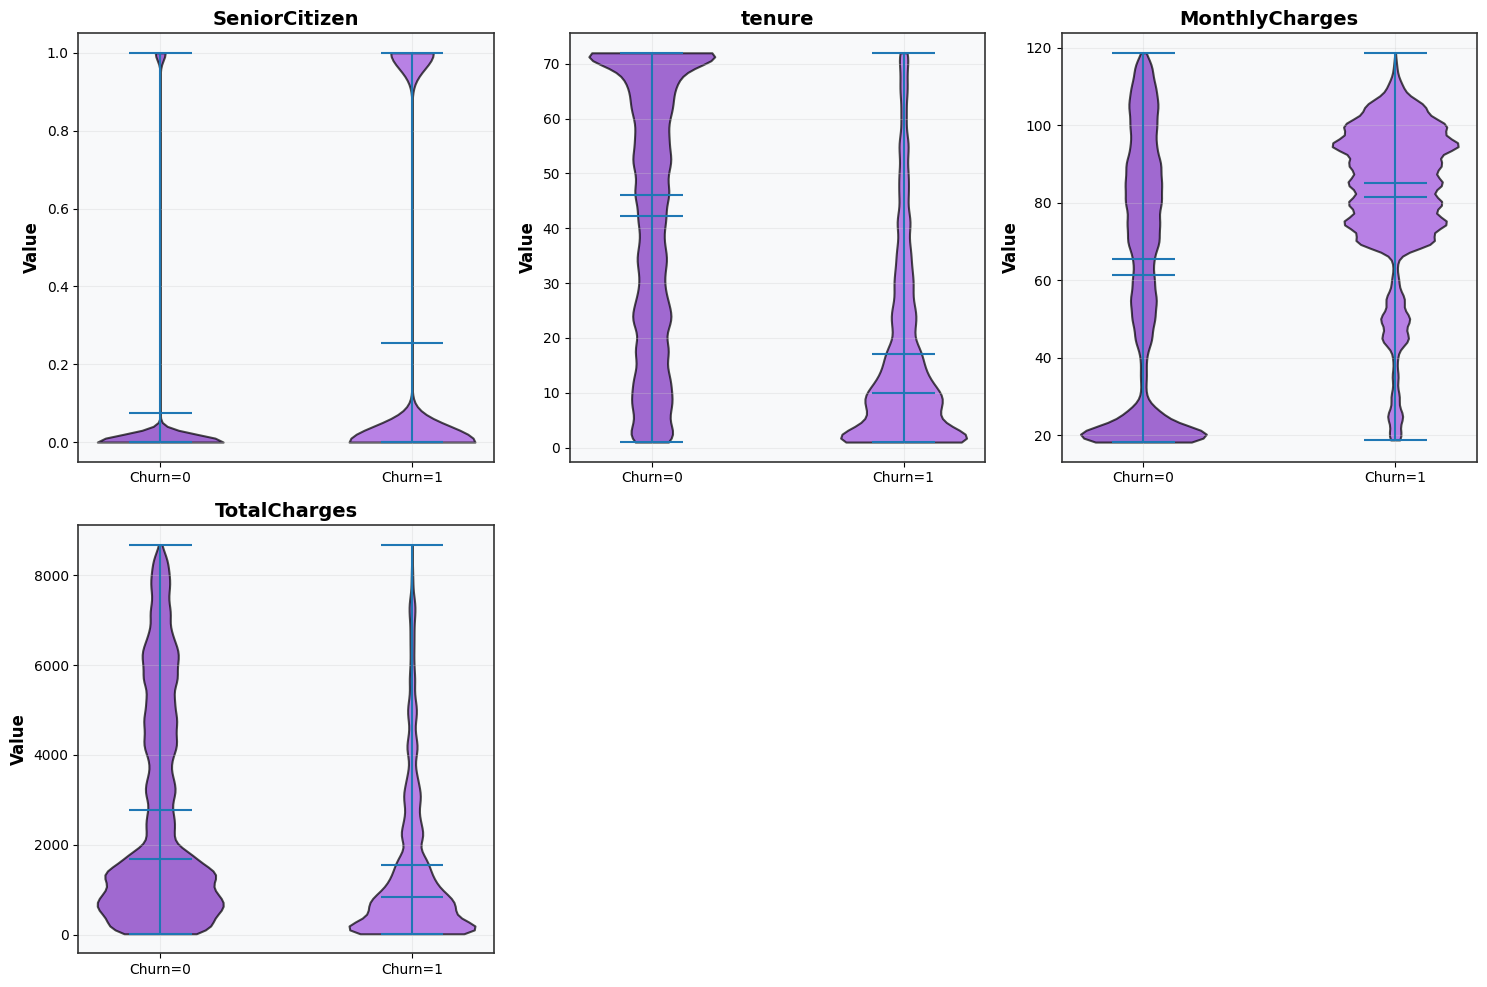

In [19]:
if len(numerical_cols) > 0:
    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes
    
    for idx, col in enumerate(numerical_cols):
        ax = axes[idx]
        data_to_plot = [train[train[CONFIG['TARGET']] == val][col].dropna() for val in sorted(train[CONFIG['TARGET']].unique())]
        
        parts = ax.violinplot(data_to_plot, positions=range(len(data_to_plot)),
                              showmeans=True, showmedians=True)
        
        for i, pc in enumerate(parts['bodies']):
            pc.set_facecolor(COLORS[i % 2])
            pc.set_alpha(0.7)
            pc.set_edgecolor('black')
            pc.set_linewidth(1.5)
        
        ax.set_xticks(range(len(data_to_plot)))
        ax.set_xticklabels([f'Churn={val}' for val in sorted(train[CONFIG['TARGET']].unique())])
        ax.set_title(col, fontweight='bold')
        ax.set_ylabel('Value', fontweight='bold')
    
    for idx in range(len(numerical_cols), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
CATEGORICAL FEATURES vs TARGET<br>
</div>

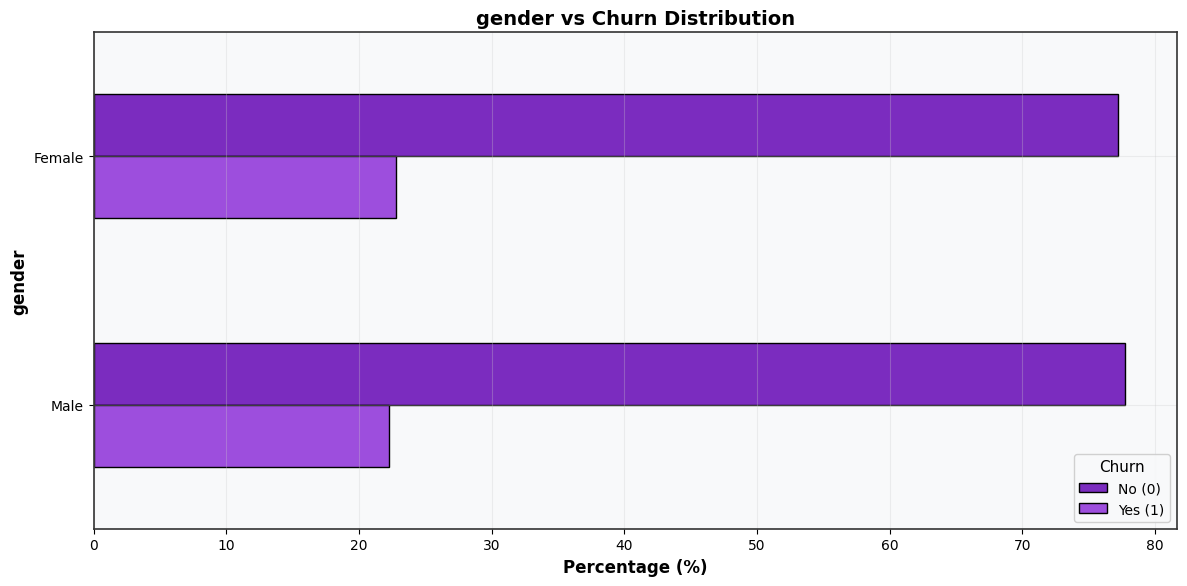

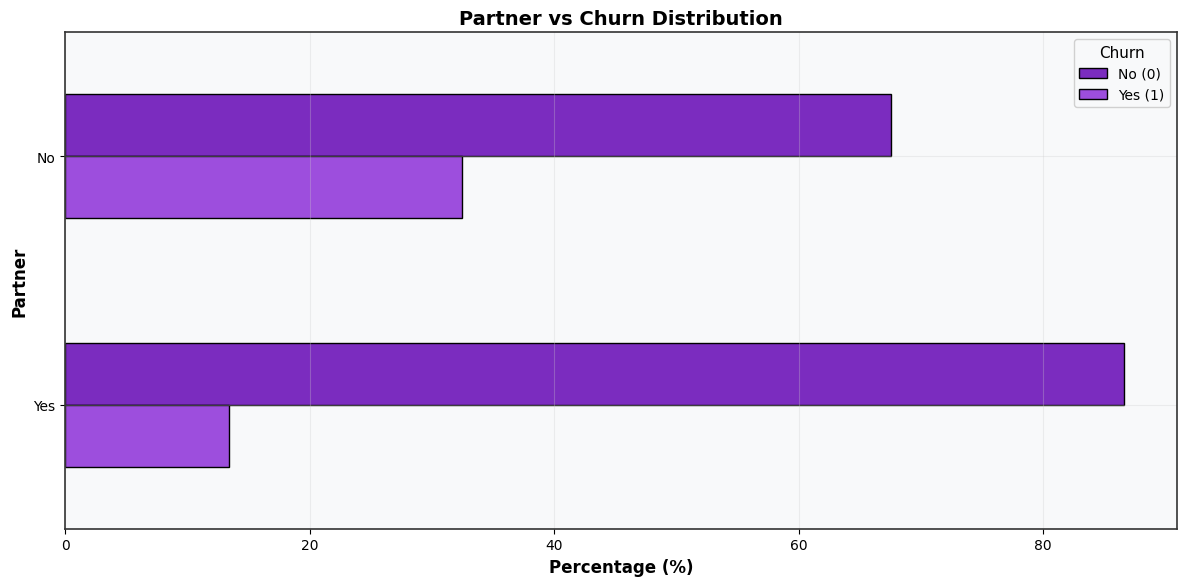

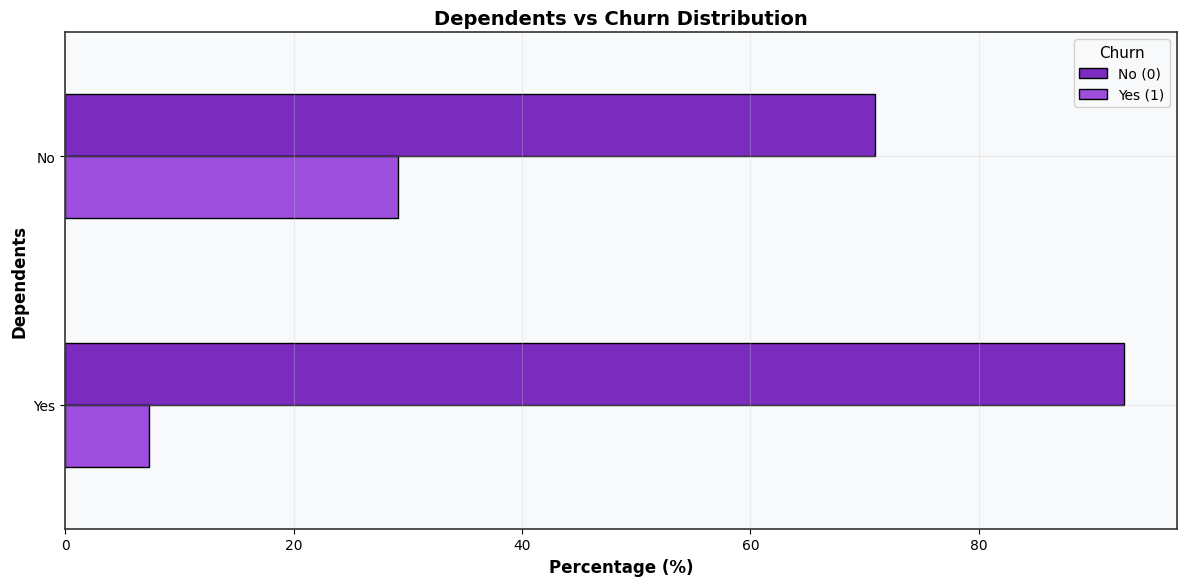

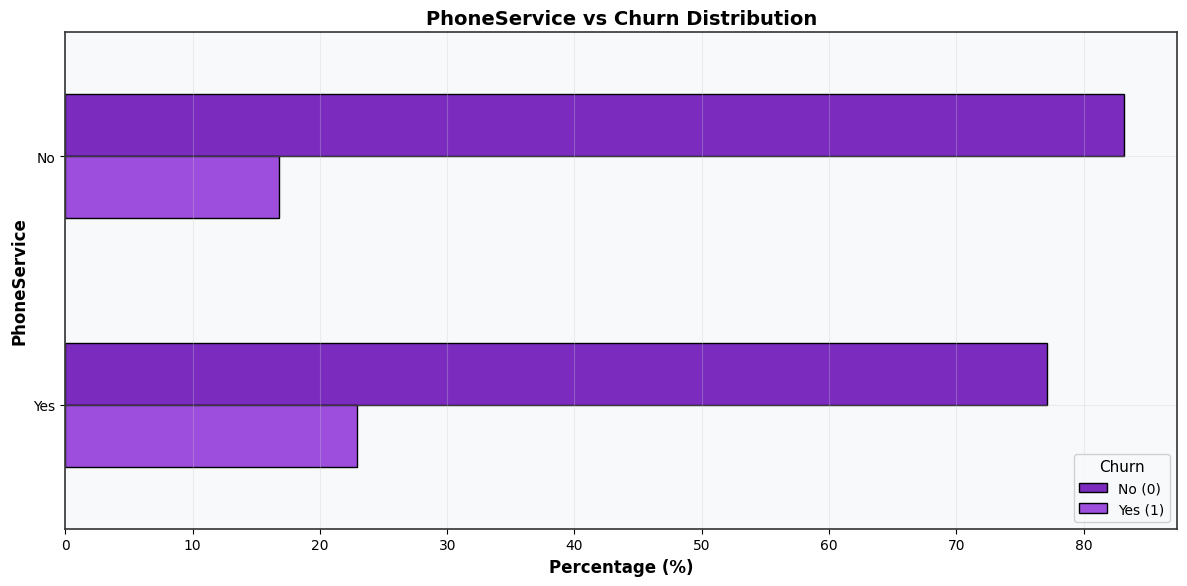

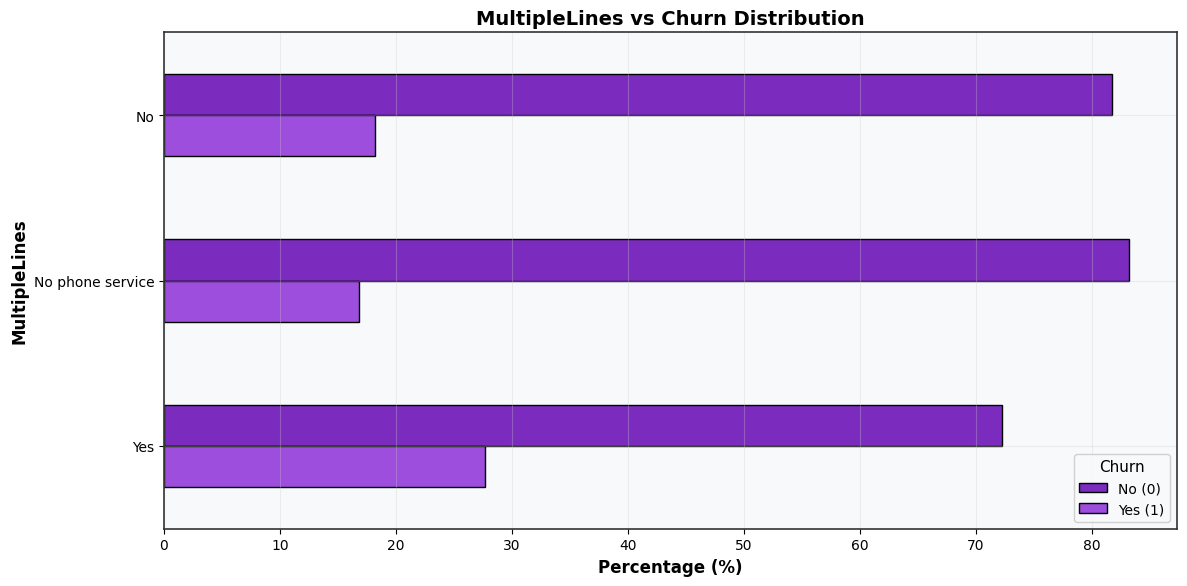

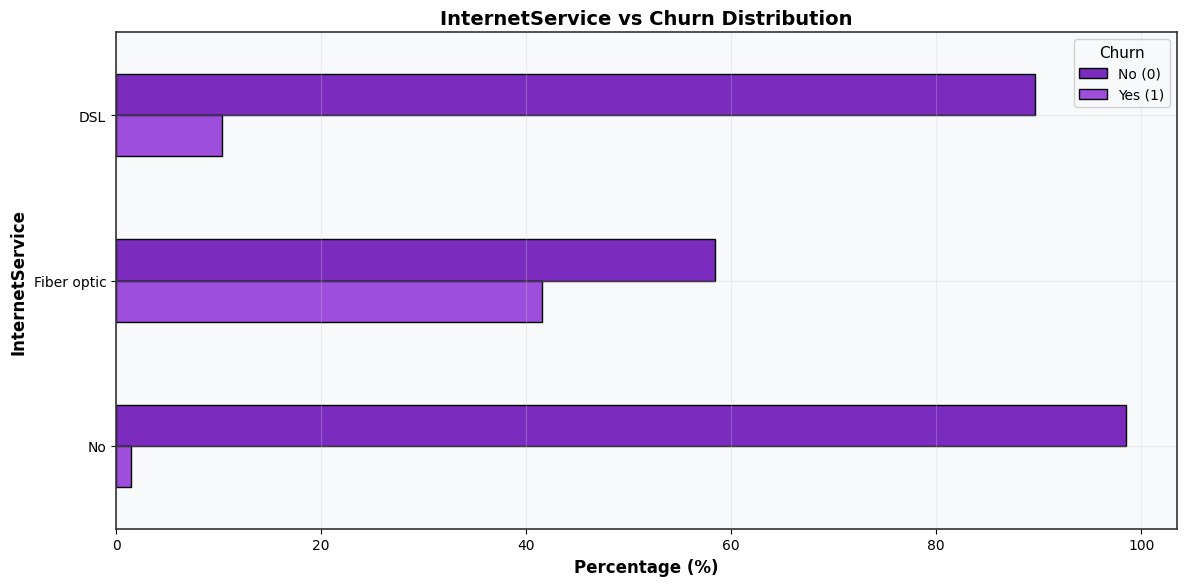

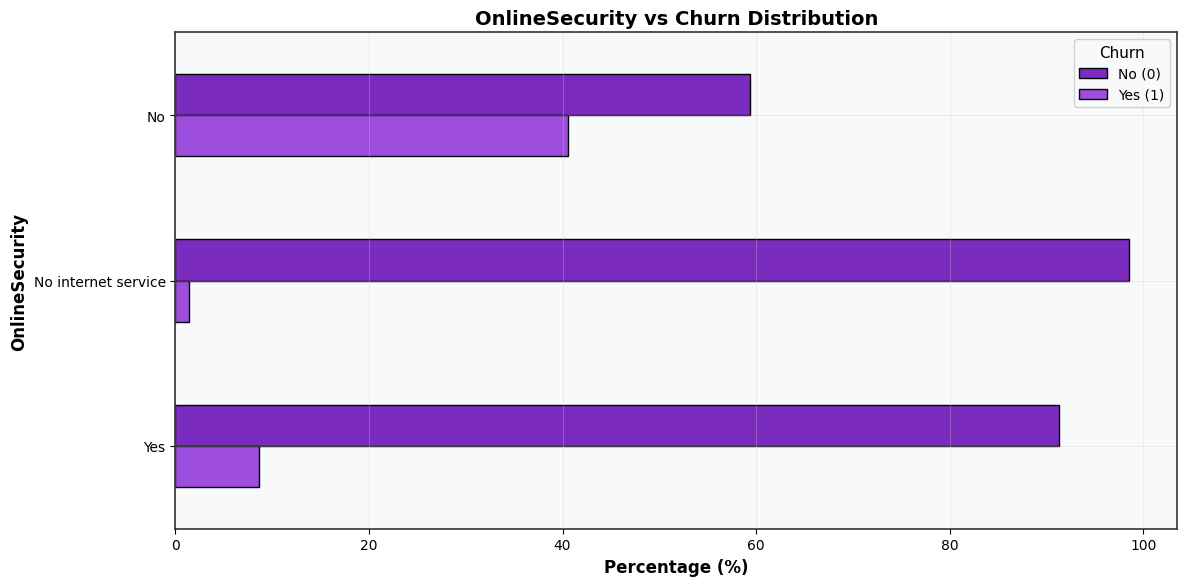

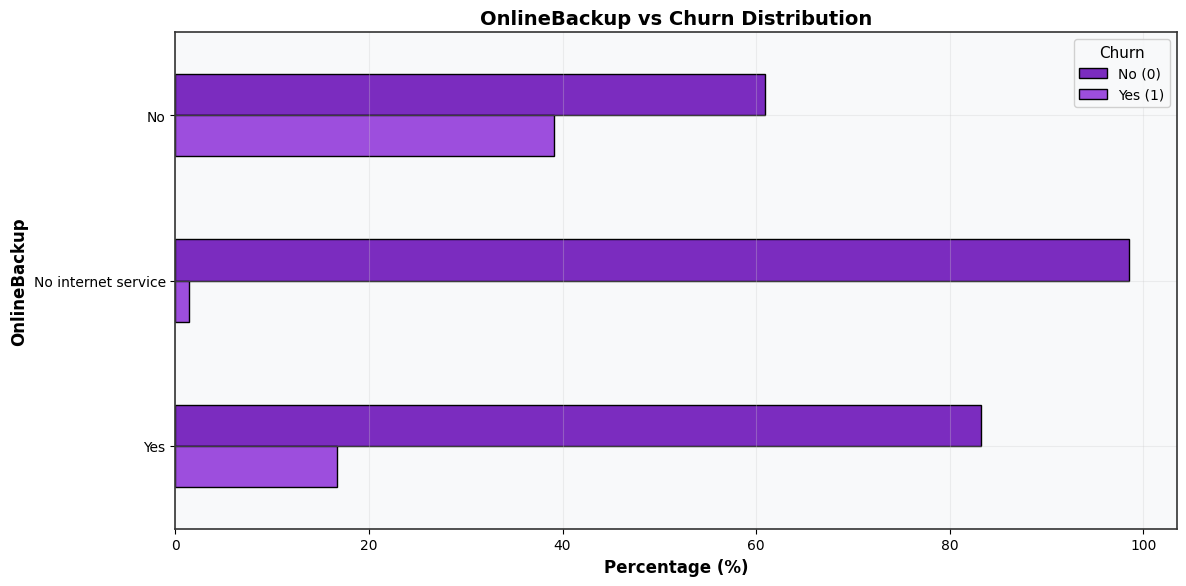

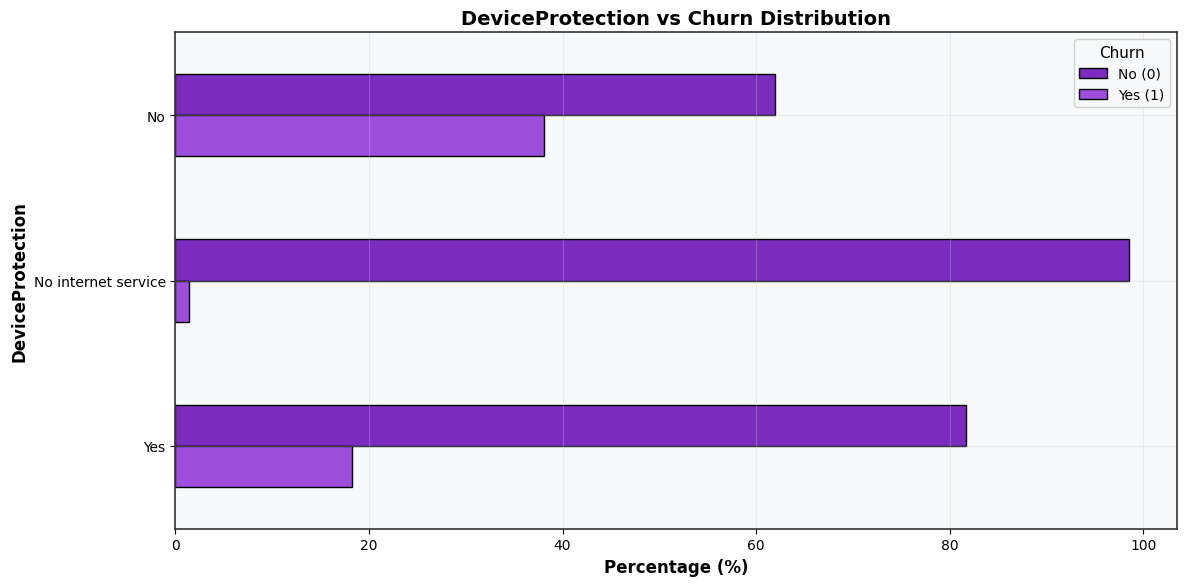

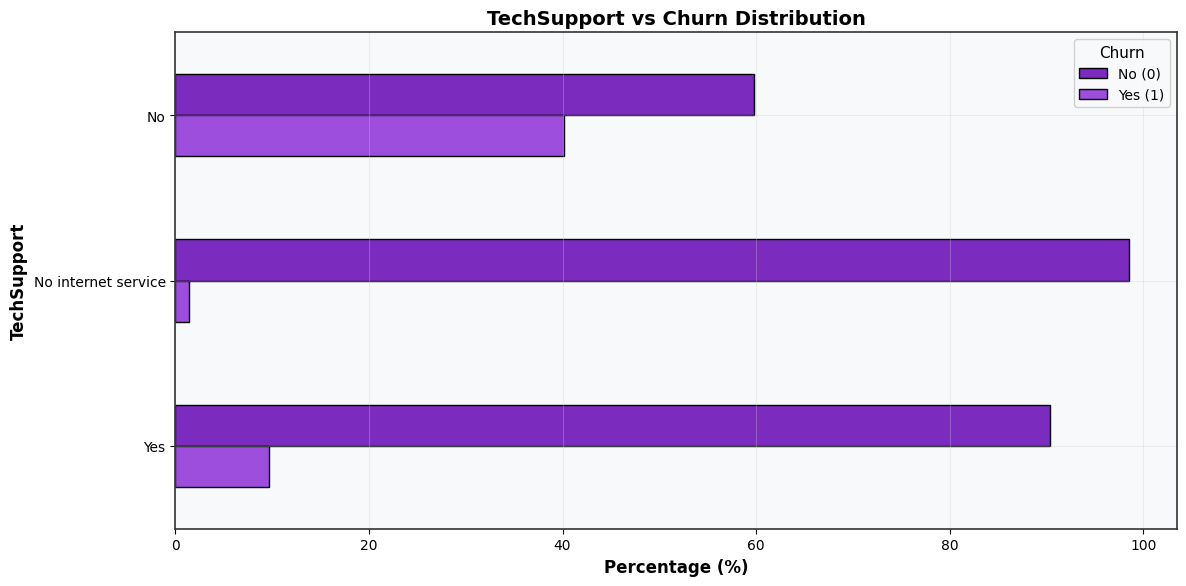

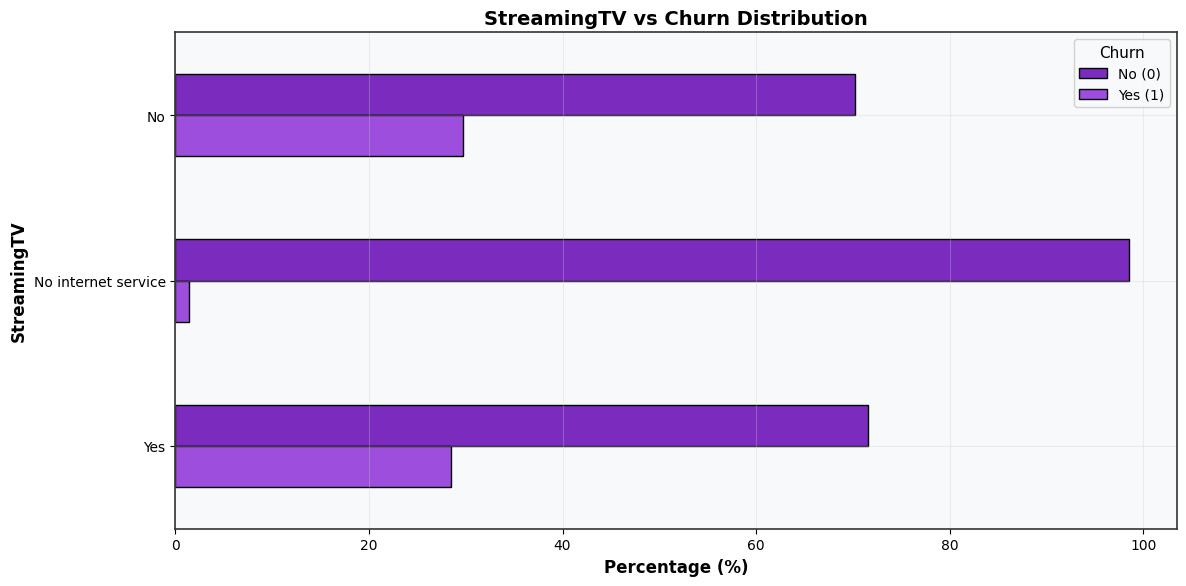

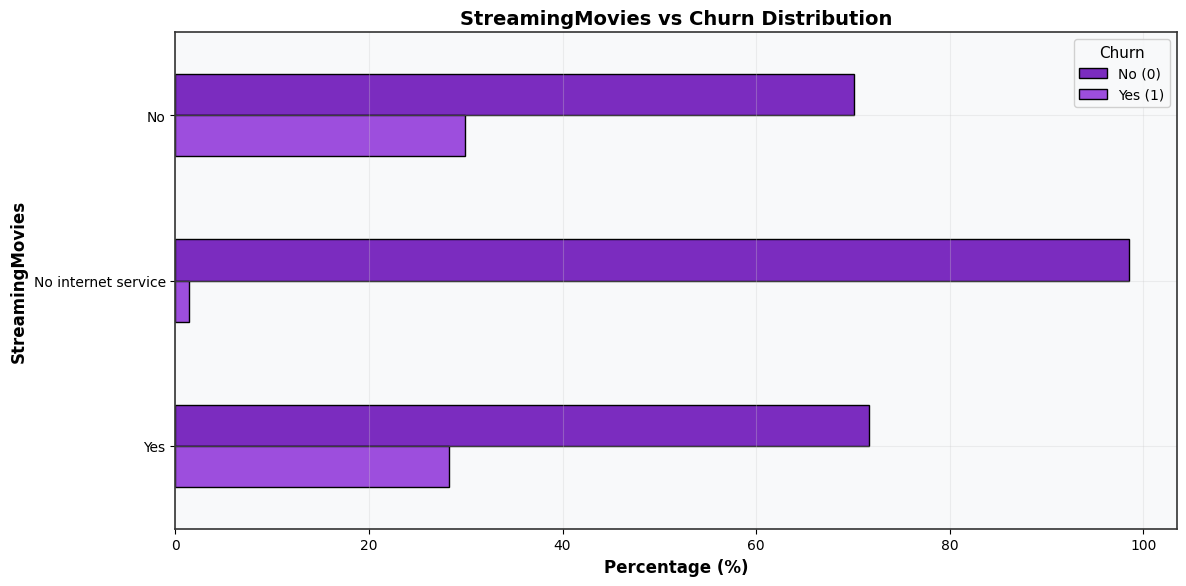

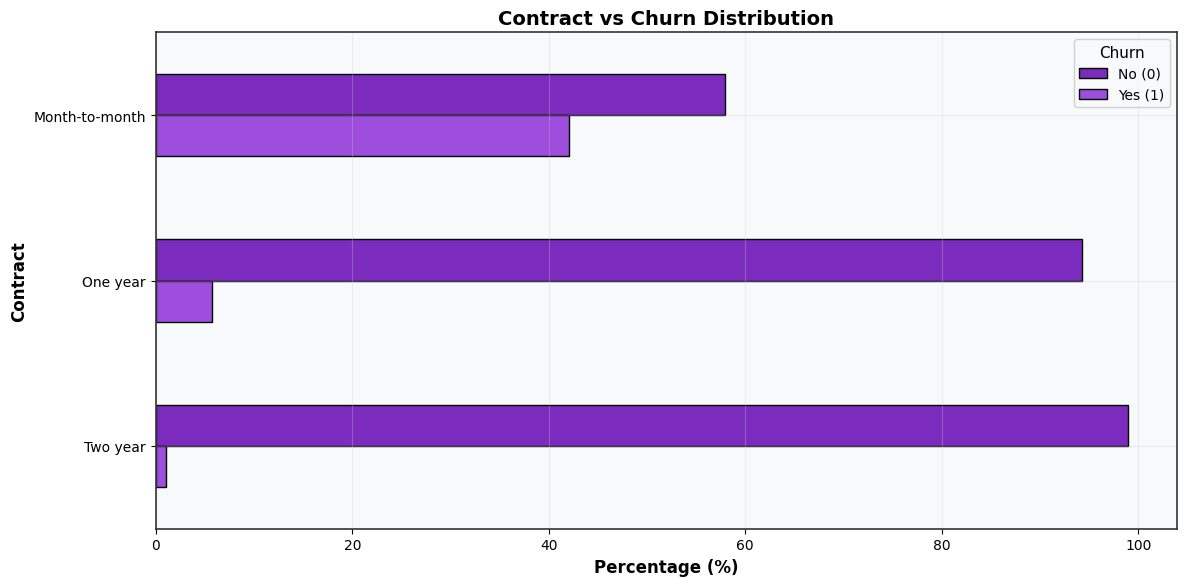

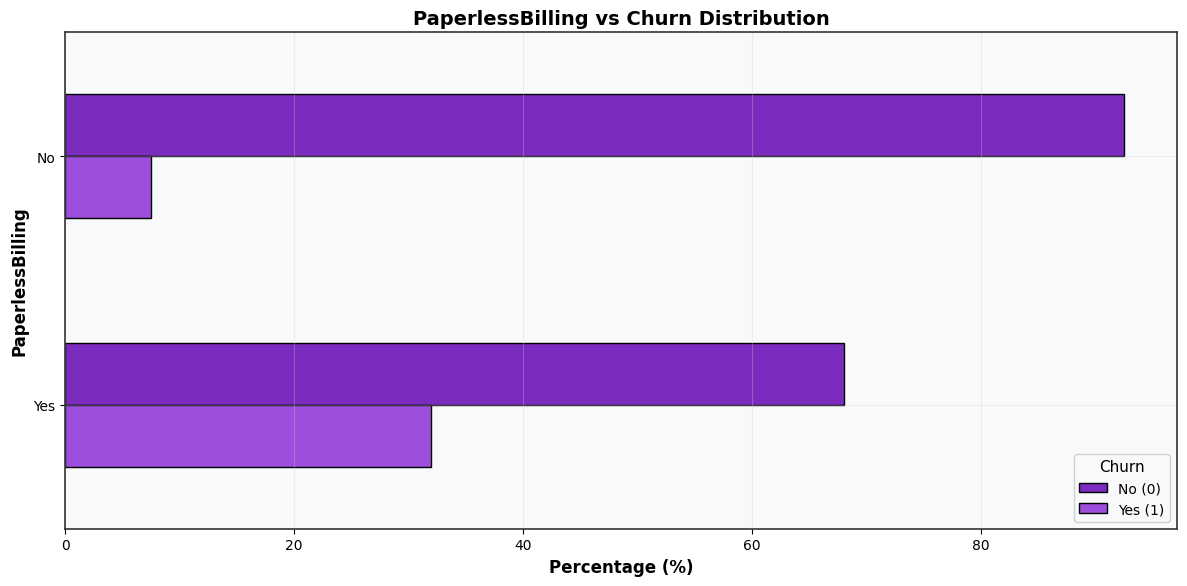

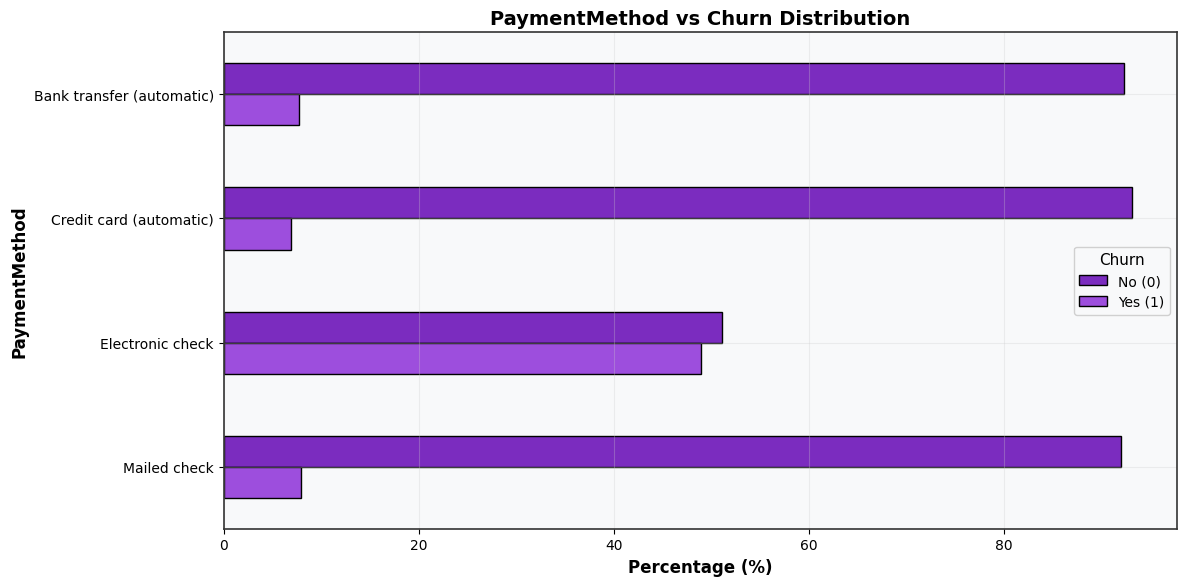

In [20]:
if len(categorical_cols) > 0:
    for col in categorical_cols:
        ct = pd.crosstab(train[col], train[CONFIG['TARGET']], normalize='index') * 100
        
        fig, ax = plt.subplots(figsize=(12, max(6, len(ct) * 0.4)))
        
        ct.plot(kind='barh', stacked=False, ax=ax, color=[COLORS[0], COLORS[1]],
                edgecolor='black', linewidth=1)
        ax.set_xlabel('Percentage (%)', fontweight='bold')
        ax.set_ylabel(col, fontweight='bold')
        ax.set_title(f'{col} vs Churn Distribution', fontweight='bold')
        ax.legend(title='Churn', labels=['No (0)', 'Yes (1)'])
        ax.invert_yaxis()
        
        plt.tight_layout()
        plt.show()

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
MEAN TARGET RATE PER CATEGORY<br>
</div>

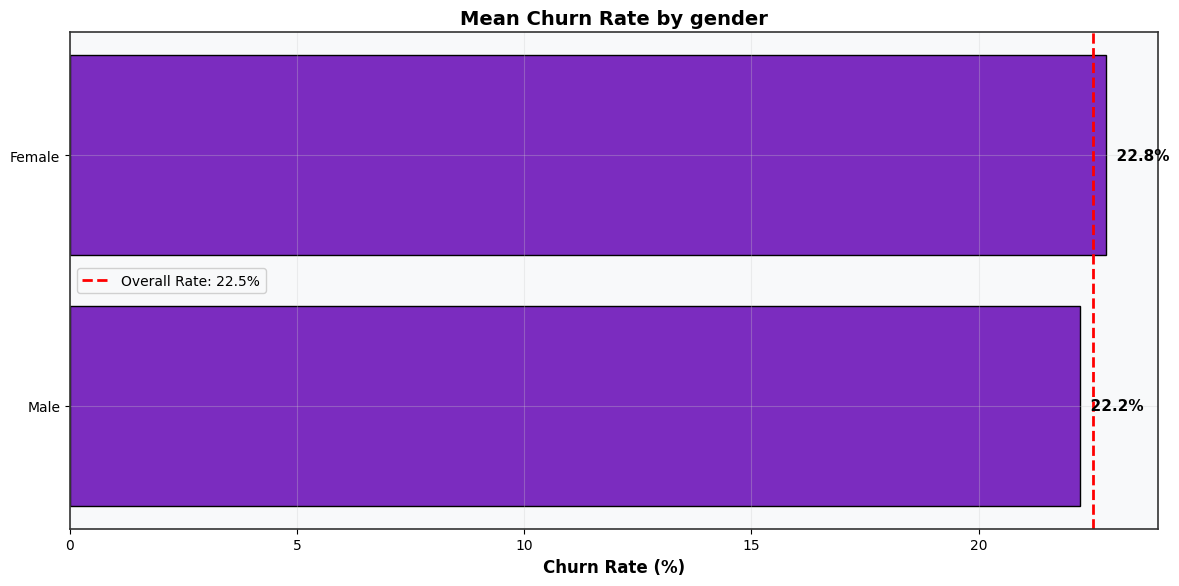

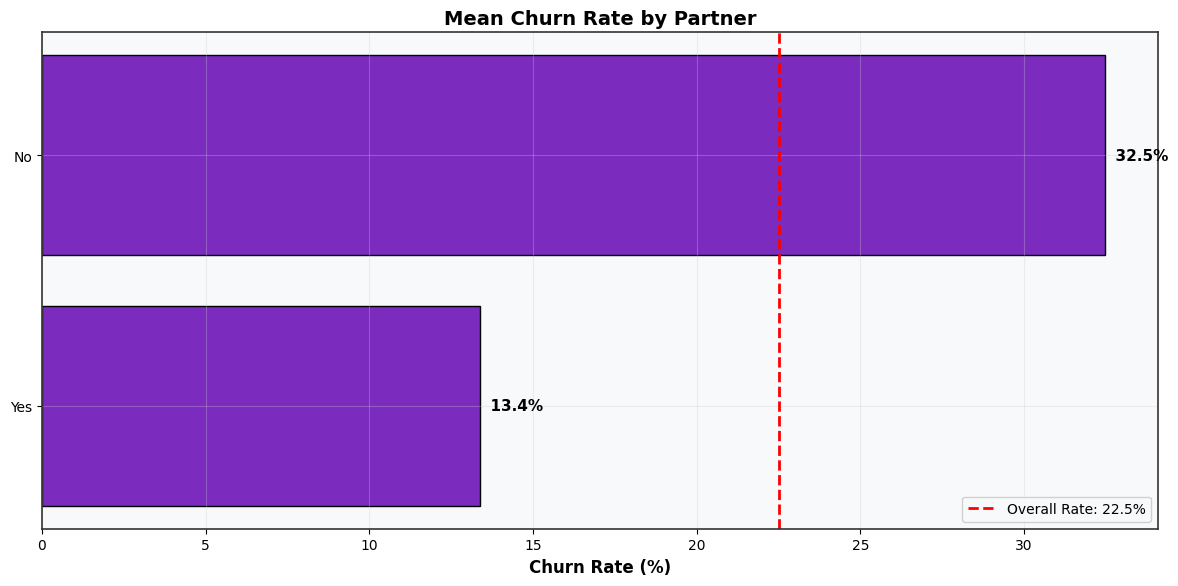

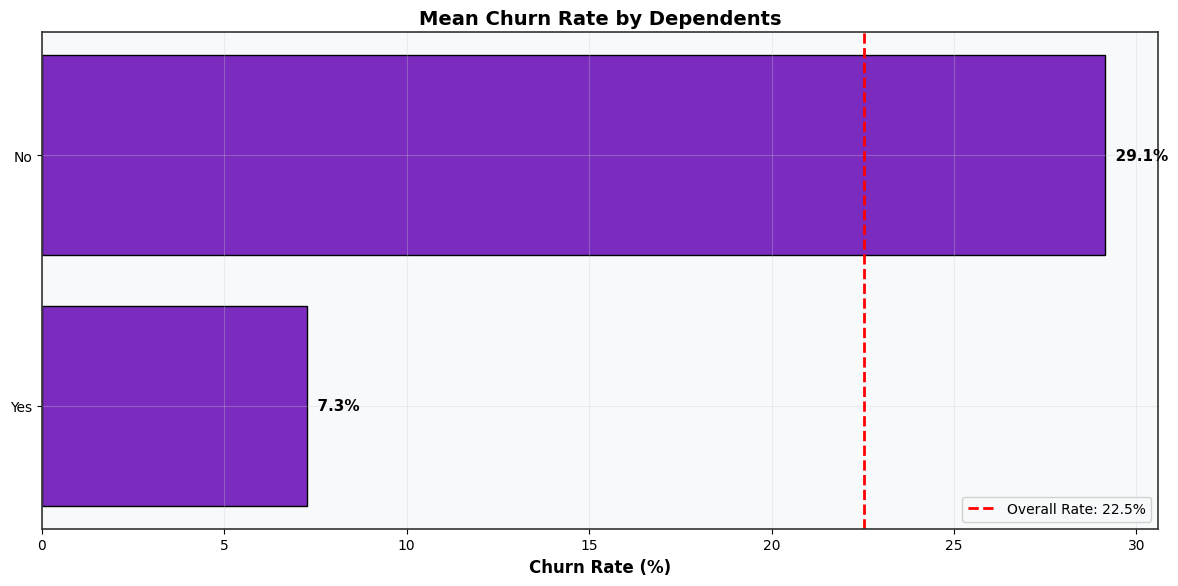

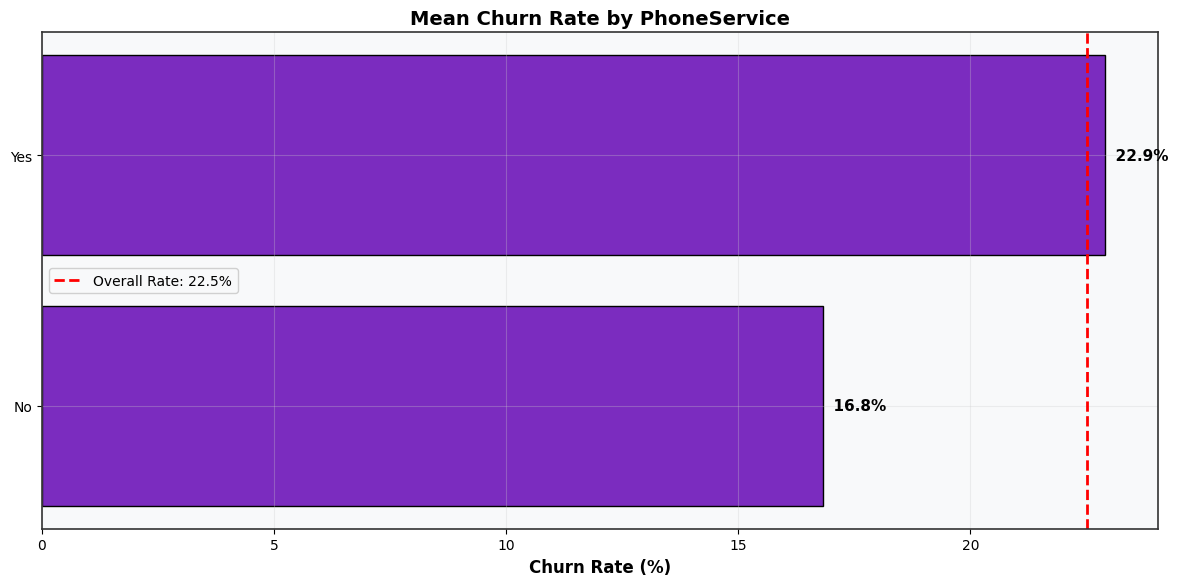

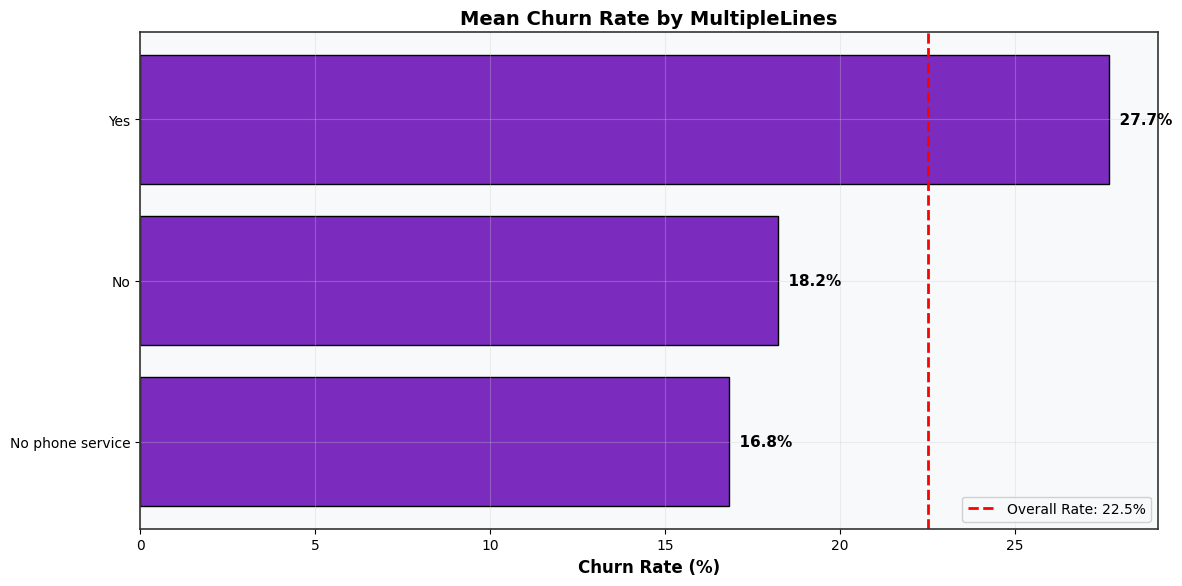

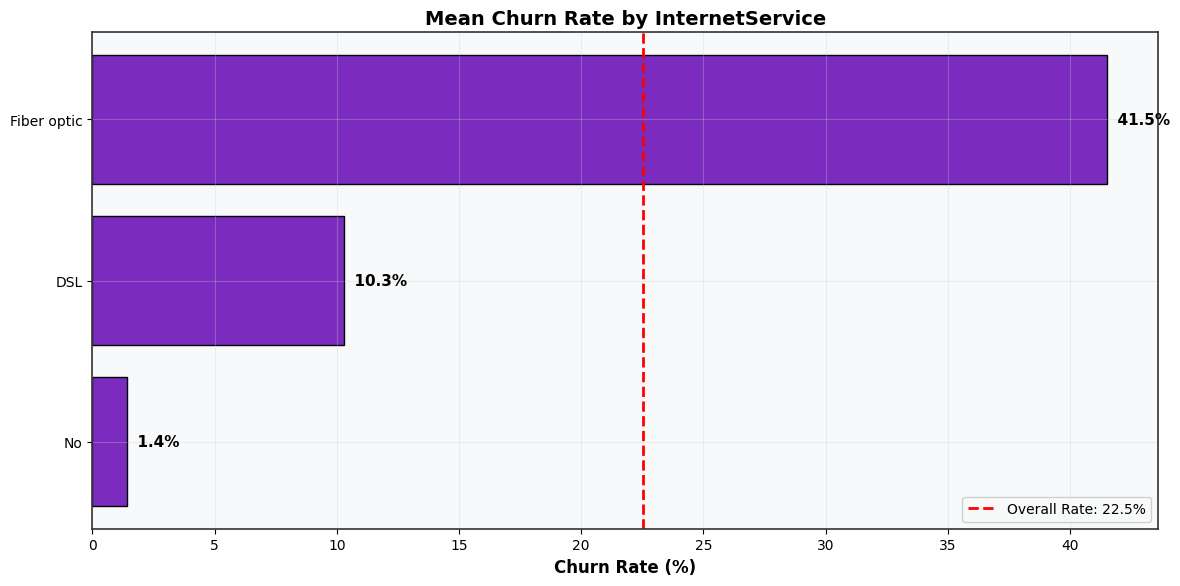

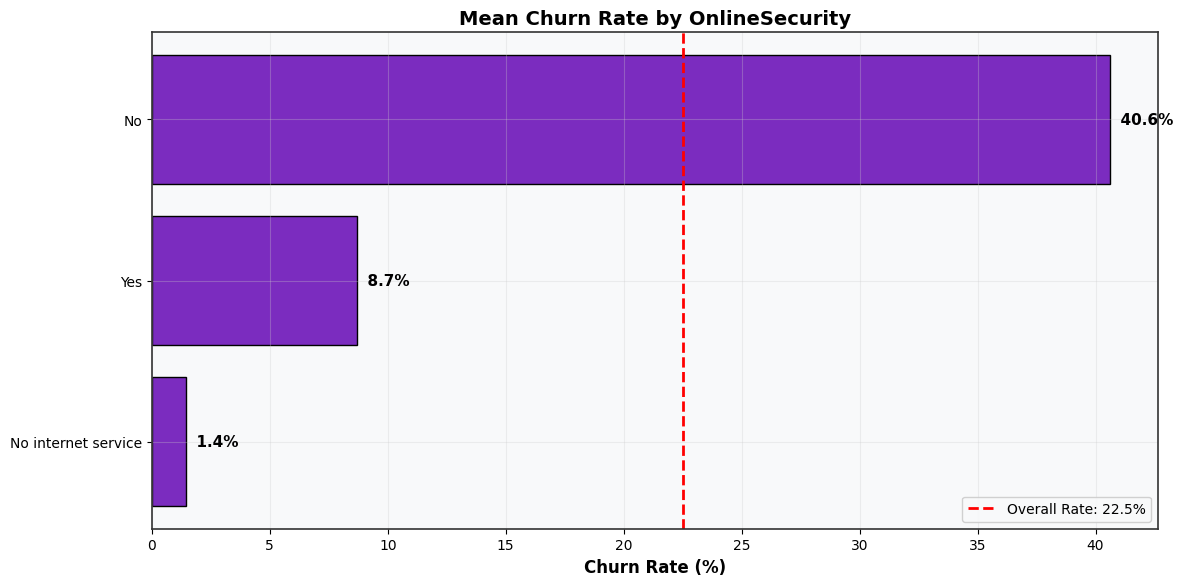

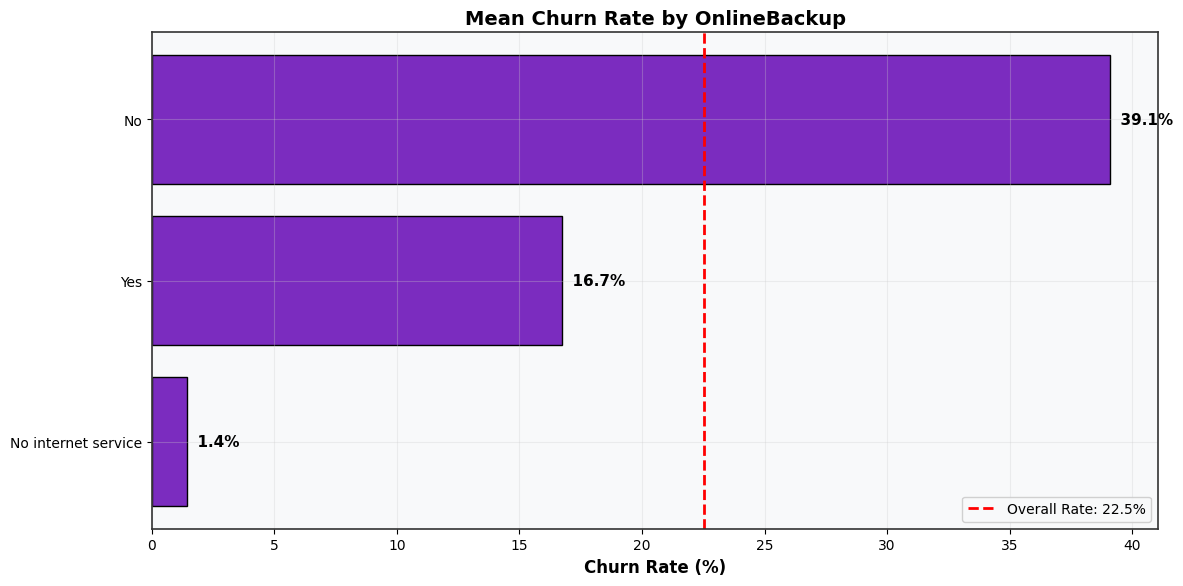

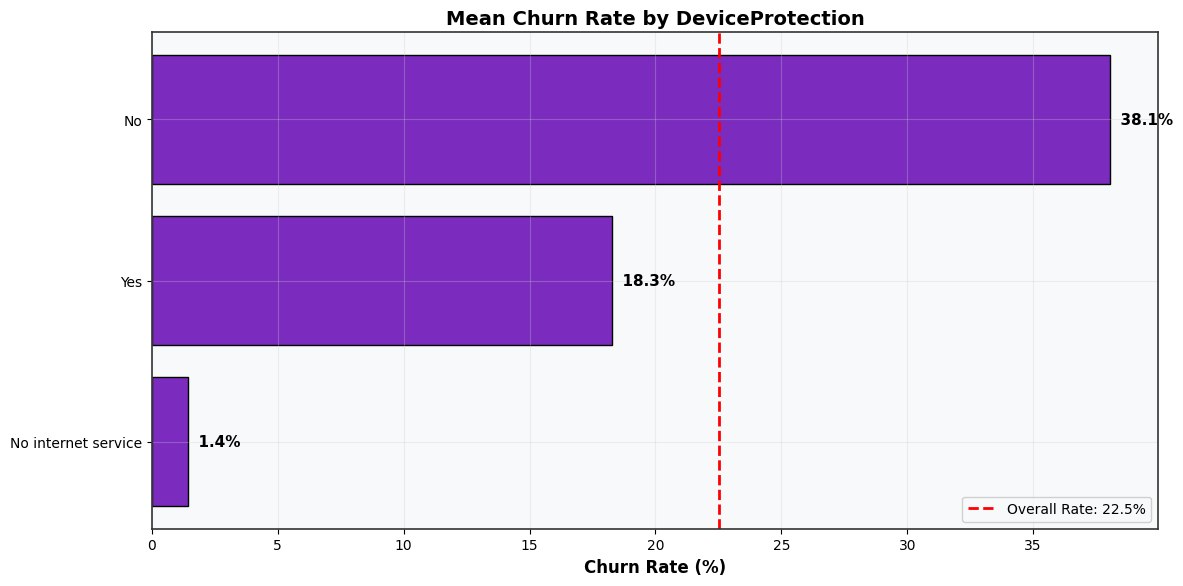

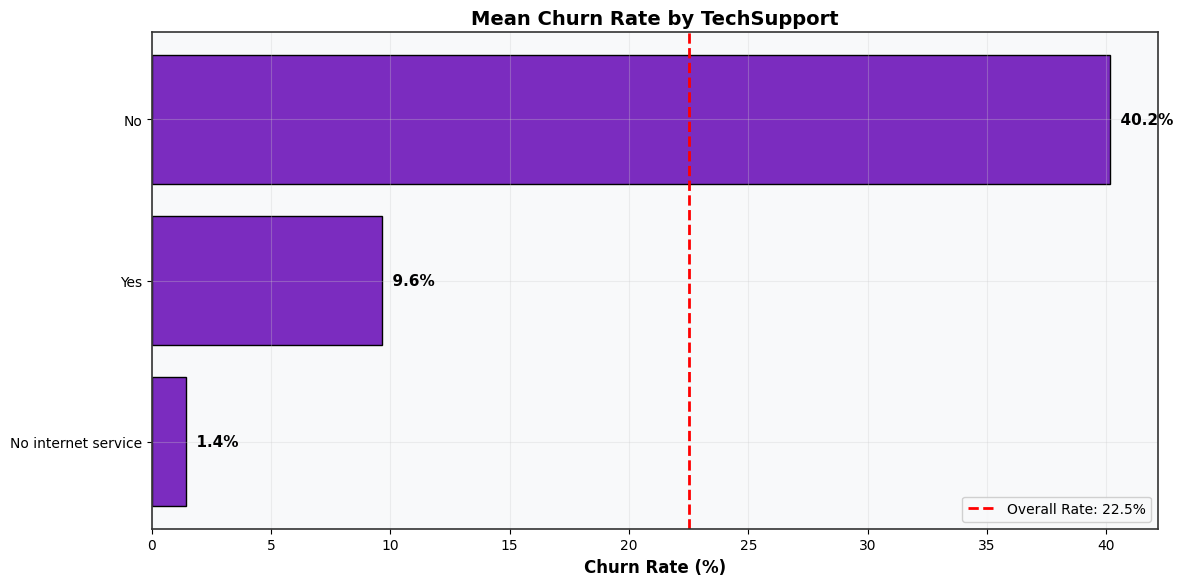

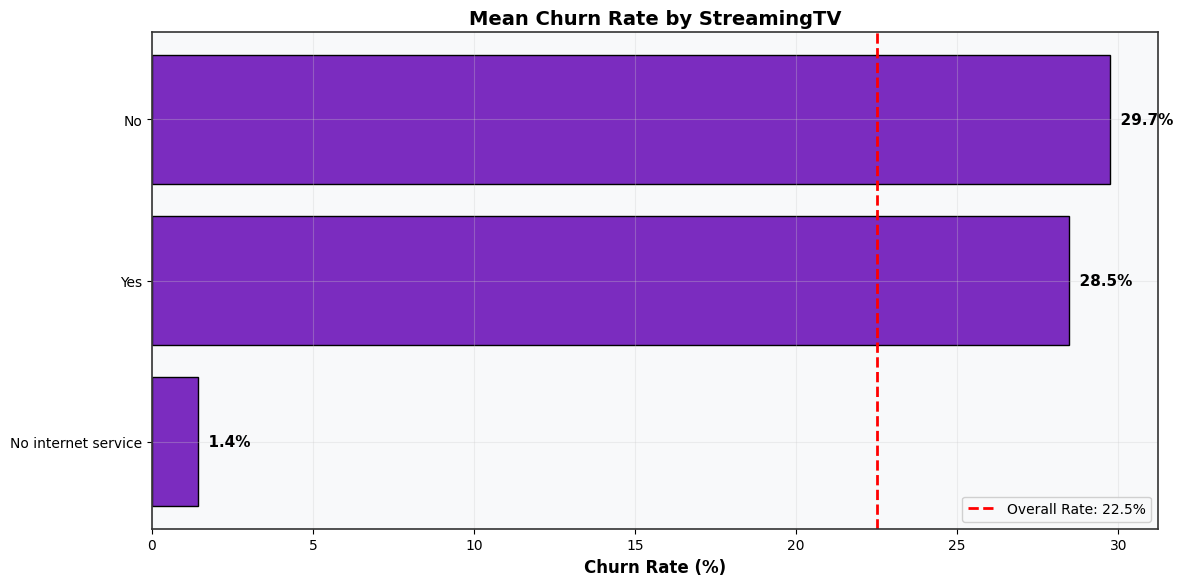

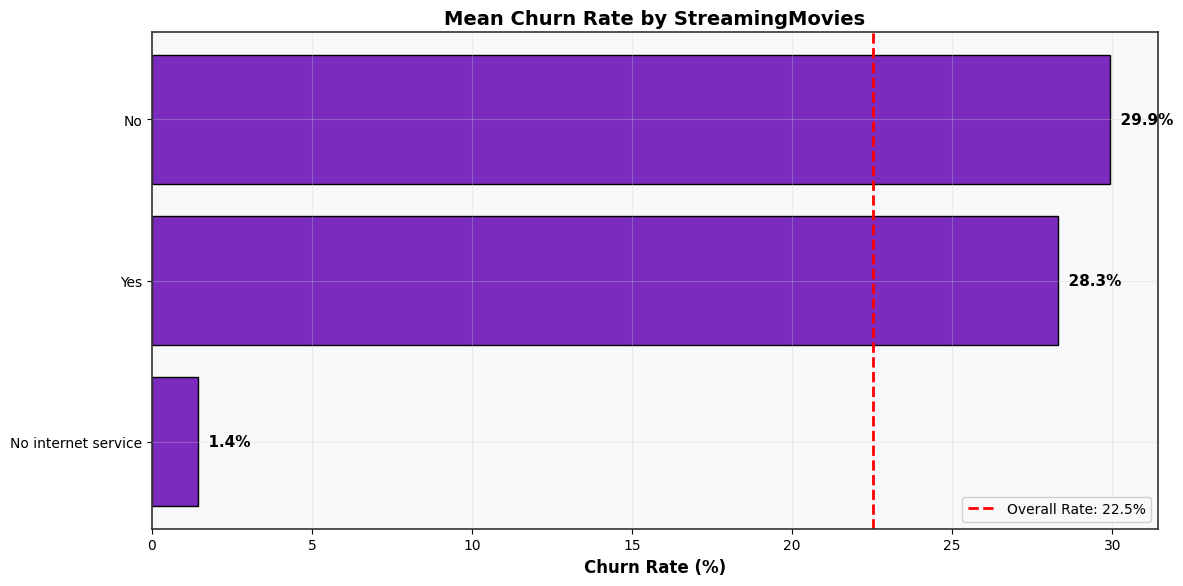

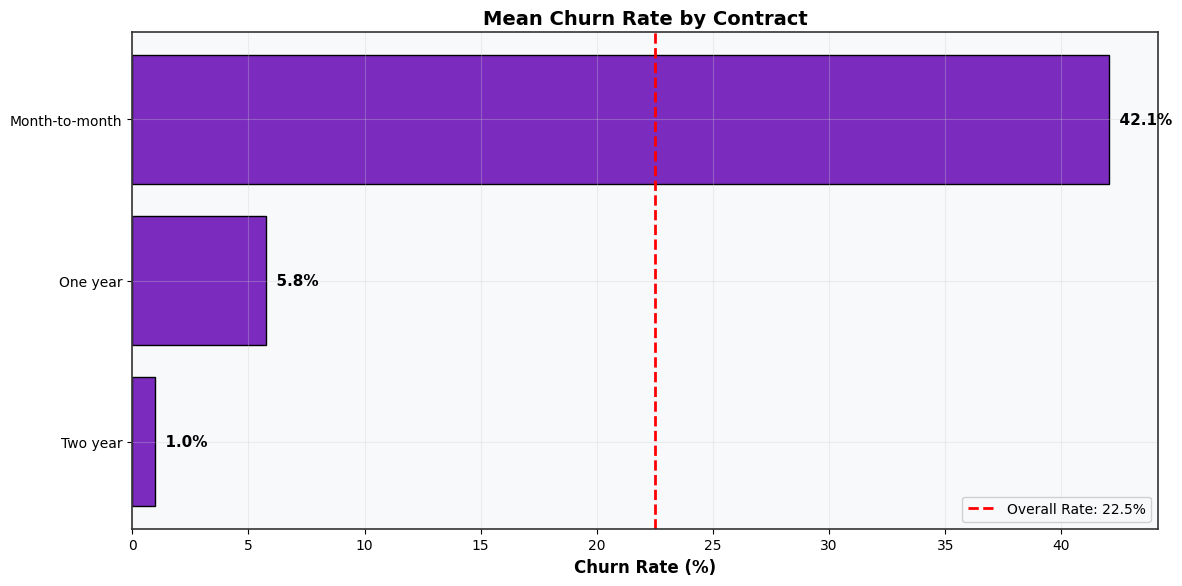

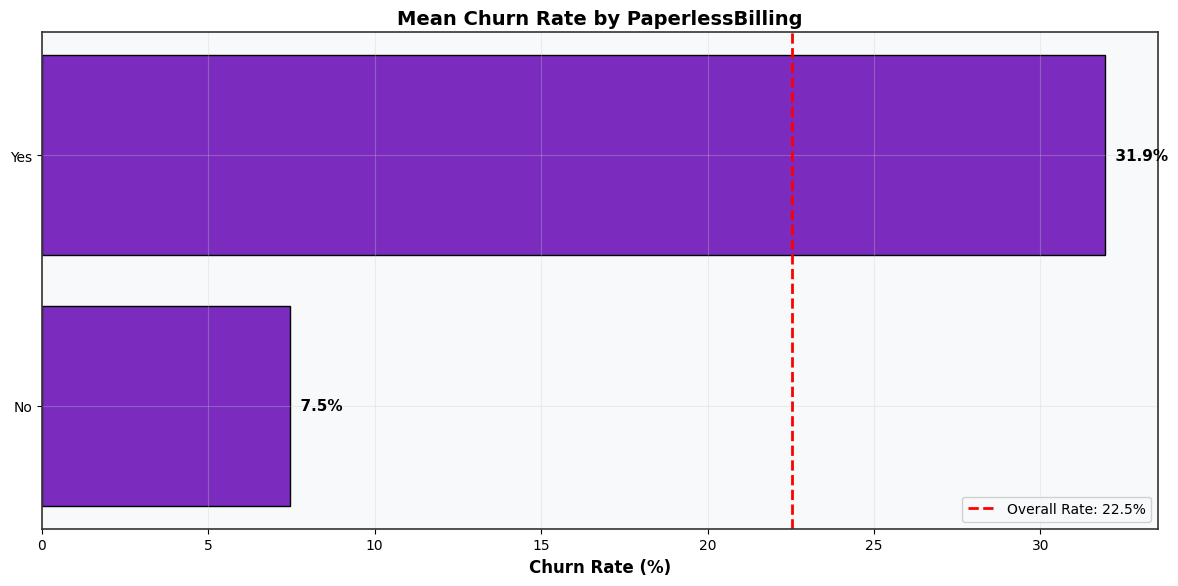

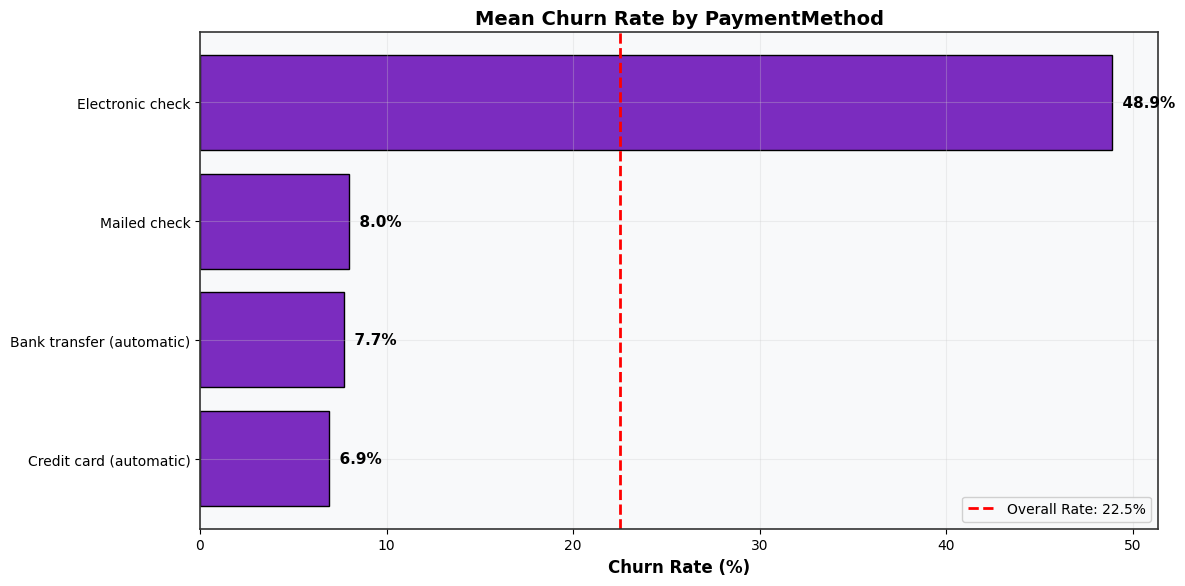

  FEATURE vs TARGET ANALYSIS COMPLETED ✅


In [21]:
if len(categorical_cols) > 0:
    for col in categorical_cols:
        mean_target = train.groupby(col)[CONFIG['TARGET']].mean().sort_values(ascending=True) * 100
        
        fig, ax = plt.subplots(figsize=(12, max(6, len(mean_target) * 0.4)))
        
        bars = ax.barh(range(len(mean_target)), mean_target.values,
                       color=COLORS[0], edgecolor='black', linewidth=1)
        ax.set_yticks(range(len(mean_target)))
        ax.set_yticklabels(mean_target.index)
        ax.set_xlabel('Churn Rate (%)', fontweight='bold')
        ax.set_title(f'Mean Churn Rate by {col}', fontweight='bold')
        
        overall_rate = train[CONFIG['TARGET']].mean() * 100
        ax.axvline(x=overall_rate, color='red', linestyle='--', linewidth=2,
                  label=f'Overall Rate: {overall_rate:.1f}%')
        ax.legend()
        
        for i, (bar, val) in enumerate(zip(bars, mean_target.values)):
            width = bar.get_width()
            ax.text(width, bar.get_y() + bar.get_height()/2,
                   f'  {val:.1f}%', ha='left', va='center', fontweight='bold')
        
        plt.tight_layout()
        plt.show()

print("=" * 70)
print("  FEATURE vs TARGET ANALYSIS COMPLETED ✅")
print("=" * 70)

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>9. CORRELATION ANALYSIS</b></div>

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
PEARSON CORRELATION HEATMAP<br>
</div>

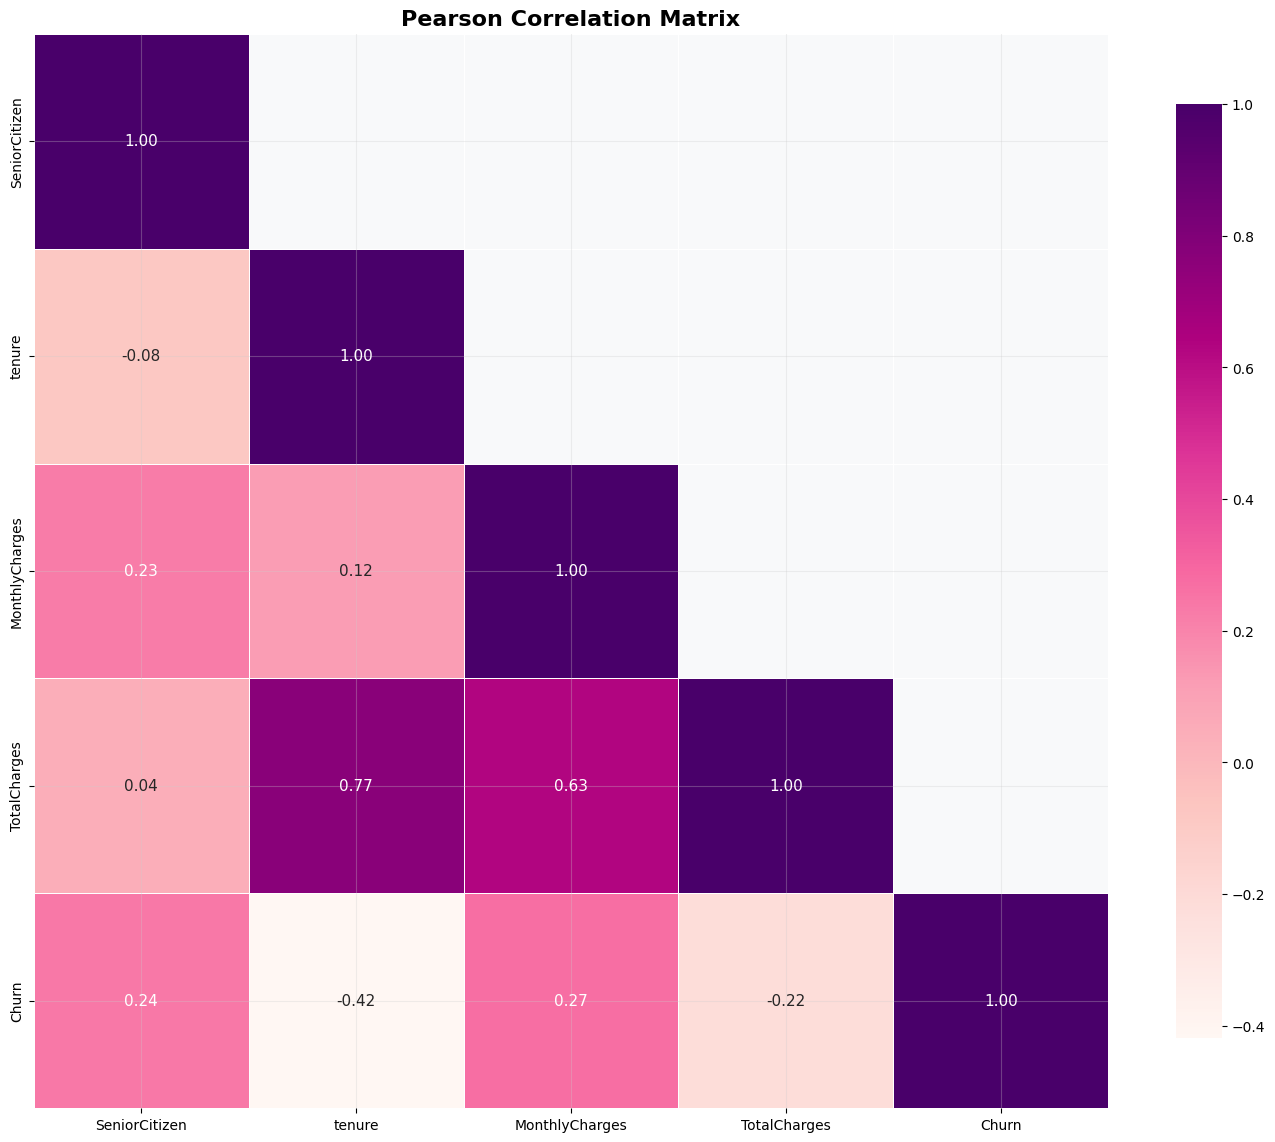

In [22]:
if len(numerical_cols) > 0:
    corr_cols = numerical_cols + [CONFIG['TARGET']]
    corr_matrix = train[corr_cols].corr()
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdPu',
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
    ax.set_title('Pearson Correlation Matrix', fontweight='bold', fontsize=16)
    
    plt.tight_layout()
    plt.show()

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
TOP FEATURES CORRELATED WITH TARGET<br>
</div>

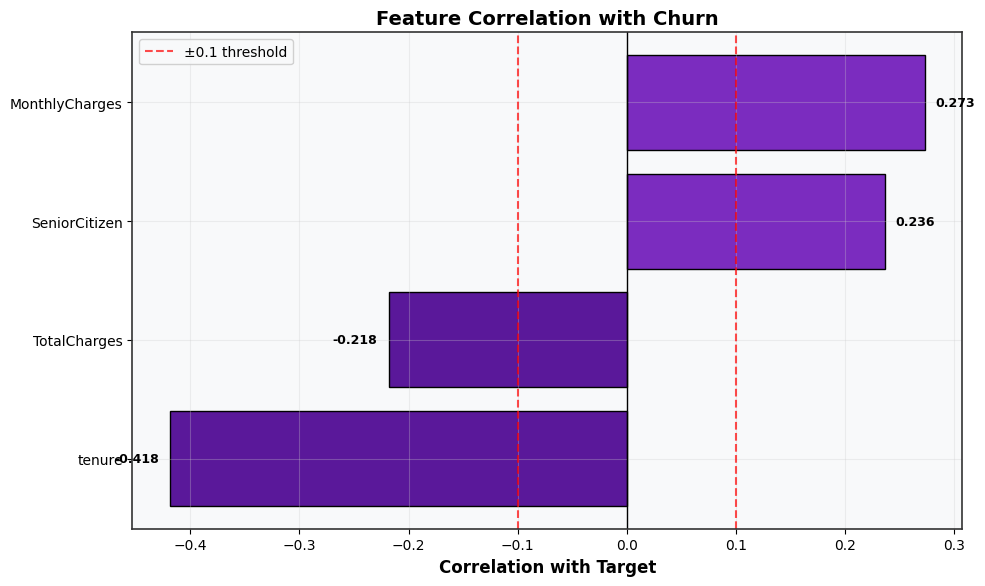

In [23]:
if len(numerical_cols) > 0:
    target_corr = train[corr_cols].corr()[CONFIG['TARGET']].drop(CONFIG['TARGET']).sort_values(ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, max(6, len(target_corr) * 0.4)))
    
    colors = [COLORS[0] if x > 0 else COLORS[4] for x in target_corr.values]
    bars = ax.barh(range(len(target_corr)), target_corr.values, color=colors,
                   edgecolor='black', linewidth=1)
    ax.set_yticks(range(len(target_corr)))
    ax.set_yticklabels(target_corr.index)
    ax.set_xlabel('Correlation with Target', fontweight='bold')
    ax.set_title('Feature Correlation with Churn', fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.axvline(x=0.1, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='±0.1 threshold')
    ax.axvline(x=-0.1, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.legend()
    
    for i, (bar, val) in enumerate(zip(bars, target_corr.values)):
        width = bar.get_width()
        x_pos = width + 0.01 if width > 0 else width - 0.01
        ha = 'left' if width > 0 else 'right'
        ax.text(x_pos, bar.get_y() + bar.get_height()/2,
               f'{val:.3f}', ha=ha, va='center', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.show()

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
SPEARMAN CORRELATION HEATMAP<br>
</div>

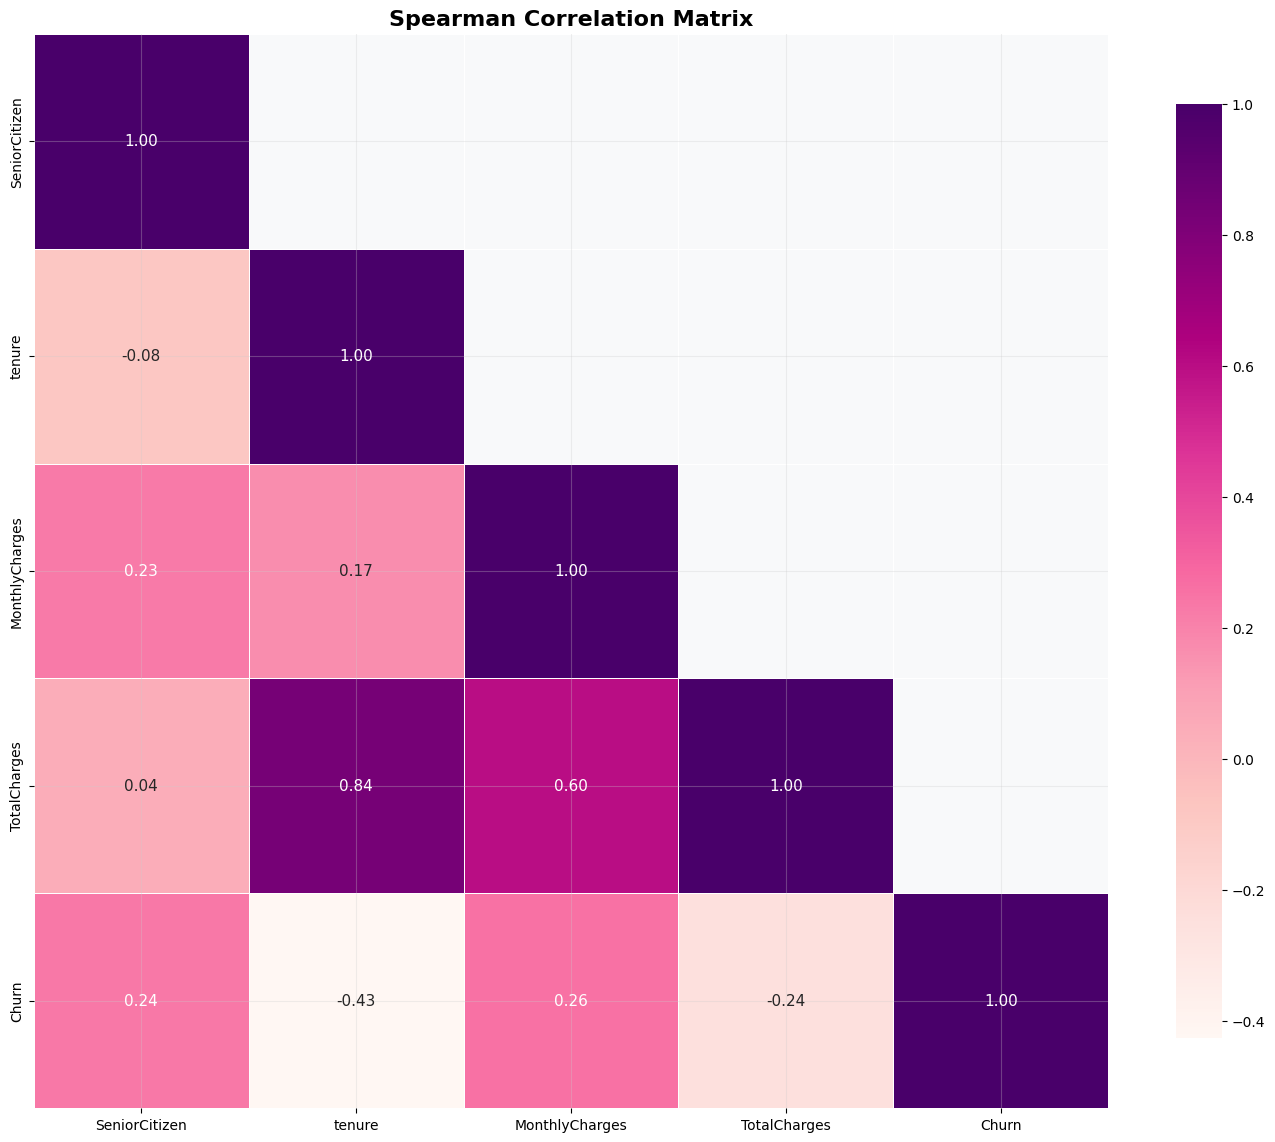

  CORRELATION ANALYSIS COMPLETED ✅


In [24]:
if len(numerical_cols) > 0:
    spearman_corr = train[corr_cols].corr(method='spearman')
    
    mask = np.triu(np.ones_like(spearman_corr, dtype=bool), k=1)
    
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.2f', cmap='RdPu',
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
    ax.set_title('Spearman Correlation Matrix', fontweight='bold', fontsize=16)
    
    plt.tight_layout()
    plt.show()

print("=" * 70)
print("  CORRELATION ANALYSIS COMPLETED ✅")
print("=" * 70)

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>10. TRAIN vs TEST DISTRIBUTION COMPARISON</b></div>

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
KS TEST RESULTS<br>
</div>

In [25]:
if len(numerical_cols) > 0:
    ks_results = []
    for col in numerical_cols:
        if col in test.columns:
            ks_stat, p_value = ks_2samp(train[col].dropna(), test[col].dropna())
            ks_results.append({
                'Feature': col,
                'KS_Statistic': ks_stat,
                'P_Value': p_value
            })
    
    ks_df = pd.DataFrame(ks_results).sort_values('KS_Statistic', ascending=False)
    display(ks_df.style.background_gradient(subset=['KS_Statistic'], cmap='RdPu'))
    
    print(f"\nFeatures with significant distribution shift (KS > 0.1): {len(ks_df[ks_df['KS_Statistic'] > 0.1])}")

,Feature,KS_Statistic,P_Value
3,TotalCharges,0.017710,0.000000
1,tenure,0.017068,0.000000
2,MonthlyCharges,0.006531,0.000000
0,SeniorCitizen,0.000482,1.000000



Features with significant distribution shift (KS > 0.1): 0


<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
DISTRIBUTION SHIFT PLOTS<br>
</div>

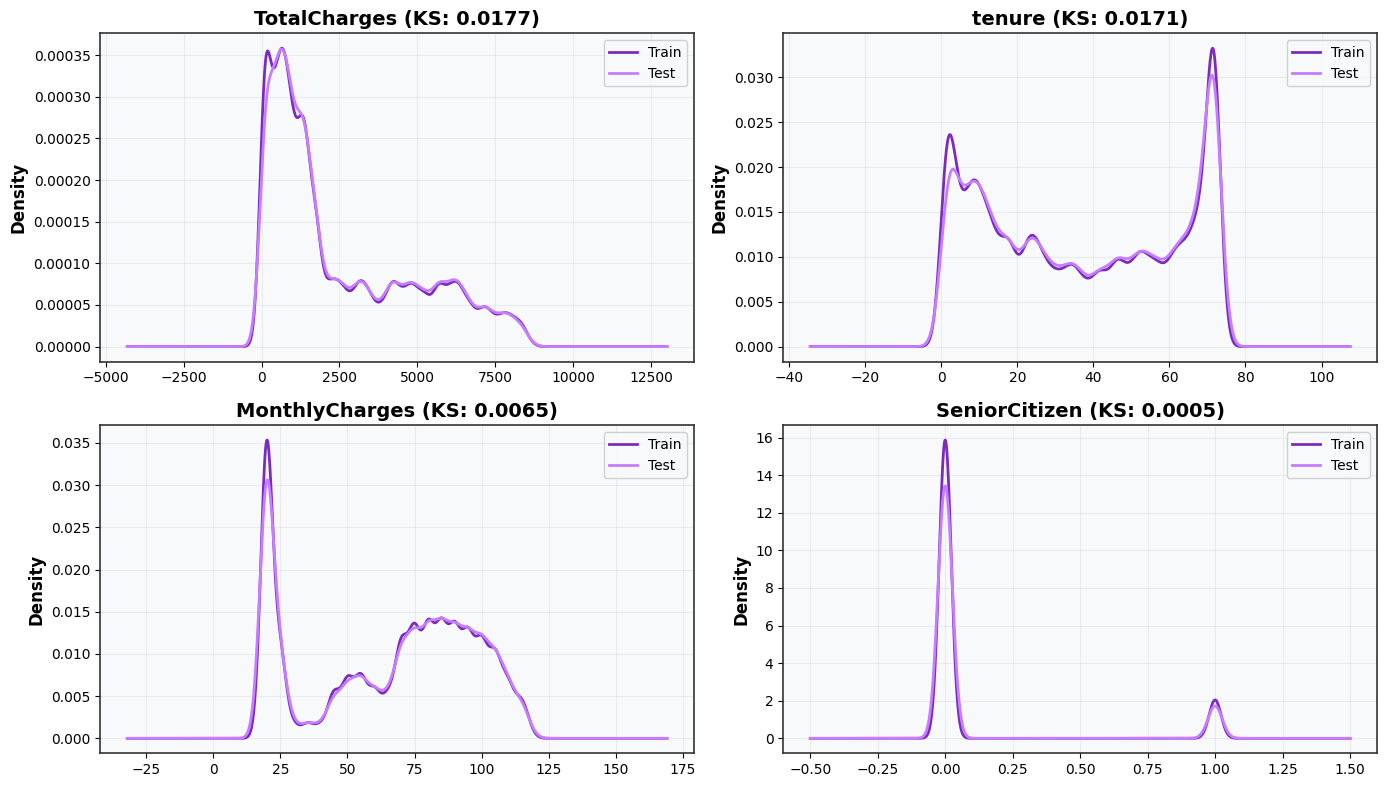

In [26]:
if len(numerical_cols) > 0:
    top_features = ks_df.head(8)['Feature'].tolist()
    
    n_cols = 2
    n_rows = (len(top_features) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
    axes = axes.flatten() if n_rows > 1 else axes
    
    for idx, col in enumerate(top_features):
        ax = axes[idx]
        train[col].plot(kind='kde', ax=ax, color=COLORS[0], linewidth=2, label='Train')
        test[col].plot(kind='kde', ax=ax, color=COLORS[2], linewidth=2, label='Test')
        
        ks_stat = ks_df[ks_df['Feature'] == col]['KS_Statistic'].values[0]
        ax.set_title(f'{col} (KS: {ks_stat:.4f})', fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Density', fontweight='bold')
        ax.legend()
    
    for idx in range(len(top_features), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
CATEGORICAL FEATURE DISTRIBUTION SHIFT<br>
</div>

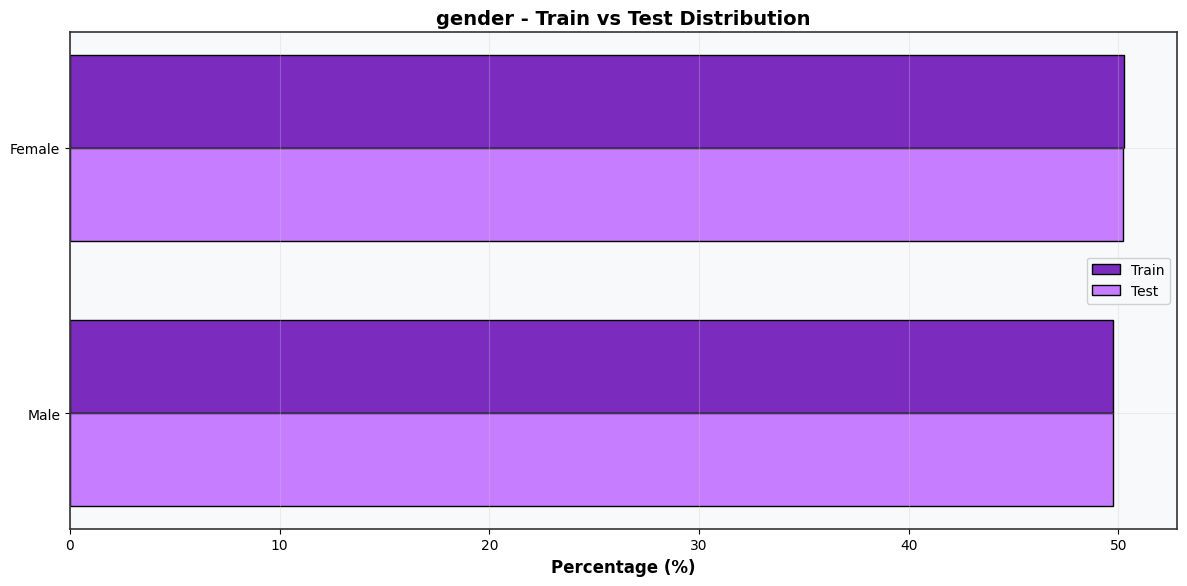

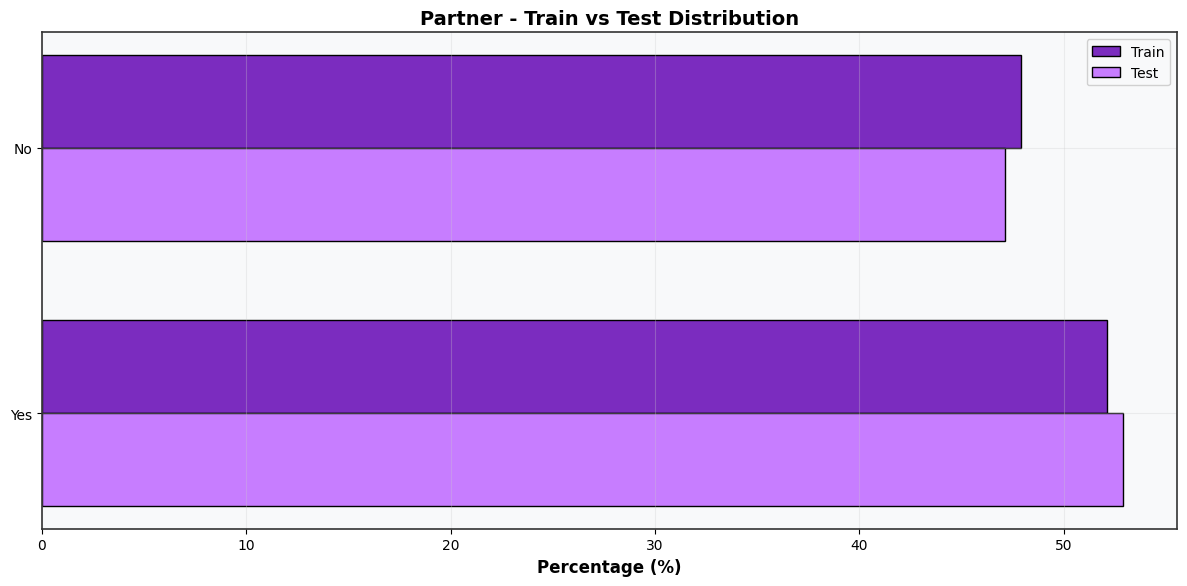

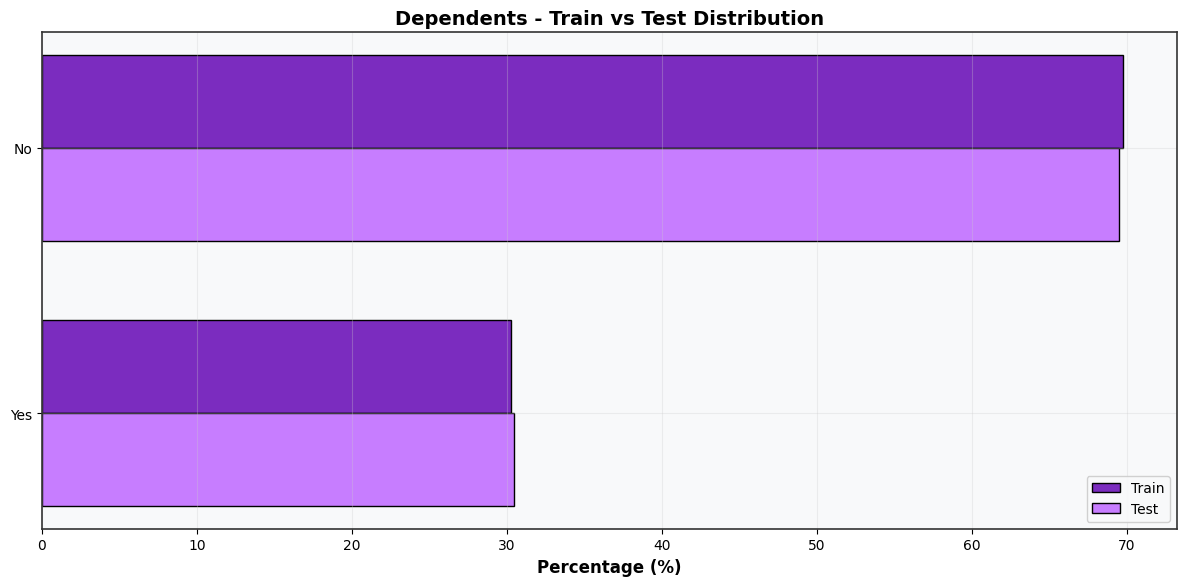

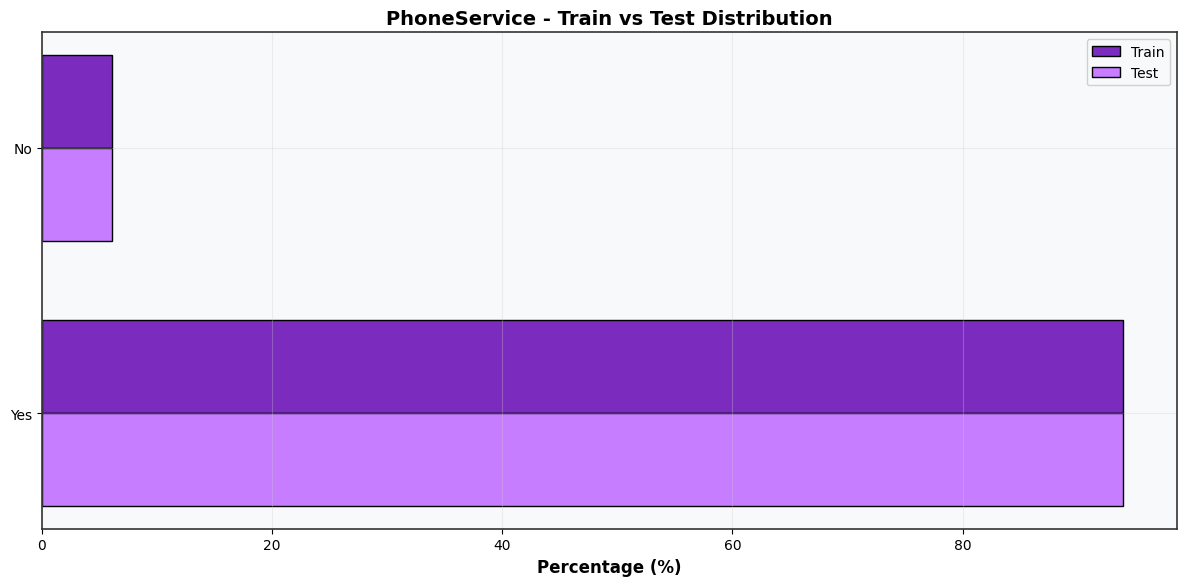

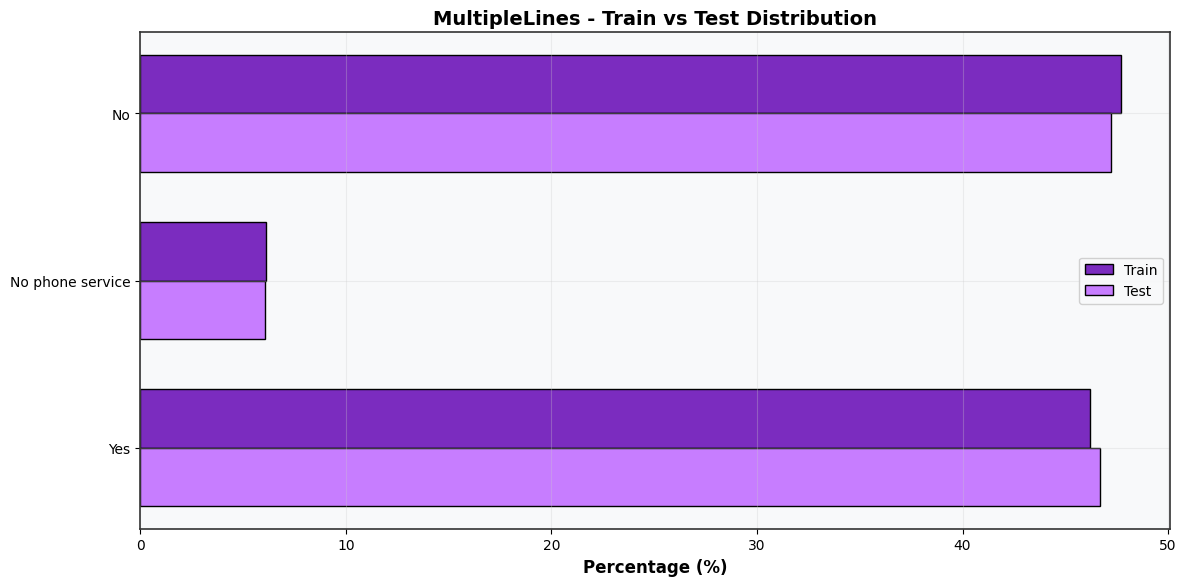

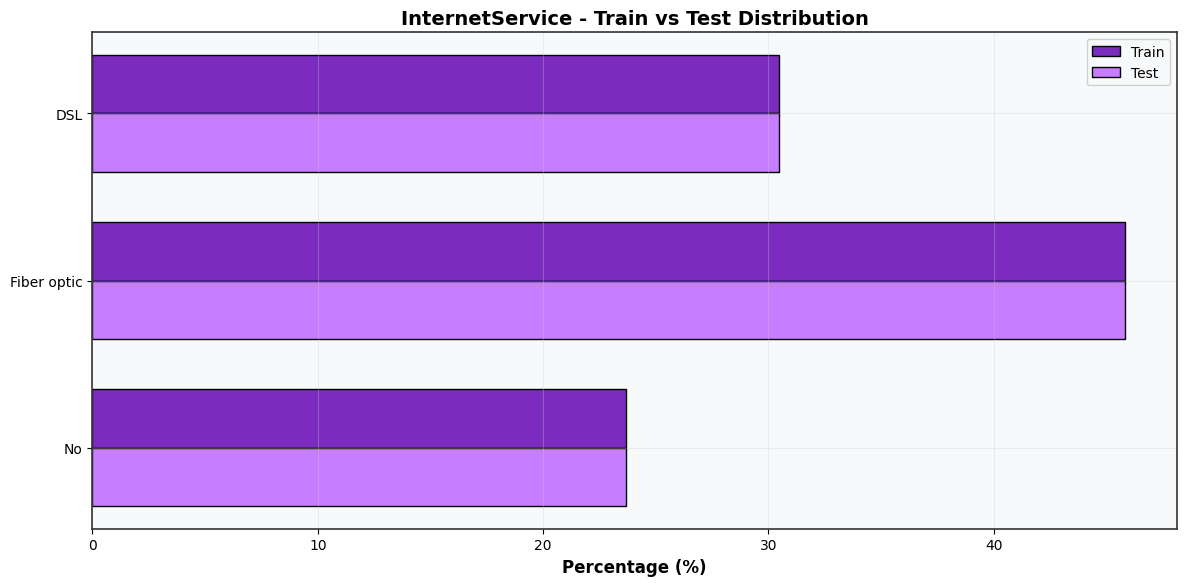

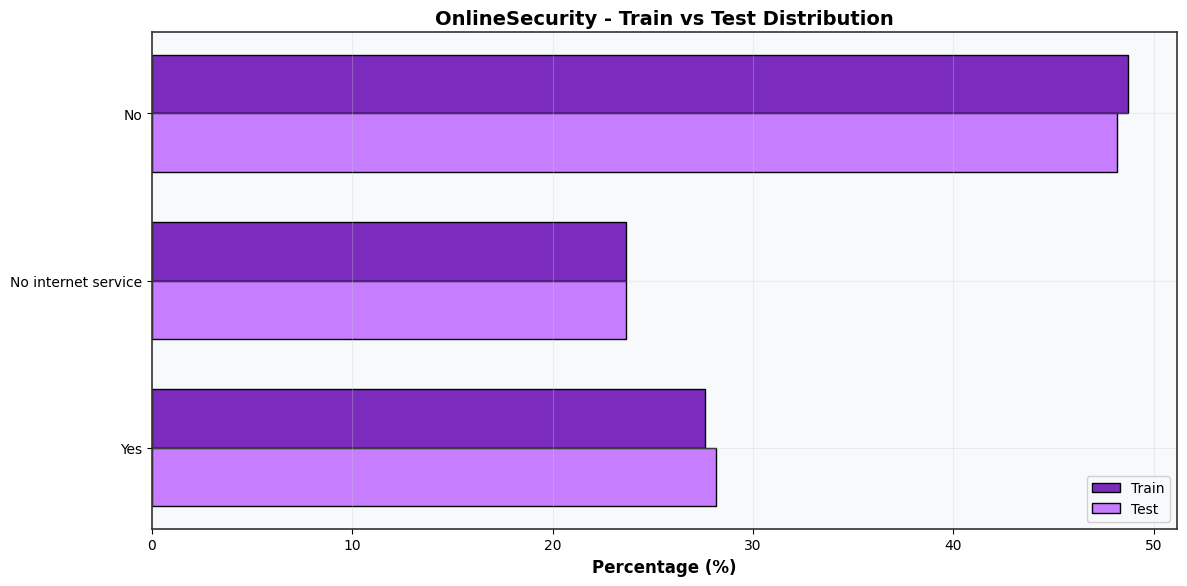

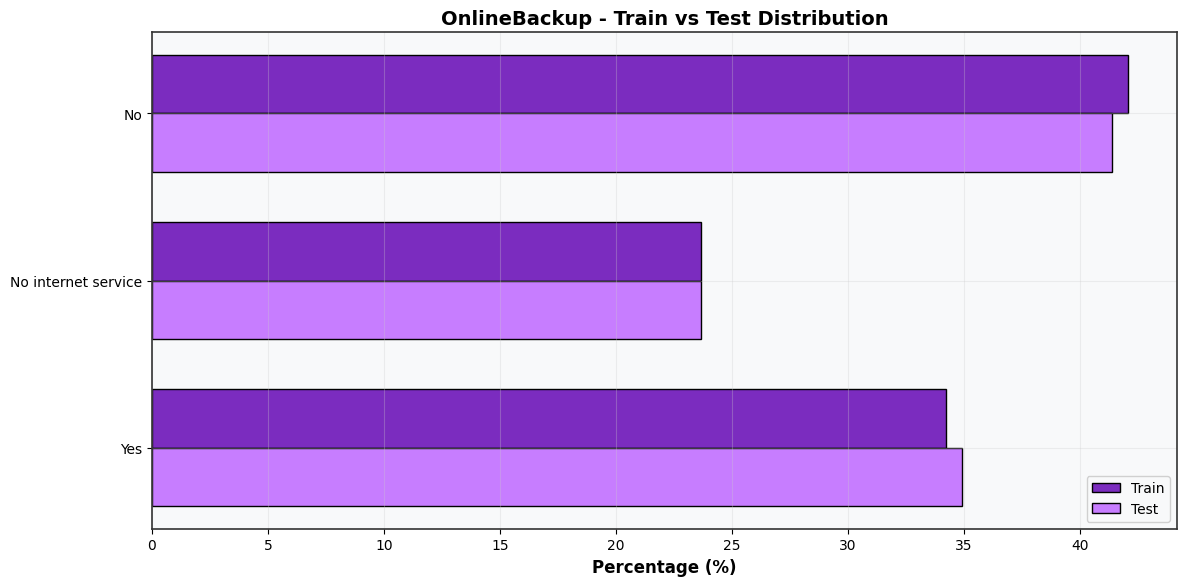

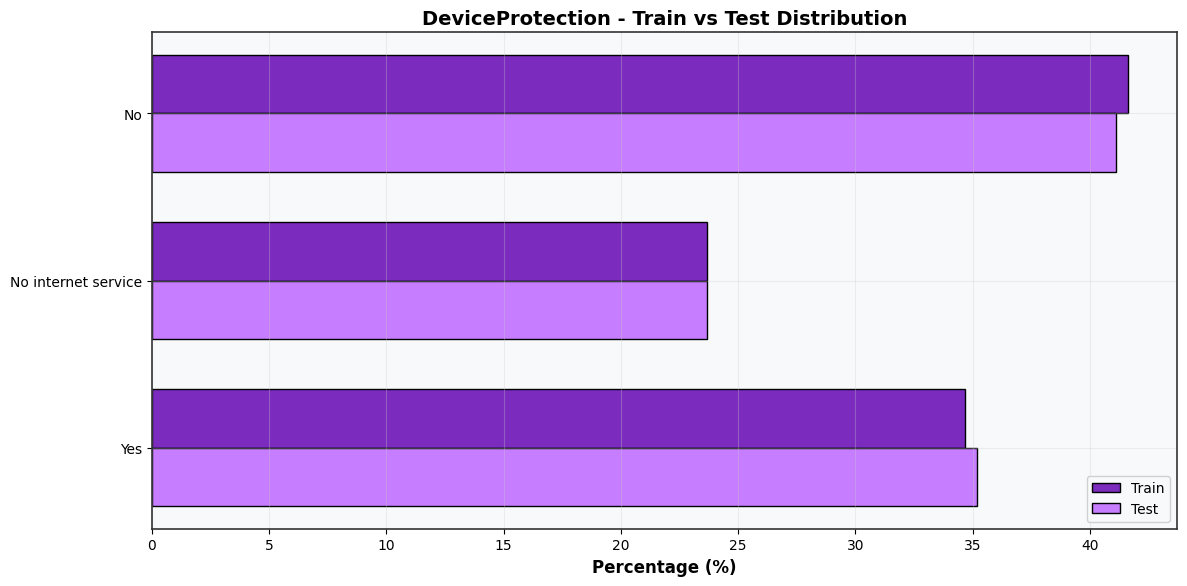

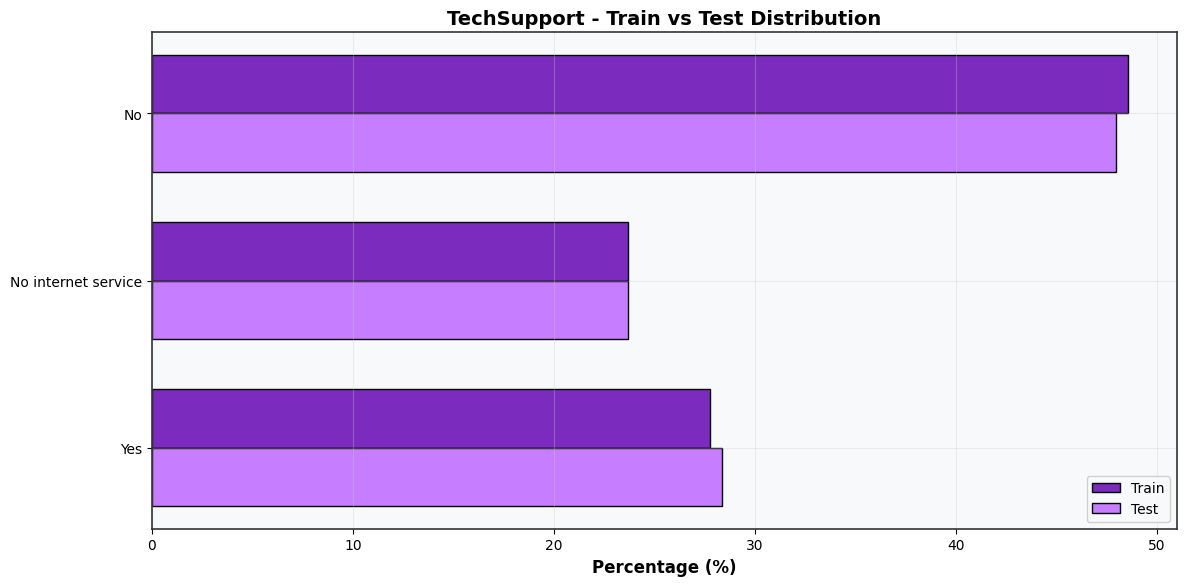

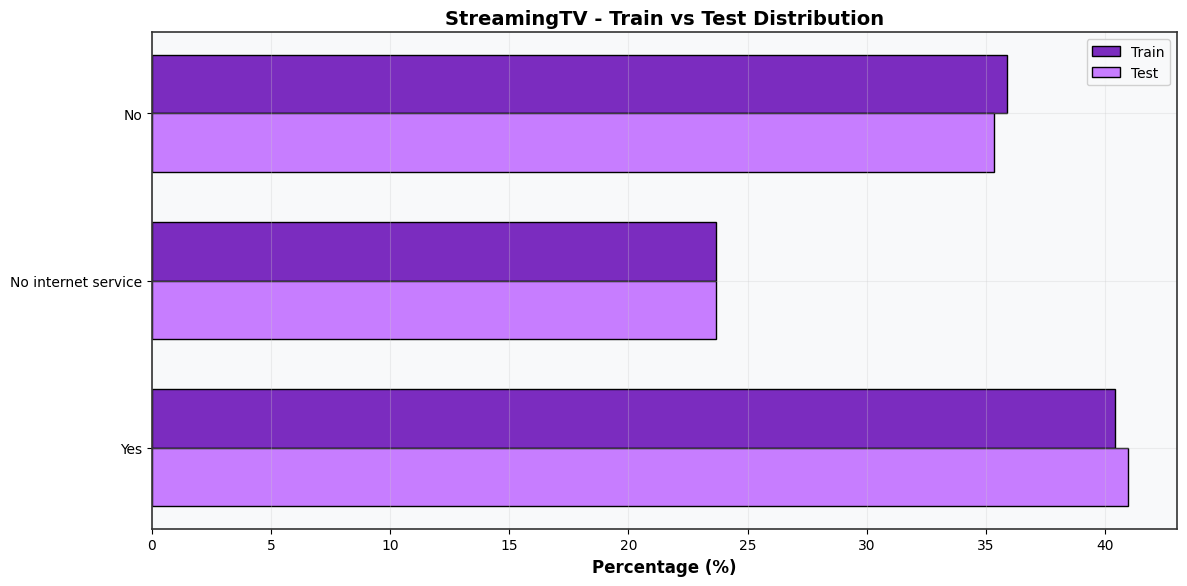

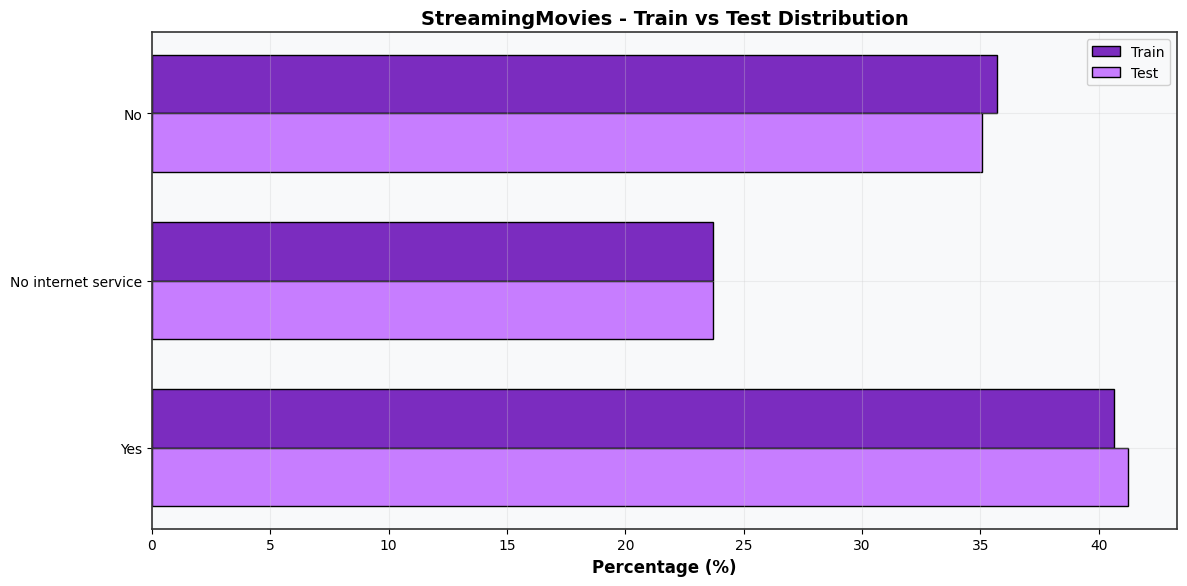

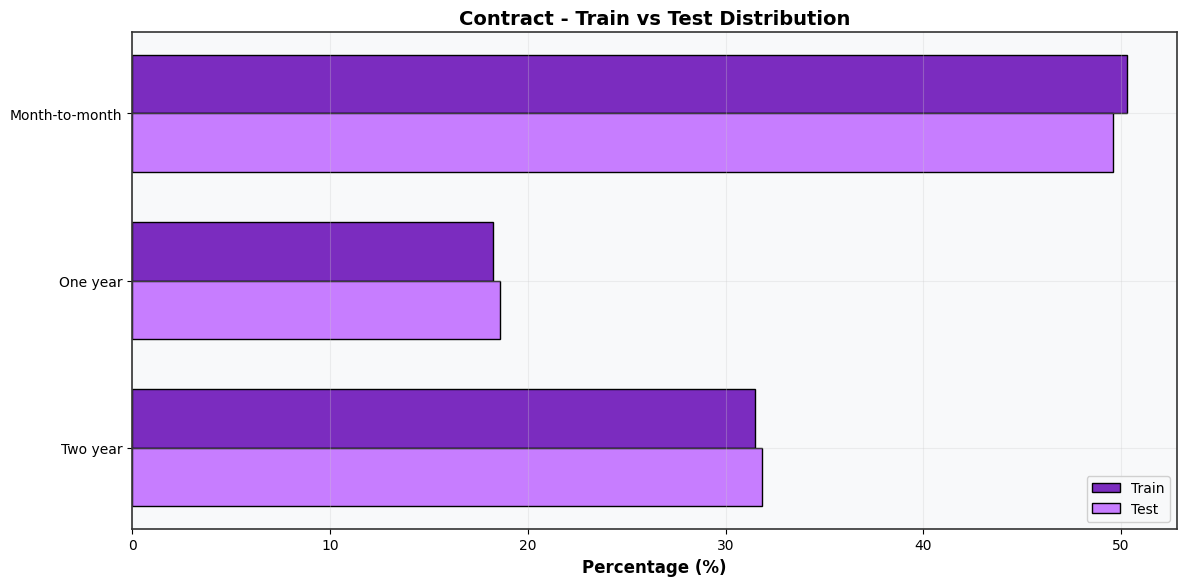

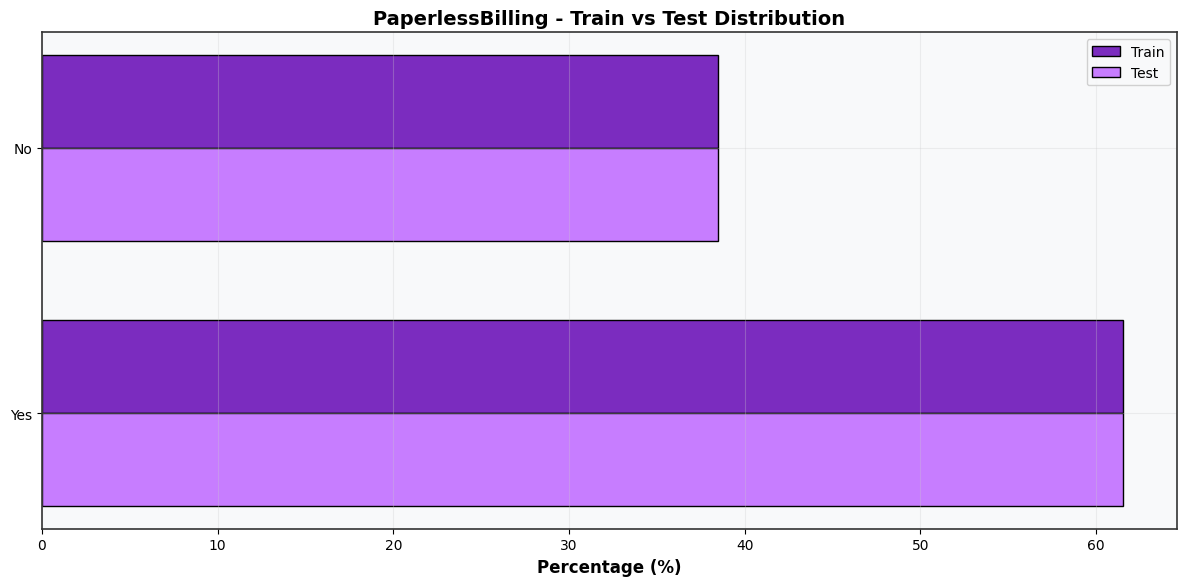

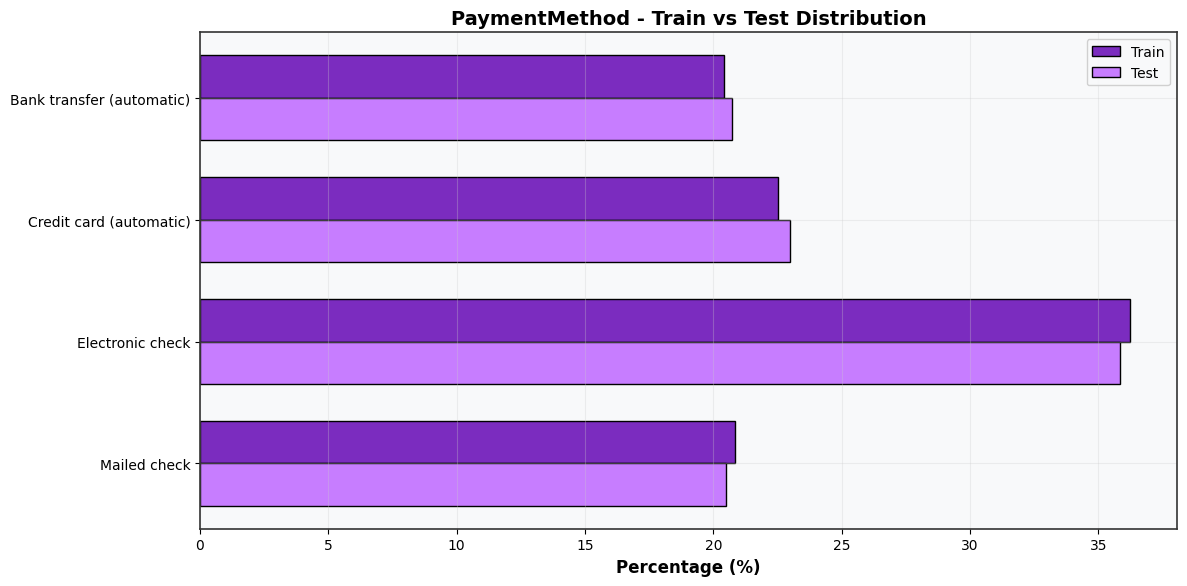

  TRAIN vs TEST COMPARISON COMPLETED ✅


In [27]:
if len(categorical_cols) > 0:
    for col in categorical_cols:
        if col in test.columns:
            train_pct = train[col].value_counts(normalize=True).head(15) * 100
            test_pct = test[col].value_counts(normalize=True).head(15) * 100
            
            all_cats = sorted(set(train_pct.index.tolist() + test_pct.index.tolist()))
            train_aligned = [train_pct.get(cat, 0) for cat in all_cats]
            test_aligned = [test_pct.get(cat, 0) for cat in all_cats]
            
            fig, ax = plt.subplots(figsize=(12, max(6, len(all_cats) * 0.4)))
            
            y_pos = np.arange(len(all_cats))
            width = 0.35
            
            ax.barh(y_pos - width/2, train_aligned, width, label='Train',
                   color=COLORS[0], edgecolor='black', linewidth=1)
            ax.barh(y_pos + width/2, test_aligned, width, label='Test',
                   color=COLORS[2], edgecolor='black', linewidth=1)
            
            ax.set_yticks(y_pos)
            ax.set_yticklabels(all_cats)
            ax.set_xlabel('Percentage (%)', fontweight='bold')
            ax.set_title(f'{col} - Train vs Test Distribution', fontweight='bold')
            ax.legend()
            ax.invert_yaxis()
            
            plt.tight_layout()
            plt.show()

print("=" * 70)
print("  TRAIN vs TEST COMPARISON COMPLETED ✅")
print("=" * 70)

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>11. ORIGINAL DATASET vs COMPETITION DATASET</b></div>

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
SIZE & OVERLAP SUMMARY<br>
</div>

In [28]:
train_cols_set = set(train.columns)
orig_cols_set = set(original.columns)

shared_cols = train_cols_set.intersection(orig_cols_set)
train_only = train_cols_set - orig_cols_set
orig_only = orig_cols_set - train_cols_set

print("Dataset Comparison Summary:")
print("=" * 70)
print(f"Competition Train Rows : {len(train):,}")
print(f"Original Dataset Rows  : {len(original):,}")
print(f"Row Ratio (Comp/Orig)  : {len(train)/len(original):.2f}x")
print()
print(f"Competition Columns    : {len(train.columns)}")
print(f"Original Columns       : {len(original.columns)}")
print(f"Shared Columns         : {len(shared_cols)}")
print(f"Competition-Only Cols  : {len(train_only)} - {list(train_only)}")
print(f"Original-Only Cols     : {len(orig_only)} - {list(orig_only)[:10]}...")
print(f"Target in Original     : {'Churn' in original.columns}")
print("=" * 70)

Dataset Comparison Summary:
Competition Train Rows : 594,194
Original Dataset Rows  : 7,043
Row Ratio (Comp/Orig)  : 84.37x

Competition Columns    : 21
Original Columns       : 21
Shared Columns         : 20
Competition-Only Cols  : 1 - ['id']
Original-Only Cols     : 1 - ['customerID']...
Target in Original     : True


<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
DISTRIBUTION COMPARISON<br>
</div>

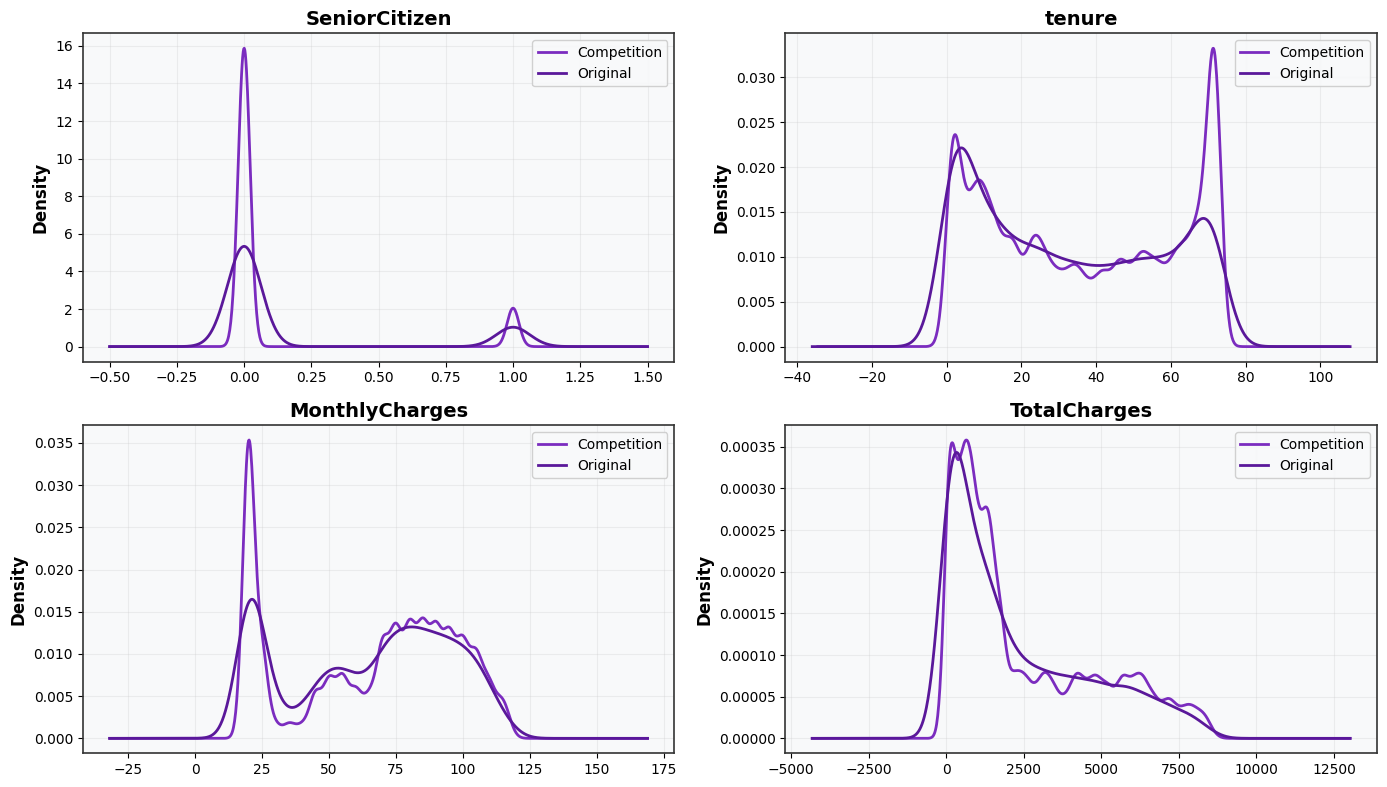

In [29]:
shared_numerical = [col for col in numerical_cols if col in original.columns]

if len(shared_numerical) > 0:
    top_num_features = shared_numerical[:min(6, len(shared_numerical))]
    
    n_cols = 2
    n_rows = (len(top_num_features) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes
    
    for idx, col in enumerate(top_num_features):
        ax = axes[idx]
        
        if original[col].dtype == 'object':
            original[col] = pd.to_numeric(original[col], errors='coerce')
        
        train[col].plot(kind='kde', ax=ax, color=COLORS[0], linewidth=2, label='Competition')
        original[col].dropna().plot(kind='kde', ax=ax, color=COLORS[4], linewidth=2, label='Original')
        
        ax.set_title(f'{col}', fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('Density', fontweight='bold')
        ax.legend()
    
    for idx in range(len(top_num_features), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
TARGET DISTRIBUTION IN ORIGINAL<br>
</div>

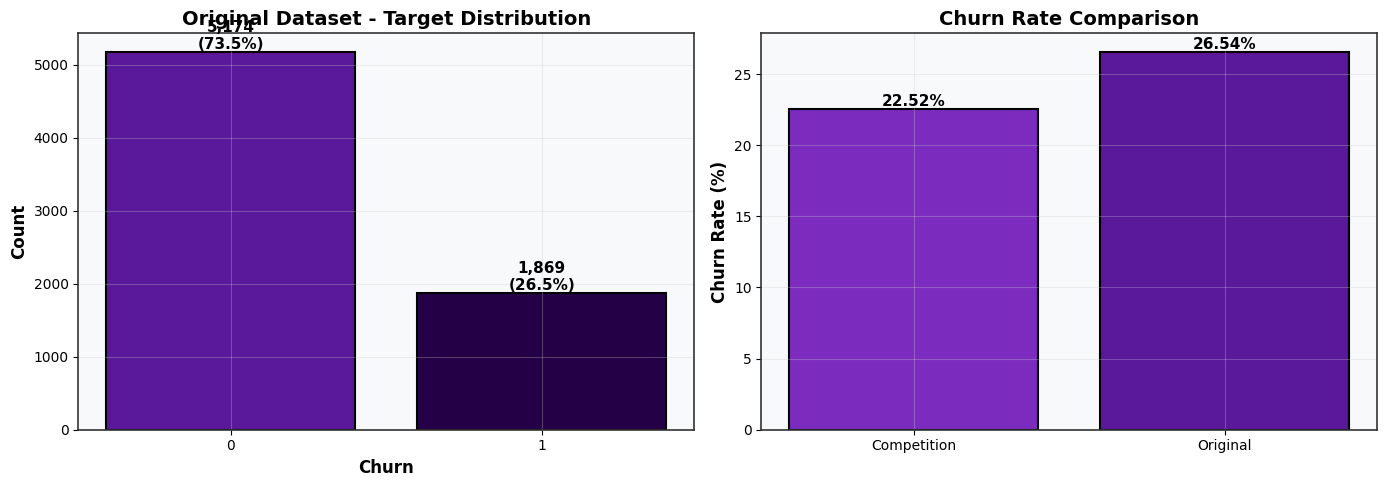

  ORIGINAL DATASET ANALYSIS COMPLETED ✅


In [30]:
if 'Churn' in original.columns:
    orig_churn = original['Churn'].map({'No': 0, 'Yes': 1}) if original['Churn'].dtype == 'object' else original['Churn']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax = axes[0]
    orig_counts = orig_churn.value_counts()
    orig_pcts = orig_churn.value_counts(normalize=True) * 100
    
    bars = ax.bar(orig_counts.index.astype(str), orig_counts.values,
                  color=[COLORS[4], COLORS[5]], edgecolor='black', linewidth=1.5)
    ax.set_xlabel('Churn', fontweight='bold')
    ax.set_ylabel('Count', fontweight='bold')
    ax.set_title('Original Dataset - Target Distribution', fontweight='bold')
    
    for bar, count, pct in zip(bars, orig_counts.values, orig_pcts.values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{count:,}\n({pct:.1f}%)',
               ha='center', va='bottom', fontweight='bold')
    
    ax = axes[1]
    comp_rate = train[CONFIG['TARGET']].mean() * 100
    orig_rate = orig_churn.mean() * 100
    
    bars = ax.bar(['Competition', 'Original'], [comp_rate, orig_rate],
                  color=[COLORS[0], COLORS[4]], edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Churn Rate (%)', fontweight='bold')
    ax.set_title('Churn Rate Comparison', fontweight='bold')
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.2f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

print("=" * 70)
print("  ORIGINAL DATASET ANALYSIS COMPLETED ✅")
print("=" * 70)

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>12. OUTLIER ANALYSIS</b></div>

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
IQR-BASED OUTLIER COUNT<br>
</div>

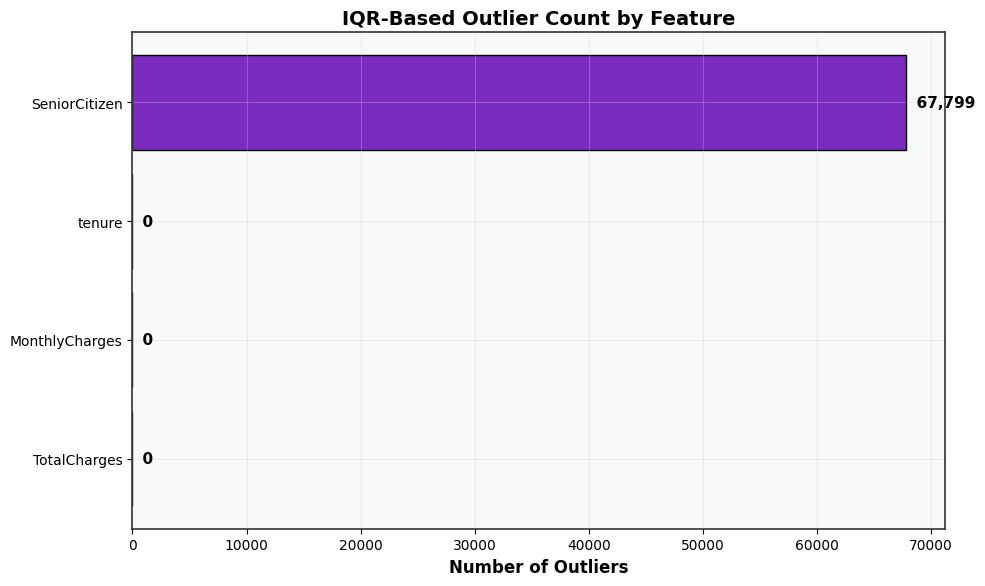


Total rows with at least one outlier: 67,799 (11.41%)


In [31]:
if len(numerical_cols) > 0:
    outlier_counts = {}
    
    for col in numerical_cols:
        Q1 = train[col].quantile(0.25)
        Q3 = train[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = train[(train[col] < lower_bound) | (train[col] > upper_bound)]
        outlier_counts[col] = len(outliers)
    
    outlier_df = pd.DataFrame(list(outlier_counts.items()), columns=['Feature', 'Outlier_Count'])
    outlier_df = outlier_df.sort_values('Outlier_Count', ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, max(6, len(numerical_cols) * 0.4)))
    
    bars = ax.barh(outlier_df['Feature'], outlier_df['Outlier_Count'],
                   color=COLORS[0], edgecolor='black', linewidth=1)
    ax.set_xlabel('Number of Outliers', fontweight='bold')
    ax.set_title('IQR-Based Outlier Count by Feature', fontweight='bold')
    ax.invert_yaxis()
    
    for bar in bars:
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2,
               f'  {int(width):,}', ha='left', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    total_outlier_rows = train[train[numerical_cols].apply(
        lambda col: ((col < col.quantile(0.25) - 1.5 * (col.quantile(0.75) - col.quantile(0.25))) |
                     (col > col.quantile(0.75) + 1.5 * (col.quantile(0.75) - col.quantile(0.25)))),
        axis=0
    ).any(axis=1)]
    
    print(f"\nTotal rows with at least one outlier: {len(total_outlier_rows):,} ({len(total_outlier_rows)/len(train)*100:.2f}%)")

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
Z-SCORE OUTLIER HEATMAP<br>
</div>

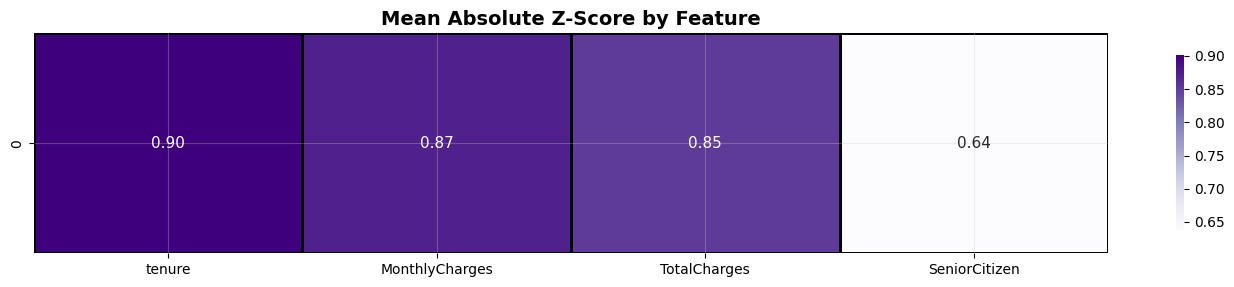

  OUTLIER ANALYSIS COMPLETED ✅


In [32]:
if len(numerical_cols) > 0:
    from scipy.stats import zscore
    
    z_scores = train[numerical_cols].apply(lambda x: np.abs(zscore(x, nan_policy='omit')))
    mean_z_scores = z_scores.mean().sort_values(ascending=False)
    
    fig, ax = plt.subplots(figsize=(14, 3))
    sns.heatmap(mean_z_scores.to_frame().T, annot=True, fmt='.2f', cmap='Purples',
                cbar_kws={"shrink": 0.8}, linewidths=1, linecolor='black', ax=ax)
    ax.set_title('Mean Absolute Z-Score by Feature', fontweight='bold')
    ax.set_ylabel('')
    
    plt.tight_layout()
    plt.show()

print("=" * 70)
print("  OUTLIER ANALYSIS COMPLETED ✅")
print("=" * 70)

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>13. BASELINE PREPROCESSING</b></div>

In [33]:
print("[1/6] Preparing original dataset for merging...")
if 'customerID' in original.columns:
    original = original.drop('customerID', axis=1)
if 'Churn' in original.columns and original['Churn'].dtype == 'object':
    original['Churn'] = original['Churn'].map({'No': 0, 'Yes': 1})

if 'TotalCharges' in original.columns and original['TotalCharges'].dtype == 'object':
    original['TotalCharges'] = pd.to_numeric(original['TotalCharges'], errors='coerce')

common_cols     = [col for col in train.columns if col in original.columns]
original_aligned = original[common_cols].copy()
print(f"      Original dataset aligned with {len(common_cols)} common columns")

print(f"\n[2/6] Combining competition train with original dataset...")
train_combined = pd.concat([train, original_aligned], ignore_index=True)

# ── FIX 1: force Churn to int after concat (prevents mixed str/int dtype) ───
train_combined[CONFIG['TARGET']] = train_combined[CONFIG['TARGET']].astype(int)

# ── FIX 2: fill TotalCharges NaN from original (whitespace rows) ─────────────
tc_median = train_combined['TotalCharges'].median()
train_combined['TotalCharges'].fillna(tc_median, inplace=True)
print(f"      TotalCharges NaN → filled with median {tc_median:.2f}")
# ─────────────────────────────────────────────────────────────────────────────

print(f"      Combined shape  : {train_combined.shape}")
print(f"      Competition     : {len(train):,} rows")
print(f"      Original        : {len(original_aligned):,} rows")
print(f"      Total           : {len(train_combined):,} rows")
print(f"      Churn rate      : {train_combined[CONFIG['TARGET']].mean()*100:.2f}%")

print(f"\n[3/6] Encoding categorical features...")
all_data = pd.concat([train_combined.drop(CONFIG['TARGET'], axis=1), test], ignore_index=True)

categorical_features = all_data.select_dtypes(include=['object']).columns.tolist()
if 'id' in categorical_features:
    categorical_features.remove('id')

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    all_data[col] = le.fit_transform(all_data[col].astype(str))
    label_encoders[col] = le

print(f"      Encoded {len(categorical_features)} categorical features: {categorical_features}")

print(f"\n[4/6] Splitting back into train and test...")
train_combined_encoded = all_data.iloc[:len(train_combined)].copy()
test_encoded           = all_data.iloc[len(train_combined):].copy()

train_combined_encoded[CONFIG['TARGET']] = train_combined[CONFIG['TARGET']].values

print(f"[5/6] Preparing final feature matrices...")
feature_cols = [col for col in train_combined_encoded.columns if col not in ['id', CONFIG['TARGET']]]

X_train = train_combined_encoded[feature_cols]

y_train = train_combined_encoded[CONFIG['TARGET']].astype(int)

X_test  = test_encoded[feature_cols]

print(f"      X_train : {X_train.shape}  |  y_train dtype: {y_train.dtype}")
print(f"      y_train : {y_train.shape}  |  classes: {sorted(y_train.unique())}")
print(f"      X_test  : {X_test.shape}")

print(f"\n[6/6] Checking for remaining object columns...")
remaining_objects = X_train.select_dtypes(include=['object']).columns.tolist()
if len(remaining_objects) > 0:
    print(f"      WARNING: Dropping {len(remaining_objects)} object columns: {remaining_objects}")
    X_train = X_train.drop(remaining_objects, axis=1)
    X_test  = X_test.drop(remaining_objects, axis=1)
else:
    print(f"      No object columns remaining ✅")

print(f"\nFinal feature count : {X_train.shape[1]}")
print(f"Feature list        : {X_train.columns.tolist()}")

print("=" * 70)
print("  BASELINE PREPROCESSING COMPLETED ✅")
print("=" * 70)

[1/6] Preparing original dataset for merging...
      Original dataset aligned with 20 common columns

[2/6] Combining competition train with original dataset...
      TotalCharges NaN → filled with median 1432.65
      Combined shape  : (601237, 21)
      Competition     : 594,194 rows
      Original        : 7,043 rows
      Total           : 601,237 rows
      Churn rate      : 22.57%

[3/6] Encoding categorical features...
      Encoded 15 categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

[4/6] Splitting back into train and test...
[5/6] Preparing final feature matrices...
      X_train : (601237, 19)  |  y_train dtype: int64
      y_train : (601237,)  |  classes: [np.int64(0), np.int64(1)]
      X_test  : (254655, 19)

[6/6] Checking for remaining object columns...
      

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>14. BASELINE MODEL — GBDT TRAINING (NO FEATURE ENGINEERING)</b></div>

In [34]:
XGB_PARAMS = {
    'n_estimators'         : 5000,
    'learning_rate'        : 0.05,
    'max_depth'            : 6,
    'subsample'            : 0.8,
    'colsample_bytree'     : 0.8,
    'tree_method'          : 'hist',
    'device'               : 'cuda',
    'eval_metric'          : 'auc',
    'early_stopping_rounds': 100,
    'random_state'         : 42,
    'verbosity'            : 0,
}

LGB_PARAMS = {
    'n_estimators'    : 5000,
    'learning_rate'   : 0.05,
    'num_leaves'      : 127,
    'subsample'       : 0.8,
    'colsample_bytree': 0.8,
    'device'          : 'gpu',
    'metric'          : 'auc',
    'random_state'    : 42,
    'verbosity'       : -1,
}

CAT_PARAMS = {
    'iterations'           : 5000,
    'learning_rate'        : 0.05,
    'depth'                : 6,
    'loss_function'        : 'Logloss',
    'eval_metric'          : 'AUC',
    'task_type'            : 'GPU',
    'early_stopping_rounds': 100,
    'random_seed'          : 42,
    'verbose'              : 0,
}

print(f"  XGB  early_stopping_rounds : {XGB_PARAMS['early_stopping_rounds']}")
print(f"  LGB  early_stopping via    : lgb.early_stopping callback in .fit()")
print(f"  CAT  early_stopping_rounds : {CAT_PARAMS['early_stopping_rounds']}")
print("Model parameters configured ✅")

  XGB  early_stopping_rounds : 100
  LGB  early_stopping via    : lgb.early_stopping callback in .fit()
  CAT  early_stopping_rounds : 100
Model parameters configured ✅


In [35]:
print("Training XGBoost with 5-Fold Stratified CV...")
print("=" * 70)

skf = StratifiedKFold(n_splits=CONFIG['N_FOLDS'], shuffle=True, random_state=CONFIG['RANDOM_SEED'])

xgb_oof_preds = np.zeros(len(X_train))
xgb_test_preds = np.zeros(len(X_test))
xgb_fold_scores = []
xgb_models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = xgb.XGBClassifier(**XGB_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    val_preds = model.predict_proba(X_val)[:, 1]
    xgb_oof_preds[val_idx] = val_preds
    
    fold_score = roc_auc_score(y_val, val_preds)
    xgb_fold_scores.append(fold_score)
    
    test_preds = model.predict_proba(X_test)[:, 1]
    xgb_test_preds += test_preds / CONFIG['N_FOLDS']
    
    xgb_models.append(model)
    
    print(f"Fold {fold} - AUC: {fold_score:.6f}")

xgb_mean_score = np.mean(xgb_fold_scores)
xgb_std_score = np.std(xgb_fold_scores)

print("=" * 70)
print(f"XGBoost OOF AUC: {xgb_mean_score:.6f} ± {xgb_std_score:.6f}")
print("=" * 70)

Training XGBoost with 5-Fold Stratified CV...
Fold 1 - AUC: 0.915917
Fold 2 - AUC: 0.916502
Fold 3 - AUC: 0.914130
Fold 4 - AUC: 0.915340
Fold 5 - AUC: 0.916389
XGBoost OOF AUC: 0.915656 ± 0.000866


In [36]:
print("Training LightGBM with 5-Fold Stratified CV...")
print("=" * 70)

lgb_oof_preds = np.zeros(len(X_train))
lgb_test_preds = np.zeros(len(X_test))
lgb_fold_scores = []
lgb_models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = lgb.LGBMClassifier(**LGB_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )
    
    val_preds = model.predict_proba(X_val)[:, 1]
    lgb_oof_preds[val_idx] = val_preds
    
    fold_score = roc_auc_score(y_val, val_preds)
    lgb_fold_scores.append(fold_score)
    
    test_preds = model.predict_proba(X_test)[:, 1]
    lgb_test_preds += test_preds / CONFIG['N_FOLDS']
    
    lgb_models.append(model)
    
    print(f"Fold {fold} - AUC: {fold_score:.6f}")

lgb_mean_score = np.mean(lgb_fold_scores)
lgb_std_score = np.std(lgb_fold_scores)

print("=" * 70)
print(f"LightGBM OOF AUC: {lgb_mean_score:.6f} ± {lgb_std_score:.6f}")
print("=" * 70)

Training LightGBM with 5-Fold Stratified CV...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Fold 1 - AUC: 0.915335
Fold 2 - AUC: 0.915746
Fold 3 - AUC: 0.913489
Fold 4 - AUC: 0.914580
Fold 5 - AUC: 0.915695
LightGBM OOF AUC: 0.914969 ± 0.000849


In [37]:
print("Training CatBoost with 5-Fold Stratified CV...")
print("=" * 70)

cat_oof_preds = np.zeros(len(X_train))
cat_test_preds = np.zeros(len(X_test))
cat_fold_scores = []
cat_models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    model = CatBoostClassifier(**CAT_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        verbose=False
    )
    
    val_preds = model.predict_proba(X_val)[:, 1]
    cat_oof_preds[val_idx] = val_preds
    
    fold_score = roc_auc_score(y_val, val_preds)
    cat_fold_scores.append(fold_score)
    
    test_preds = model.predict_proba(X_test)[:, 1]
    cat_test_preds += test_preds / CONFIG['N_FOLDS']
    
    cat_models.append(model)
    
    print(f"Fold {fold} - AUC: {fold_score:.6f}")

cat_mean_score = np.mean(cat_fold_scores)
cat_std_score = np.std(cat_fold_scores)

print("=" * 70)
print(f"CatBoost OOF AUC: {cat_mean_score:.6f} ± {cat_std_score:.6f}")
print("=" * 70)

print("=" * 70)
print("  BASELINE TRAINING COMPLETED ✅")
print("=" * 70)

Training CatBoost with 5-Fold Stratified CV...


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 1 - AUC: 0.915561


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 2 - AUC: 0.915871


...

Fold 3 - AUC: 0.913761


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 4 - AUC: 0.914982


Default metric period is 5 because AUC is/are not implemented for GPU


Fold 5 - AUC: 0.915944
CatBoost OOF AUC: 0.915224 ± 0.000806
  BASELINE TRAINING COMPLETED ✅


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>15. BASELINE EVALUATION</b></div>

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
OOF SCORES SUMMARY<br>
</div>

In [38]:
results_df = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'CatBoost'],
    'Mean CV Score': [xgb_mean_score, lgb_mean_score, cat_mean_score],
    'Std': [xgb_std_score, lgb_std_score, cat_std_score]
})

results_df = results_df.sort_values('Mean CV Score', ascending=False)
display(results_df.style.background_gradient(subset=['Mean CV Score'], cmap='RdPu'))

,Model,Mean CV Score,Std
0,XGBoost,0.915656,0.000866
2,CatBoost,0.915224,0.000806
1,LightGBM,0.914969,0.000849


<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
FEATURE IMPORTANCE<br>
</div>

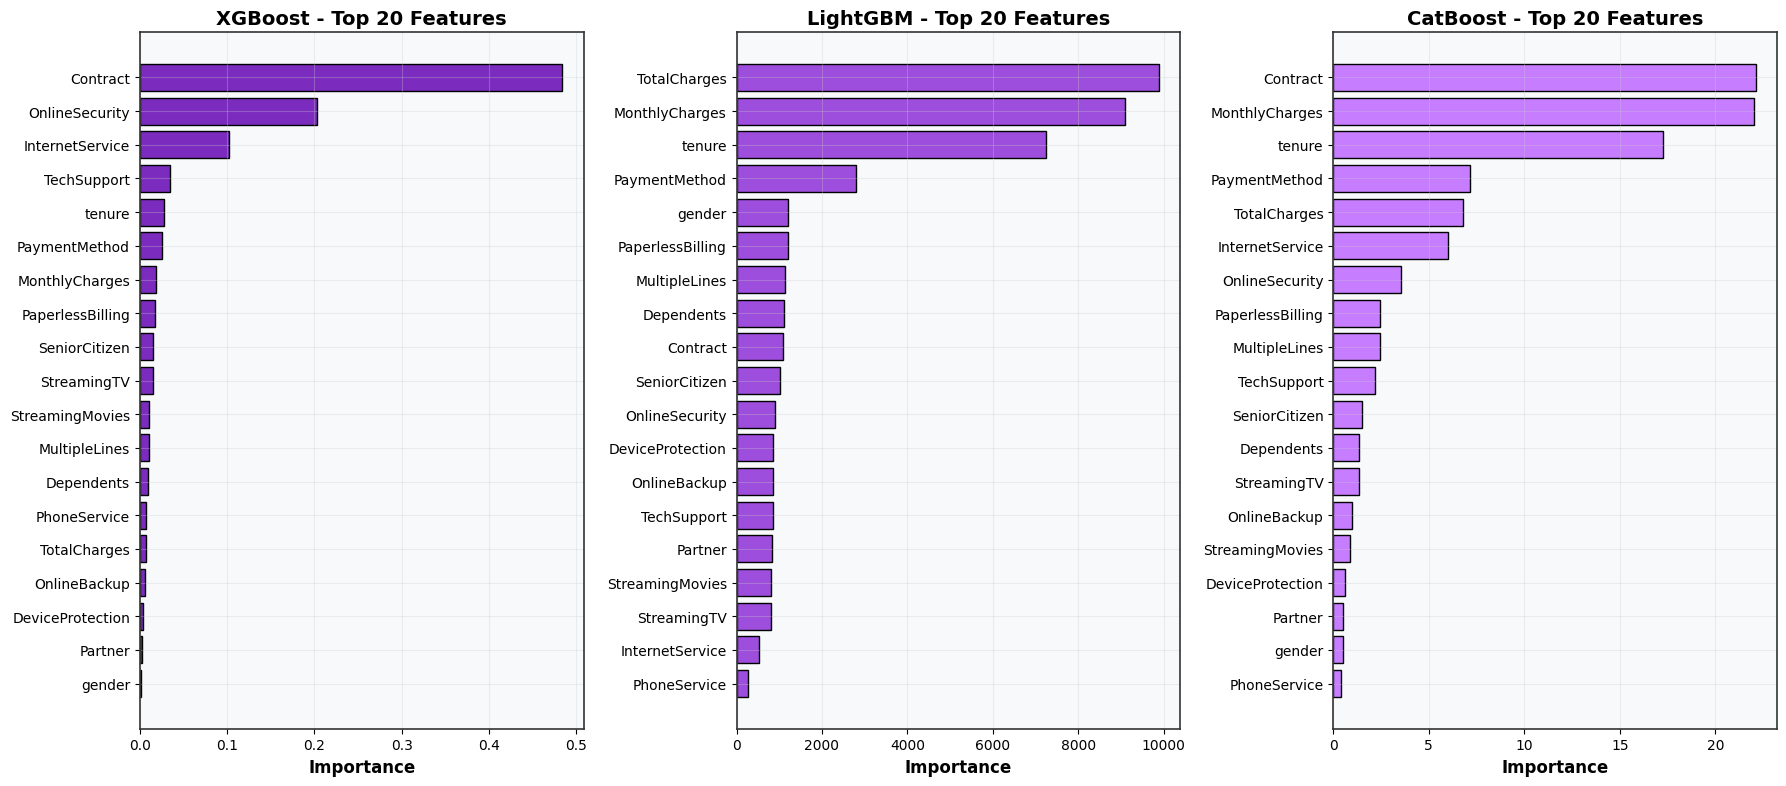

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_models[0].feature_importances_
}).sort_values('importance', ascending=False).head(20)

ax = axes[0]
ax.barh(range(len(xgb_importance)), xgb_importance['importance'].values,
        color=COLORS[0], edgecolor='black', linewidth=1)
ax.set_yticks(range(len(xgb_importance)))
ax.set_yticklabels(xgb_importance['feature'])
ax.set_xlabel('Importance', fontweight='bold')
ax.set_title('XGBoost - Top 20 Features', fontweight='bold')
ax.invert_yaxis()

lgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lgb_models[0].feature_importances_
}).sort_values('importance', ascending=False).head(20)

ax = axes[1]
ax.barh(range(len(lgb_importance)), lgb_importance['importance'].values,
        color=COLORS[1], edgecolor='black', linewidth=1)
ax.set_yticks(range(len(lgb_importance)))
ax.set_yticklabels(lgb_importance['feature'])
ax.set_xlabel('Importance', fontweight='bold')
ax.set_title('LightGBM - Top 20 Features', fontweight='bold')
ax.invert_yaxis()

cat_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': cat_models[0].feature_importances_
}).sort_values('importance', ascending=False).head(20)

ax = axes[2]
ax.barh(range(len(cat_importance)), cat_importance['importance'].values,
        color=COLORS[2], edgecolor='black', linewidth=1)
ax.set_yticks(range(len(cat_importance)))
ax.set_yticklabels(cat_importance['feature'])
ax.set_xlabel('Importance', fontweight='bold')
ax.set_title('CatBoost - Top 20 Features', fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
ROC CURVES<br>
</div>

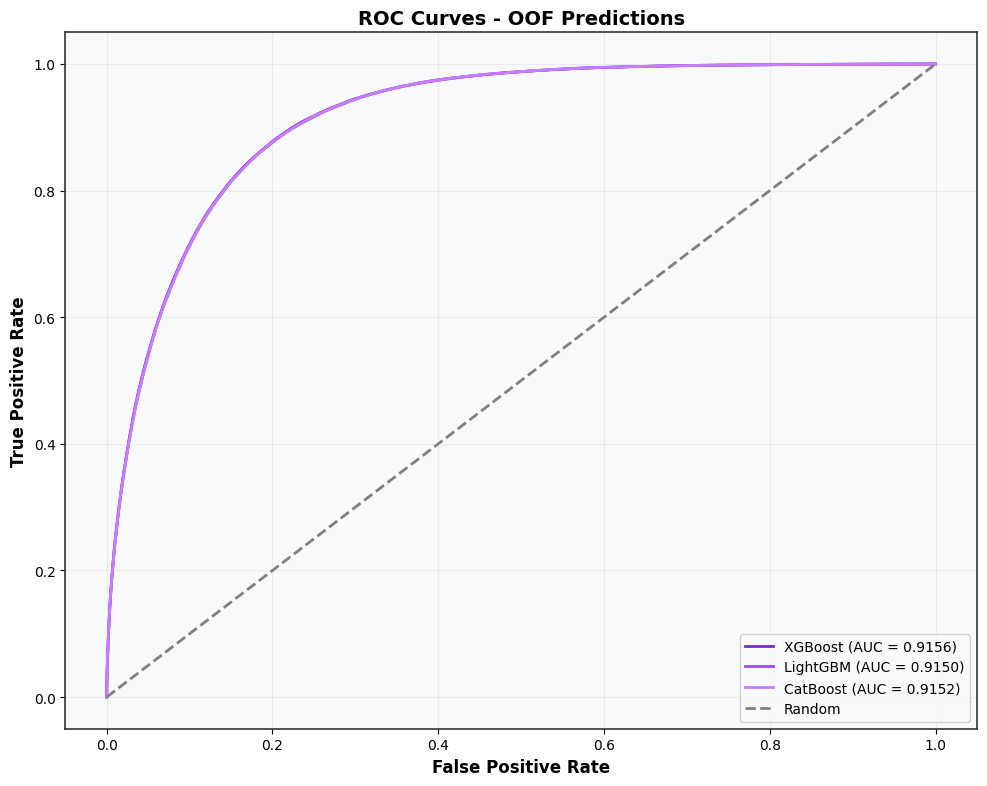

In [40]:
fig, ax = plt.subplots(figsize=(10, 8))

fpr_xgb, tpr_xgb, _ = roc_curve(y_train, xgb_oof_preds)
auc_xgb = roc_auc_score(y_train, xgb_oof_preds)
ax.plot(fpr_xgb, tpr_xgb, color=COLORS[0], linewidth=2, label=f'XGBoost (AUC = {auc_xgb:.4f})')

fpr_lgb, tpr_lgb, _ = roc_curve(y_train, lgb_oof_preds)
auc_lgb = roc_auc_score(y_train, lgb_oof_preds)
ax.plot(fpr_lgb, tpr_lgb, color=COLORS[1], linewidth=2, label=f'LightGBM (AUC = {auc_lgb:.4f})')

fpr_cat, tpr_cat, _ = roc_curve(y_train, cat_oof_preds)
auc_cat = roc_auc_score(y_train, cat_oof_preds)
ax.plot(fpr_cat, tpr_cat, color=COLORS[2], linewidth=2, label=f'CatBoost (AUC = {auc_cat:.4f})')

ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2, label='Random')

ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('ROC Curves - OOF Predictions', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
PRECISION-RECALL CURVES<br>
</div>

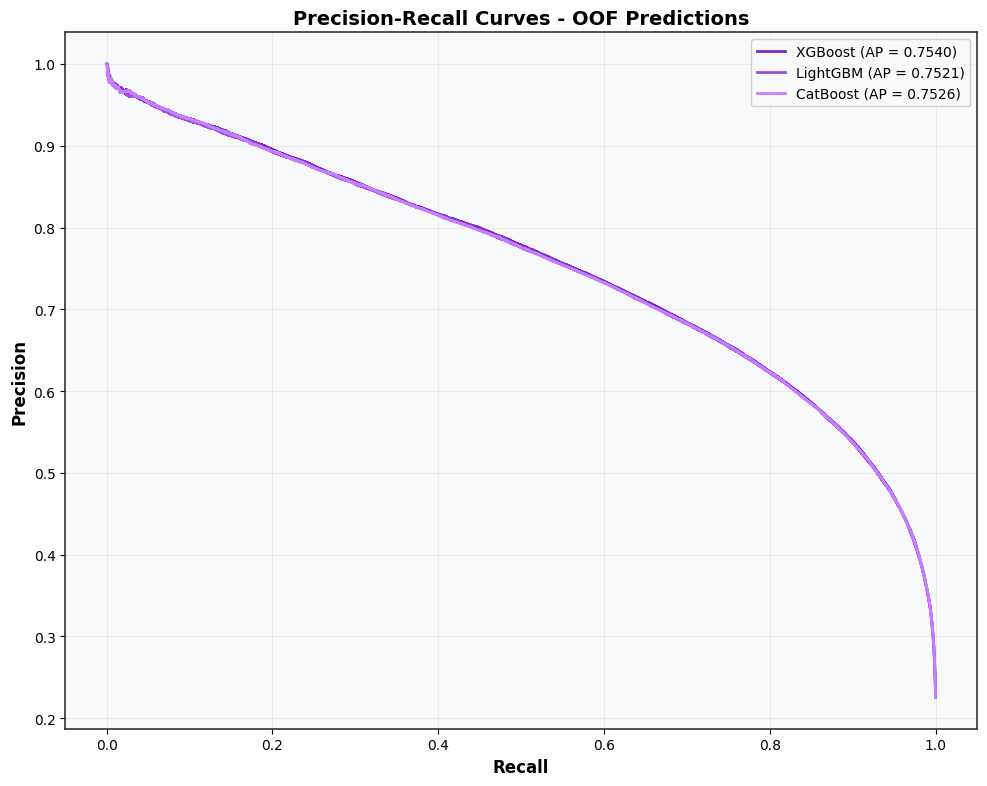

In [41]:
fig, ax = plt.subplots(figsize=(10, 8))

precision_xgb, recall_xgb, _ = precision_recall_curve(y_train, xgb_oof_preds)
ap_xgb = average_precision_score(y_train, xgb_oof_preds)
ax.plot(recall_xgb, precision_xgb, color=COLORS[0], linewidth=2, label=f'XGBoost (AP = {ap_xgb:.4f})')

precision_lgb, recall_lgb, _ = precision_recall_curve(y_train, lgb_oof_preds)
ap_lgb = average_precision_score(y_train, lgb_oof_preds)
ax.plot(recall_lgb, precision_lgb, color=COLORS[1], linewidth=2, label=f'LightGBM (AP = {ap_lgb:.4f})')

precision_cat, recall_cat, _ = precision_recall_curve(y_train, cat_oof_preds)
ap_cat = average_precision_score(y_train, cat_oof_preds)
ax.plot(recall_cat, precision_cat, color=COLORS[2], linewidth=2, label=f'CatBoost (AP = {ap_cat:.4f})')

ax.set_xlabel('Recall', fontweight='bold')
ax.set_ylabel('Precision', fontweight='bold')
ax.set_title('Precision-Recall Curves - OOF Predictions', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
CONFUSION MATRICES<br>
</div>

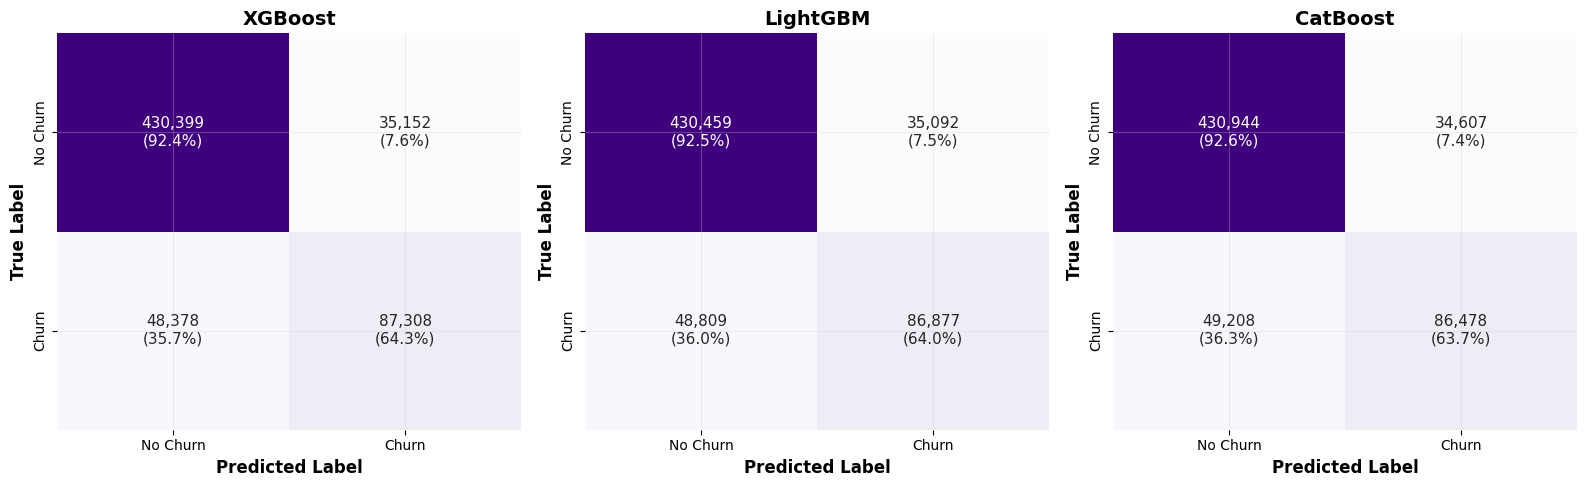

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

threshold = 0.5

xgb_binary = (xgb_oof_preds >= threshold).astype(int)
cm_xgb = confusion_matrix(y_train, xgb_binary)
cm_xgb_pct = cm_xgb.astype('float') / cm_xgb.sum(axis=1)[:, np.newaxis] * 100

ax = axes[0]
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples', cbar=False, ax=ax,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
ax.set_title('XGBoost', fontweight='bold')
ax.set_ylabel('True Label', fontweight='bold')
ax.set_xlabel('Predicted Label', fontweight='bold')

for i in range(2):
    for j in range(2):
        text = ax.texts[i*2 + j]
        text.set_text(f"{cm_xgb[i,j]:,}\n({cm_xgb_pct[i,j]:.1f}%)")

lgb_binary = (lgb_oof_preds >= threshold).astype(int)
cm_lgb = confusion_matrix(y_train, lgb_binary)
cm_lgb_pct = cm_lgb.astype('float') / cm_lgb.sum(axis=1)[:, np.newaxis] * 100

ax = axes[1]
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Purples', cbar=False, ax=ax,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
ax.set_title('LightGBM', fontweight='bold')
ax.set_ylabel('True Label', fontweight='bold')
ax.set_xlabel('Predicted Label', fontweight='bold')

for i in range(2):
    for j in range(2):
        text = ax.texts[i*2 + j]
        text.set_text(f"{cm_lgb[i,j]:,}\n({cm_lgb_pct[i,j]:.1f}%)")

cat_binary = (cat_oof_preds >= threshold).astype(int)
cm_cat = confusion_matrix(y_train, cat_binary)
cm_cat_pct = cm_cat.astype('float') / cm_cat.sum(axis=1)[:, np.newaxis] * 100

ax = axes[2]
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Purples', cbar=False, ax=ax,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
ax.set_title('CatBoost', fontweight='bold')
ax.set_ylabel('True Label', fontweight='bold')
ax.set_xlabel('Predicted Label', fontweight='bold')

for i in range(2):
    for j in range(2):
        text = ax.texts[i*2 + j]
        text.set_text(f"{cm_cat[i,j]:,}\n({cm_cat_pct[i,j]:.1f}%)")

plt.tight_layout()
plt.show()

<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
CLASSIFICATION REPORT<br>
</div>

In [43]:
print("XGBoost Classification Report:")
print("=" * 70)
print(classification_report(y_train, xgb_binary, target_names=['No Churn', 'Churn']))

print("\nLightGBM Classification Report:")
print("=" * 70)
print(classification_report(y_train, lgb_binary, target_names=['No Churn', 'Churn']))

print("\nCatBoost Classification Report:")
print("=" * 70)
print(classification_report(y_train, cat_binary, target_names=['No Churn', 'Churn']))

print("=" * 70)
print("  BASELINE EVALUATION COMPLETED ✅")
print("=" * 70)

XGBoost Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.92      0.91    465551
       Churn       0.71      0.64      0.68    135686

    accuracy                           0.86    601237
   macro avg       0.81      0.78      0.79    601237
weighted avg       0.86      0.86      0.86    601237


LightGBM Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.92      0.91    465551
       Churn       0.71      0.64      0.67    135686

    accuracy                           0.86    601237
   macro avg       0.81      0.78      0.79    601237
weighted avg       0.86      0.86      0.86    601237


CatBoost Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.93      0.91    465551
       Churn       0.71      0.64      0.67    135686

    accuracy                           0.86    601237
   macro avg       0.81      0.

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>16. SUBMISSION</b></div>

In [44]:
print("Creating ensemble submission (equal weight average)...")

ensemble_preds = (xgb_test_preds + lgb_test_preds + cat_test_preds) / 3

submission = pd.DataFrame({
    'id': test['id'],
    CONFIG['TARGET']: ensemble_preds
})

display(submission.head(10))

submission.to_csv('submission.csv', index=False)

print("\nSubmission Statistics:")
print(f"  Shape               : {submission.shape}")
print(f"  Mean Prediction     : {submission[CONFIG['TARGET']].mean():.6f}")
print(f"  Std Prediction      : {submission[CONFIG['TARGET']].std():.6f}")
print(f"  Min Prediction      : {submission[CONFIG['TARGET']].min():.6f}")
print(f"  Max Prediction      : {submission[CONFIG['TARGET']].max():.6f}")
print(f"  File saved          : submission.csv")

print("=" * 70)
print("  SUBMISSION SAVED ✅")
print("=" * 70)

Creating ensemble submission (equal weight average)...


,id,Churn
0,594194,0.065929
1,594195,0.000835
2,594196,0.108253
3,594197,0.004063
4,594198,0.493986
5,594199,0.164109
6,594200,0.897210
7,594201,0.002843
8,594202,0.036857
9,594203,0.324075



Submission Statistics:
  Shape               : (254655, 2)
  Mean Prediction     : 0.218663
  Std Prediction      : 0.275125
  Min Prediction      : 0.000244
  Max Prediction      : 0.990248
  File saved          : submission.csv
  SUBMISSION SAVED ✅


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #1e3c72, #c31432); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>✅ FINAL SUMMARY</b></div>

In [45]:
print("=" * 70)
print("                      FINAL MODEL SUMMARY")
print("=" * 70)
print(f"{'Model':<15} | {'OOF CV Score':>15} | {'Notes':<30}")
print("-" * 70)
print(f"{'XGBoost':<15} | {xgb_mean_score:>15.6f} | {'GPU-accelerated GBDT'}")
print(f"{'LightGBM':<15} | {lgb_mean_score:>15.6f} | {'Leaf-wise tree growth'}")
print(f"{'CatBoost':<15} | {cat_mean_score:>15.6f} | {'Ordered boosting'}")
print("-" * 70)
best_model = results_df.iloc[0]['Model']
best_score = results_df.iloc[0]['Mean CV Score']
print(f"Best Model: {best_model} with CV Score: {best_score:.6f}")
print("=" * 70)
print(f"\nEnsemble Strategy: Equal weight average (1/3 each)")
print(f"Training Size    : {len(X_train):,} rows (Competition + Original)")
print(f"Feature Count    : {X_train.shape[1]}")
print(f"Cross-Validation : {CONFIG['N_FOLDS']}-Fold Stratified")
print(f"Submission File  : submission.csv")
print("=" * 70)

                      FINAL MODEL SUMMARY
Model           |    OOF CV Score | Notes                         
----------------------------------------------------------------------
XGBoost         |        0.915656 | GPU-accelerated GBDT
LightGBM        |        0.914969 | Leaf-wise tree growth
CatBoost        |        0.915224 | Ordered boosting
----------------------------------------------------------------------
Best Model: XGBoost with CV Score: 0.915656

Ensemble Strategy: Equal weight average (1/3 each)
Training Size    : 601,237 rows (Competition + Original)
Feature Count    : 19
Cross-Validation : 5-Fold Stratified
Submission File  : submission.csv


<div style="
    background-color:gray;
    padding:16px;
    border-radius:8px;
    text-align:center;
    font-size:17px;
    font-weight:bold;
    color:white;
">
Thank you for reviewing this notebook. If it added value, please consider giving it an upvote.<br>
</div>